# DIMER Workshop: Comparing Tabular Foundation Models for Seven-Day Retail Demand Regression

**Profile:** `E2E`  
**Mode:** `WORKSHOP`  
**Notebook specification:** DIMER Notebook Specification 2.1 — **standalone**  
**Run all:** the default path acquires the pinned sample, validates it, fits classical baselines and four foundation-model in-context conditions, freezes successful full-feature runs, reloads saved artifacts for independent test evaluation, and exports a reproducibility bundle. No DIMER service, repository clone, repository install, credential, or upload dialog is required.  
**Bring Your Own Data:** set `USE_BYOD = True` and provide `BYOD_ZIP_PATH` (or use the optional Colab upload fallback) for a ZIP containing `train.csv`, `val.csv`, and `test.csv` with the same feature/target contract. A non-empty path always bypasses the upload dialog.

**Dataset:** `freshretailnet-h7` sample dataset derived from FreshRetailNet-50K  
**Dataset source:** `examples/sample-data/freshretailnet-h7.zip` in `kurtvalcorza/mitra-regressor-pipeline`  
**Pinned dataset revision:** `78e12407044bbca6ed8edbb9754bb33bf09117ac`  
**Dataset acquisition:** Download the pinned repository artifact automatically and verify its SHA-256 before use  
**Model execution:** Run the regressors locally inside this notebook—no DIMER model job is required  
**Task:** Predict continuous `sale_amount` seven days ahead  
**Recommended audience:** College students with introductory Python and machine-learning experience  
**Estimated time:** Workshop duration must be measured in the intended runtime; allow extra time for first-time environment installation, depending on the number of foundation models selected and whether their environments are already cached

---

## What you will do

In this notebook, you will:

1. acquire and verify the fixed FreshRetailNet-derived sample artifact from the repository;
2. inspect and validate the data;
3. perform exploratory data analysis (EDA);
4. train several classical regression baselines;
5. install and run multiple tabular foundation-model regressors directly in Colab;
6. compare all models with the same evaluation protocol;
7. investigate whether stockout information affects prediction error; and
8. write an evidence-based conclusion that states what the experiment does—and does not—show.

> **Important:** This is a training and demonstration exercise. The sample is not an authoritative benchmark, and its target is **observed future sales**, not necessarily uncensored customer demand.


This workshop is a standalone DIMER Notebook Specification 2.1 carrier. The reviewed public model adapters and checkpoint manifests are embedded in the notebook at authoring time; runtime execution installs only exact upstream dependency pins and retrieves immutable, digest-verified checkpoint files from their declared public hosts. The notebook does not clone or execute remote DIMER source code.


## Research-design context

The activity uses a comparative experimental pattern:

- define one prediction task;
- hold the dataset and evaluation protocol constant;
- compare multiple model families;
- evaluate them with common metrics; and
- interpret whether additional model complexity provides meaningful value.

### Main research question

> How do tabular foundation models compare with conventional machine-learning baselines when predicting observed retail sales seven days ahead?

### Secondary questions

1. Does in-context use of an open-weight tabular foundation model outperform simple and classical baselines?
2. Does task-specific fine-tuning improve performance relative to an in-context condition?
3. Does prediction error change when stockout exposure is high?

## Learning objectives

By the end of this activity, you should be able to:

- distinguish training, validation, and test data;
- explain why chronological splitting matters for time-dependent data;
- identify target leakage and avoid it;
- interpret MAE, RMSE, median absolute error, and \(R^2\);
- compare models under a controlled protocol;
- distinguish **in-context learning** from **fine-tuning**;
- identify why a complex model must be compared with meaningful baselines;
- interpret model errors in relation to stockout conditions; and
- state conclusions with appropriate limitations.

## Short glossary

| Term | Meaning in this notebook |
|---|---|
| **Regression** | Predicting a continuous numerical value. |
| **Baseline** | A simple reference method used to determine whether a more complex model adds value. |
| **Tabular foundation model** | A pretrained model designed to learn patterns across tabular datasets and adapt to a new table through context, fine-tuning, or both. |
| **In-context learning (ICL)** | The model uses labelled examples as context without updating its pretrained weights. |
| **Fine-tuning** | The model updates some or all pretrained weights using the activity dataset. |
| **Temporal leakage** | Future information accidentally influences model training or model selection. |
| **Validation set** | Data used to compare candidate settings and make model-selection decisions. |
| **Test set** | Data reserved for one final evaluation after choices are fixed. |
| **Stockout** | A period when a product is unavailable; observed sales may then be lower than latent customer demand. |

## Dataset and experiment summary

The published archive contains three files:

| Partition | Rows | Purpose |
|---|---:|---|
| `train.csv` | 4,180 | Fit classical models or provide support/fine-tuning data to foundation models |
| `val.csv` | 1,600 | Compare candidate models and settings |
| `test.csv` | 1,600 | Perform one final evaluation after the configuration is fixed |

Each row contains 17 input features and one continuous target:

\[
\text{features at day } t \longrightarrow \text{observed sale\_amount at } t+7
\]

The source construction uses a purged chronological split with seven-row embargoes between partitions. The embargo prevents a feature row near a boundary from referring to a target date inside the following partition.

### Feature groups

- **Historical sales:** `lag_1`, `lag_7`, `lag_14`, rolling means, and rolling standard deviation
- **Stockout:** current and recent stockout hours
- **Context:** discount, holiday/activity flags, weather, day of week, and month

### Regressors executed in this notebook

| Model | Default notebook mode | Optional notebook mode | Weight licence note |
|---|---|---|---|
| Mitra Regressor | In-context learning | GPU fine-tuning | Apache-2.0 |
| TabDPT v1.2 Regressor | In-context learning | — | Apache-2.0 |
| TabPFN-3 Regressor | In-context learning | Public notebook does not carry its private fine-tuner | Non-commercial v3 weights |
| TabICLv2 Regressor | In-context learning | GPU fine-tuning | BSD-3-Clause |

The notebook creates a separate Python environment for each foundation-model repository. This avoids dependency conflicts while still running every selected regressor from this notebook.

> **Licence reminder:** A model's weight licence and the dataset licence both matter. FreshRetailNet-50K is CC BY 4.0. TabPFN-3 v3 has non-commercial weight terms and should be clearly labelled in reports and downstream artifacts.

## Before you begin

### Requirements

- A current Google Colab runtime
- Internet access from Colab to download the pinned sample dataset, install `uv` when needed, and retrieve immutable model checkpoints from their declared public upstream hosts
- Several gigabytes of free runtime storage if you run all four foundation models
- A GPU runtime for optional Mitra or TabICLv2 fine-tuning; the default in-context conditions can run without a DIMER model job

### Dataset acquisition

Section 1 automatically downloads this fixed repository artifact:

`kurtvalcorza/mitra-regressor-pipeline/examples/sample-data/freshretailnet-h7.zip`

The notebook pins the repository revision and expected SHA-256. If the download fails, the archive is not a valid ZIP, or the checksum differs, execution stops rather than substituting another dataset.

The sample is derived from FreshRetailNet-50K and is intended for smoke-testing, learning, and workshop demonstrations. It is not benchmark evidence.

### Model installation and runtime

Each model repository pins a different dependency stack. The notebook therefore creates isolated virtual environments under `/content/dimer_tabular_workshop_v2/environments/`.

Current Colab runtimes may use Python 3.13. The selected pipeline set is not uniformly compatible with Python 3.13, so Section 5.2 uses `uv` to create isolated **Python 3.12** environments for the foundation models. This keeps the notebook kernel unchanged while providing a compatible interpreter for all four pinned model stacks.

The first installation can take several minutes per selected model. Later runs in the same Colab session reuse the environments and downloaded weights. You can select only two or three models for a shorter workshop.

### Test-set rule

During EDA and model selection, this notebook hides test-target summaries by default. Keep them hidden until:

1. the feature set is fixed;
2. the model conditions are fixed;
3. the primary metric is fixed; and
4. no more tuning decisions will be made.

This rule protects the independence of the final evaluation.

### Optional user data

Set `USE_BYOD = True` in Section 1 to use your own pre-split ZIP. The archive must contain `train.csv`, `val.csv`, and `test.csv`, with a numeric `target` and the expected retail feature columns. Use `BYOD_ZIP_PATH` for non-interactive execution; when it is non-empty the notebook never opens an upload dialog. User-supplied files stay in this runtime. Do not upload confidential, restricted, or personally identifiable data unless you are authorised to process it in the selected runtime.


# 0. Set up the Colab environment

In [1]:
# @title 0.1 Install the optional LightGBM dependency

INSTALL_LIGHTGBM = True # @param {type:"boolean"}
LIGHTGBM_VERSION = "4.6.0" # @param {type:"string"}

import importlib.util
import subprocess
import sys

if INSTALL_LIGHTGBM and importlib.util.find_spec("lightgbm") is None:
    print(f"Installing lightgbm=={LIGHTGBM_VERSION} ...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", f"lightgbm=={LIGHTGBM_VERSION}"]
    )

print("Environment preparation complete.")

Environment preparation complete.


In [2]:
# @title 0.2 Import libraries and set experiment controls

from __future__ import annotations

import copy
import pickle
import uuid
import importlib
import hashlib
import json
import os
import platform
import shlex
import shutil
import subprocess
import sys
import time
import urllib.request
import zipfile
from importlib import metadata
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except Exception as exc:
    LIGHTGBM_AVAILABLE = False
    LIGHTGBM_IMPORT_ERROR = repr(exc)

RANDOM_SEED = 0 # @param {type:"integer"}
PRIMARY_METRIC = "mae" # @param ["mae", "rmse", "r2"]
INCLUDE_TEST_TARGETS_IN_EDA = False # @param {type:"boolean"}
TEST_EVALUATION_COMPLETED = False  # Updated only by the frozen-test cell.

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

def package_version(name: str) -> str:
    try:
        return metadata.version(name)
    except metadata.PackageNotFoundError:
        return "not installed"

SOFTWARE_VERSIONS = {
    "python": platform.python_version(),
    "numpy": package_version("numpy"),
    "pandas": package_version("pandas"),
    "matplotlib": package_version("matplotlib"),
    "scikit-learn": package_version("scikit-learn"),
    "lightgbm": package_version("lightgbm"),
}

print("Experiment controls")
print(f"  Random seed: {RANDOM_SEED}")
print(f"  Primary metric: {PRIMARY_METRIC}")
print("  Test results are scored only after an explicit experiment freeze.")
print("\nSoftware versions")
display(pd.Series(SOFTWARE_VERSIONS, name="version").to_frame())

Experiment controls
  Random seed: 0
  Primary metric: mae
  Test results are scored only after an explicit experiment freeze.

Software versions


,version
python,3.13.15
numpy,2.1.3
pandas,2.2.3
matplotlib,3.10.0
scikit-learn,1.6.1
lightgbm,4.6.0


### One workspace per experiment
The notebook writes only to its own child directories. It never deletes the downloaded source archive or a participant-selected directory. Starting a new experiment creates a new folder and leaves the previous one intact.

The code below handles file safety and experiment records. Run it once; you do not need to edit the helper functions. Model files are retained locally so final testing can use the same fitted models. Serialized model files must come from this notebook in your own runtime—not from an untrusted upload.

In [3]:
# @title 0.3 Create a protected experiment workspace
# @markdown Leave Start new experiment off during an exercise. Turn it on only to begin a new experiment;
# @markdown previous files are preserved. Turn it off again before continuing.
START_NEW_EXPERIMENT = False # @param {type:"boolean"}

CORE_SOURCE = '"""Notebook-owned experiment bookkeeping. No network or model imports.\n\nLocal artifact hashes protect against accidental substitution, not malicious code\nwith access to the same runtime. Never load someone else\'s serialized model.\n"""\nfrom __future__ import annotations\nimport csv\nimport hashlib\nimport io\nimport json\nimport math\nimport pickle\nimport re\nimport shutil\nimport stat\nimport uuid\nimport zipfile\nfrom pathlib import Path, PurePosixPath\nfrom typing import Any\nimport numpy as np\nimport pandas as pd\n\nCORE_VERSION = "2.1.0"\nOWNER = "dimer-freshretailnet-workshop-v2"\nRESULT_COLUMNS = ["model_key", "model", "family", "condition", "partition", "mae", "rmse",\n                  "median_absolute_error", "r2", "runtime_seconds", "fit_runtime_seconds",\n                  "prediction_runtime_seconds", "effective_mode", "device", "licence", "notes", "run_id"]\n\n\ndef canonical_json(value: Any) -> str:\n    return json.dumps(value, sort_keys=True, separators=(",", ":"), ensure_ascii=False, allow_nan=False)\n\n\ndef fingerprint(value: Any) -> str:\n    return hashlib.sha256(canonical_json(value).encode()).hexdigest()\n\n\ndef sha256_file(path: str | Path) -> str:\n    h = hashlib.sha256()\n    with Path(path).open("rb") as handle:\n        for block in iter(lambda: handle.read(1024 * 1024), b""):\n            h.update(block)\n    return h.hexdigest()\n\n\ndef write_json(path: str | Path, value: Any) -> None:\n    path = Path(path)\n    tmp = path.with_name(path.name + "." + uuid.uuid4().hex + ".tmp")\n    tmp.write_text(json.dumps(value, indent=2, sort_keys=True, allow_nan=False) + "\\n", encoding="utf-8")\n    tmp.replace(path)\n\n\ndef checked_name(value: str) -> str:\n    if not re.fullmatch(r"[A-Za-z0-9][A-Za-z0-9_.-]{0,100}", value) or value in {".", ".."}:\n        raise ValueError("Use a simple name (letters, numbers, dash, underscore); not a path.")\n    return value\n\n\ndef owned_root(path: str | Path) -> Path:\n    """Claim only an empty directory; never delete or take ownership of user data."""\n    path = Path(path).absolute()\n    if any(p.is_symlink() for p in (path, *path.parents)):\n        raise ValueError("The workshop workspace must not traverse symbolic links.")\n    if path == Path(path.anchor) or path == Path.home():\n        raise ValueError("Choose a dedicated workshop directory, not a root or home directory.")\n    marker = path / ".workshop-owner.json"\n    if path.exists():\n        if not path.is_dir():\n            raise ValueError("Workspace is not a directory.")\n        if marker.exists():\n            if json.loads(marker.read_text()).get("owner") != OWNER:\n                raise ValueError("This workspace belongs to another application.")\n        elif any(path.iterdir()):\n            raise ValueError("Refusing to claim a non-empty, unowned directory. No files were deleted.")\n    path.mkdir(parents=True, exist_ok=True)\n    if not marker.exists():\n        write_json(marker, {"owner": OWNER})\n    return path.resolve()\n\n\ndef new_owned_directory(parent: Path, label: str) -> Path:\n    """Create a fresh child. No operation in this module recursively deletes files."""\n    parent = Path(parent).resolve()\n    parent.mkdir(parents=True, exist_ok=True)\n    name = checked_name(label) + "-" + uuid.uuid4().hex[:12]\n    path = parent / name\n    path.mkdir(exist_ok=False)\n    write_json(path / ".workshop-owner.json", {"owner": OWNER})\n    return path\n\n\ndef stage_dataset_zip(archive_path: Path, parent: Path, *, max_bytes: int = 512 * 1024**2) -> dict[str, Path]:\n    """Accept flat or nested splits; stage exactly three CSVs under a fresh owned child."""\n    archive_path = Path(archive_path).resolve(strict=True)\n    if not zipfile.is_zipfile(archive_path):\n        raise ValueError("Upload the unchanged dataset ZIP, not an extracted CSV.")\n    required = {"train.csv", "val.csv", "test.csv"}\n    with zipfile.ZipFile(archive_path) as zf:\n        chosen = {}\n        expanded = 0\n        seen = set()\n        for info in zf.infolist():\n            name = info.filename\n            p = PurePosixPath(name)\n            if "\\\\" in name or p.is_absolute() or ".." in p.parts or name in seen:\n                raise ValueError(f"Unsafe or duplicate ZIP path: {name}")\n            if stat.S_ISLNK((info.external_attr >> 16) & 0xFFFF):\n                raise ValueError(f"ZIP symbolic links are not accepted: {name}")\n            if info.flag_bits & 1:\n                raise ValueError("Encrypted ZIP members are not accepted.")\n            seen.add(name)\n            expanded += info.file_size\n            if expanded > max_bytes:\n                raise ValueError("Archive exceeds the workshop\'s expanded-size limit.")\n            if not info.is_dir() and p.name in required:\n                if p.name in chosen:\n                    raise ValueError(f"Multiple copies of {p.name}; upload one unambiguous dataset.")\n                chosen[p.name] = info\n        if set(chosen) != required:\n            raise ValueError(f"Required ZIP members missing: {sorted(required - set(chosen))}")\n        # All paths and size checks complete before writing; CRC checked as each member is read.\n        destination = new_owned_directory(parent, "dataset")\n        paths = {}\n        for name, info in chosen.items():\n            payload = zf.read(info)\n            header = next(csv.reader(io.StringIO(payload.decode("utf-8-sig"))), [])\n            if not header or len(set(header)) != len(header):\n                raise ValueError(f"Empty/duplicate CSV headers in {name}.")\n            target = destination / name\n            target.write_bytes(payload)\n            paths[name[:-4]] = target.resolve()\n    return paths\n\n\ndef split_identity(paths: dict[str, Path], features: list[str], archive_sha: str) -> dict[str, Any]:\n    return {"archive_sha256": archive_sha, "features": list(features),\n            "split_sha256": {k: sha256_file(paths[k]) for k in ("train", "val", "test")}}\n\n\ndef regression_metrics(y_true: Any, y_pred: Any) -> dict[str, float | None]:\n    y = np.asarray(y_true, dtype=float).reshape(-1)\n    pred = np.asarray(y_pred, dtype=float).reshape(-1)\n    if y.shape != pred.shape or not y.size or not np.isfinite(y).all() or not np.isfinite(pred).all():\n        raise ValueError("Metrics require nonempty, equally sized, finite targets and predictions.")\n    error = y - pred\n    total = float(np.sum((y - y.mean())**2))\n    return {"mae": float(np.abs(error).mean()), "rmse": float(np.sqrt((error**2).mean())),\n            "median_absolute_error": float(np.median(np.abs(error))),\n            "r2": float(1 - (error**2).sum()/total) if total > 0 else None}\n\n\ndef prediction_frame(frame: pd.DataFrame, predictions: Any) -> pd.DataFrame:\n    values = np.asarray(predictions, dtype=float).reshape(-1)\n    if len(values) != len(frame) or not np.isfinite(values).all():\n        raise ValueError("Predictions must contain one finite number per input row.")\n    out = pd.DataFrame({"row_id": np.arange(len(frame)), "target": frame.target.to_numpy(float),\n                        "prediction": values})\n    for col in ("stockout_hours", "roll_7_stockout"):\n        if col in frame:\n            out[col] = frame[col].to_numpy()\n    return out\n\n\ndef canonical_predictions(frame: pd.DataFrame, reference: pd.DataFrame) -> pd.DataFrame:\n    """One public prediction schema; align by local split row_id, never by guessed order."""\n    out = frame.copy()\n    for old, new in (("observed", "target"), ("predicted", "prediction")):\n        if old in out and new not in out:\n            out = out.rename(columns={old: new})\n    if not {"row_id", "target", "prediction"}.issubset(out):\n        raise ValueError("Prediction CSV requires row_id, target, prediction.")\n    if len(out) != len(reference):\n        raise ValueError("Prediction row count differs from the reference split.")\n    ids = pd.to_numeric(out.row_id, errors="raise").to_numpy(float)\n    if not np.isfinite(ids).all() or not np.equal(ids, np.floor(ids)).all():\n        raise ValueError("row_id must contain finite integers.")\n    if sorted(ids.astype(int).tolist()) != list(range(len(reference))):\n        raise ValueError("Missing, duplicate, or out-of-range prediction row_id.")\n    out = out.sort_values("row_id").reset_index(drop=True)\n    for col in ("target", "prediction"):\n        out[col] = pd.to_numeric(out[col], errors="raise")\n        if not np.isfinite(out[col].to_numpy(float)).all():\n            raise ValueError(f"Non-finite {col} in prediction CSV.")\n    if not np.allclose(out.target, reference.target.to_numpy(float), rtol=1e-12, atol=1e-12):\n        raise ValueError("Prediction targets do not match the declared split rows.")\n    # Always use reference features for stratified diagnostics.\n    for col in ("stockout_hours", "roll_7_stockout"):\n        if col in reference:\n            out[col] = reference[col].to_numpy()\n    return out\n\n\ndef normalize_results(records: list[dict] | pd.DataFrame) -> pd.DataFrame:\n    result = pd.DataFrame(records).copy()\n    for col in RESULT_COLUMNS:\n        if col not in result:\n            result[col] = "cpu" if col == "device" else (None if col != "notes" else "")\n    for col in ("mae", "rmse", "median_absolute_error", "r2", "runtime_seconds"):\n        result[col] = pd.to_numeric(result[col], errors="coerce")\n    return result\n\n\ndef choose_diagnostic_model(registry: dict, requested: str = "") -> str | None:\n    if not registry:\n        return None\n    if requested and requested not in registry:\n        print(f"\'{requested}\' has no current predictions. Using the first available model instead.")\n    return requested if requested in registry else sorted(registry)[0]\n\n\ndef shift_statistics(reference: pd.Series, comparison: pd.Series) -> dict[str, Any]:\n    a = pd.to_numeric(reference, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()\n    b = pd.to_numeric(comparison, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()\n    result = {"reference_n": len(a), "comparison_n": len(b),\n              "reference_mean": float(a.mean()) if len(a) else None,\n              "comparison_mean": float(b.mean()) if len(b) else None,\n              "smd": None, "status": "insufficient_data"}\n    if len(a) < 2 or len(b) < 2:\n        return result\n    pooled = (a.var(ddof=1) + b.var(ddof=1))/2\n    delta = float(b.mean() - a.mean())\n    if pooled == 0:\n        result.update(smd=0.0 if delta == 0 else None,\n                      status="identical_constants" if delta == 0 else "constant_value_changed")\n    elif math.isfinite(pooled):\n        result.update(smd=float(delta/np.sqrt(pooled)), status="defined")\n    else:\n        result["status"] = "undefined_variance"\n    return result\n\n\ndef inventory(root: Path, *, exclude: tuple[str, ...] = ()) -> dict[str, str]:\n    result = {}\n    for path in sorted(Path(root).rglob("*")):\n        if path.is_symlink():\n            raise ValueError("Symbolic links are not permitted in experiment artifacts.")\n        if path.is_file():\n            rel = path.relative_to(root).as_posix()\n            if rel not in exclude:\n                result[rel] = sha256_file(path)\n    return result\n\n\ndef verify_inventory(root: Path, expected: dict[str, str]) -> None:\n    for rel, digest in expected.items():\n        p = PurePosixPath(rel)\n        if p.is_absolute() or ".." in p.parts or "\\\\" in rel:\n            raise ValueError("Unsafe artifact inventory path.")\n        file = root / rel\n        if file.is_symlink() or not file.is_file() or sha256_file(file) != digest:\n            raise ValueError(f"Missing or changed artifact: {rel}")\n\n\ndef validate_receipt(path: Path, *, expected_fingerprint: str | None = None,\n                     expected_receipt_sha: str | None = None) -> dict:\n    path = Path(path)\n    if expected_receipt_sha and sha256_file(path) != expected_receipt_sha:\n        raise ValueError("Run receipt changed after registration.")\n    receipt = json.loads(path.read_text())\n    if receipt.get("status") != "complete" or fingerprint(receipt["identity"]) != receipt["fingerprint"]:\n        raise ValueError("Run receipt is incomplete or its identity is invalid.")\n    if expected_fingerprint and receipt["fingerprint"] != expected_fingerprint:\n        raise ValueError("Cached result belongs to a different experiment/configuration.")\n    verify_inventory(path.parent, receipt["files"])\n    return receipt\n\n\nclass Session:\n    """One explicit experiment. Development writes stop after freeze."""\n    def __init__(self, root: Path, base_identity: dict):\n        self.root = Path(root).resolve()\n        self.state_path = self.root / "experiment.json"\n        if self.state_path.exists():\n            state = json.loads(self.state_path.read_text())\n            if state["base_identity"] != base_identity:\n                raise ValueError("Dataset, seed, metric, or features changed. Start a new experiment in 0.3.")\n        else:\n            state = {"experiment_id": uuid.uuid4().hex, "base_identity": base_identity,\n                     "records": {}, "freeze_sha256": None}\n            write_json(self.state_path, state)\n        self.experiment_id = state["experiment_id"]\n        self.base_identity = base_identity\n\n    def state(self) -> dict:\n        return json.loads(self.state_path.read_text())\n\n    def assert_development(self) -> None:\n        if (self.root / "freeze.json").exists():\n            raise RuntimeError("This experiment is frozen. Start a new experiment before fitting or tuning again.")\n\n    def find_cache(self, key: str, identity: dict) -> Path | None:\n        self.assert_development()\n        record = self.state()["records"].get("development:" + key)\n        if not record or record["fingerprint"] != fingerprint(identity):\n            return None\n        path = Path(record["receipt"])\n        validate_receipt(path, expected_fingerprint=fingerprint(identity),\n                         expected_receipt_sha=record["receipt_sha256"])\n        return path\n\n    def register(self, run_dir: Path, identity: dict, *, stage: str = "development") -> Path:\n        if stage == "development":\n            self.assert_development()\n        if identity.get("experiment_id") != self.experiment_id:\n            raise ValueError("Run belongs to another experiment.")\n        if stage == "test" and not self.state().get("freeze_sha256"):\n            raise ValueError("Cannot register test results before freezing.")\n        run_dir = Path(run_dir).resolve()\n        if self.root not in run_dir.parents:\n            raise ValueError("Run must be inside this experiment\'s directory.")\n        for filename in ("run_config.json", "result.json"):\n            if not (run_dir / filename).is_file():\n                raise ValueError(f"Incomplete run: missing {filename}")\n        receipt = {"status": "complete", "stage": stage, "identity": identity,\n                   "fingerprint": fingerprint(identity), "run_id": run_dir.name,\n                   "files": inventory(run_dir, exclude=("receipt.json", "run.log"))}\n        path = run_dir / "receipt.json"\n        write_json(path, receipt)\n        validate_receipt(path)\n        state = self.state()\n        state["records"][stage + ":" + identity["model_key"]] = {\n            "receipt": str(path), "receipt_sha256": sha256_file(path),\n            "fingerprint": receipt["fingerprint"]}\n        write_json(self.state_path, state)\n        return path\n\n    def current_record(self, key: str, stage: str = "development") -> tuple[Path, dict]:\n        record = self.state()["records"].get(stage + ":" + key)\n        if not record:\n            raise ValueError(f"No successful current {stage} run for {key}.")\n        path = Path(record["receipt"])\n        return path, validate_receipt(path, expected_receipt_sha=record["receipt_sha256"])\n\n    def freeze(self, keys: list[str], controls: dict) -> Path:\n        if not keys or len(keys) != len(set(keys)):\n            raise ValueError("Select one or more unique successful model keys.")\n        freeze_path = self.root / "freeze.json"\n        if freeze_path.exists():\n            previous = self.validate_freeze(controls)\n            if sorted(previous["selected"]) != sorted(keys):\n                raise ValueError("Selection changed after freeze. Start a new experiment.")\n            return freeze_path\n        selected = {}\n        for key in keys:\n            path, receipt = self.current_record(key)\n            if receipt["identity"].get("controls") != controls.get(key):\n                raise ValueError(f"{key}: settings changed since validation; rerun development before freezing.")\n            if not any(name.startswith("artifact/") for name in receipt["files"]):\n                raise ValueError(f"{key}: no retained fitted artifact.")\n            selected[key] = {"receipt": str(path), "receipt_sha256": sha256_file(path),\n                             "fingerprint": receipt["fingerprint"], "run_id": receipt["run_id"]}\n        document = {"experiment_id": self.experiment_id, "base_identity": self.base_identity,\n                    "selected": selected, "controls": {k: controls[k] for k in sorted(keys)},\n                    "protocol": "load_saved_artifact_no_refit"}\n        write_json(freeze_path, document)\n        state = self.state()\n        state["freeze_sha256"] = sha256_file(freeze_path)\n        write_json(self.state_path, state)\n        return freeze_path\n\n    def validate_freeze(self, controls: dict) -> dict:\n        path = self.root / "freeze.json"\n        expected = self.state().get("freeze_sha256")\n        if not expected or not path.exists() or sha256_file(path) != expected:\n            raise ValueError("No valid frozen experiment. Run the Freeze experiment cell first.")\n        document = json.loads(path.read_text())\n        for key, entry in document["selected"].items():\n            if controls.get(key) != document["controls"][key]:\n                raise ValueError(f"{key}: configuration changed after freeze. No test run was started.")\n            validate_receipt(Path(entry["receipt"]), expected_receipt_sha=entry["receipt_sha256"],\n                             expected_fingerprint=entry["fingerprint"])\n        return document\n\n    def export_records(self, keys: list[str], controls: dict, *, include_test: bool) -> list[Path]:\n        """Explicit allowlist only; never walks the shared cache."""\n        freeze = self.validate_freeze(controls) if include_test else None\n        output = []\n        for key in keys:\n            path, receipt = self.current_record(key)\n            if receipt["identity"].get("controls") != controls.get(key):\n                raise ValueError(f"Refusing to export stale development result: {key}")\n            output.append(path)\n            if include_test and key in freeze["selected"]:\n                test_path, test = self.current_record(key, "test")\n                expected = freeze["selected"][key]["receipt_sha256"]\n                if test["identity"].get("source_receipt_sha256") != expected:\n                    raise ValueError("Test result is not bound to the selected development artifact.")\n                if test["identity"].get("freeze_sha256") != self.state()["freeze_sha256"]:\n                    raise ValueError("Test result belongs to another freeze.")\n                output.append(test_path)\n        return output\n\n\ndef export_run_files(receipts: list[Path], destination: Path) -> None:\n    for path in receipts:\n        receipt = validate_receipt(path)\n        target = destination / "runs" / receipt["stage"] / receipt["run_id"]\n        target.mkdir(parents=True, exist_ok=False)\n        # Serialized models stay local. The receipt retains their hashes without redistributing weights.\n        for name in ("receipt.json", "run_config.json", "result.json", "validation_predictions.csv", "test_predictions.csv"):\n            if name != "receipt.json" and name not in receipt["files"]:\n                continue\n            file = path.parent / name\n            if file.is_file():\n                shutil.copy2(file, target / name)\n\n\ndef fit_mitra_with_chronological_validation(train: pd.DataFrame, validation: pd.DataFrame, *,\n                                          path: Path, fine_tune: bool, steps: int, time_limit: int,\n                                          seed: int, device: str, predictor_factory=None):\n    """Notebook-owned adapter overlay: explicit outer validation, no random AutoGluon holdout.\n\n    The pinned repository remains unchanged. Its verified snapshot loader is reused.\n    This explicit fit path is identified separately in run/adapter provenance.\n    """\n    if predictor_factory is None:\n        from autogluon.tabular import TabularPredictor\n        predictor_factory = TabularPredictor\n    if fine_tune and (device != "cuda" or steps <= 0):\n        raise ValueError("Mitra fine-tuning needs CUDA and a positive number of steps.")\n    hp = {"fine_tune": bool(fine_tune), "seed": int(seed), "metric": "mae", "device": device}\n    if fine_tune:\n        hp["fine_tune_steps"] = int(steps)\n    predictor = predictor_factory(label="target", problem_type="regression", eval_metric="mean_absolute_error",\n                                  path=str(path), verbosity=2)\n    predictor.fit(train_data=train, tuning_data=validation, hyperparameters={"MITRA": hp},\n                  num_bag_folds=0, num_stack_levels=0, fit_weighted_ensemble=False,\n                  dynamic_stacking=False, refit_full=False, time_limit=int(time_limit),\n                  num_gpus=1 if device == "cuda" else 0,\n                  ag_args_fit={"max_memory_usage_ratio": 1.10})\n    if not any("mitra" in n.lower() for n in predictor.model_names()):\n        raise RuntimeError("AutoGluon did not produce a Mitra model.")\n    train_x, train_y = predictor.load_data_internal(data="train")\n    val_x, val_y = predictor.load_data_internal(data="val")\n    counts = {"train_rows_supplied": len(train), "validation_rows_supplied": len(validation),\n              "autogluon_train_rows_observed": len(train_x), "autogluon_validation_rows_observed": len(val_x),\n              "internal_validation_policy": "explicit_val_csv_no_random_outer_holdout",\n              "effective_model_context_rows": None,\n              "context_note": "Observed counts are AutoGluon-level; per-query model context is not assumed identical."}\n    if len(train_x) != len(train) or len(val_x) != len(validation):\n        raise RuntimeError("Unexpected AutoGluon row counts; refusing an undocumented holdout or augmentation.")\n    return predictor, counts\n\n\nclass ReferenceRegressor:\n    """Pickle-safe naive baseline; predict never learns from the query targets."""\n    def __init__(self, value: float, feature: str | None = None):\n        self.value, self.feature = float(value), feature\n    def predict(self, frame: pd.DataFrame) -> np.ndarray:\n        if self.feature:\n            return pd.to_numeric(frame[self.feature], errors="coerce").fillna(self.value).to_numpy(float)\n        return np.full(len(frame), self.value)\n'
EXECUTION_SOURCE = '"""Identity-checked local execution. Imported by the notebook, not a hosted service."""\nfrom __future__ import annotations\nimport copy\nimport json\nimport os\nimport pickle\nimport subprocess\nimport time\nfrom pathlib import Path\nimport numpy as np\nimport pandas as pd\nfrom workshop_core import (Session, fingerprint, sha256_file, write_json, new_owned_directory,\n                           validate_receipt, canonical_predictions, prediction_frame,\n                           regression_metrics, normalize_results)\n\n\nclass LocalExperiment:\n    def __init__(self, session: Session, split_paths: dict, runner: Path, core: Path,\n                 *, resolve_environment, execute_command):\n        self.session=session\n        self.paths={k:Path(v).resolve() for k,v in split_paths.items()}\n        self.runner=Path(runner)\n        self.core=Path(core)\n        self.resolve_environment=resolve_environment\n        self.execute_command=execute_command\n\n    def identity(self, key: str, controls: dict, features: list[str]) -> dict:\n        return {"experiment_id":self.session.experiment_id,"model_key":key,\n                "split_sha256":{k:sha256_file(p) for k,p in sorted(self.paths.items())},\n                "archive_sha256":self.session.base_identity["dataset"]["archive_sha256"],\n                "features":list(features),"controls":copy.deepcopy(controls)}\n\n    def run_validation(self, key: str, controls: dict, spec: dict, *, force=False) -> Path:\n        self.session.assert_development()\n        identity=self.identity(key,controls,controls["features"])\n        cached=None if force else self.session.find_cache(key,identity)\n        if cached:\n            print(f"Reusing verified identical run: {key}")\n            return cached\n        environment=self.resolve_environment(spec["environment"])\n        if environment["signature"] != controls["environment_signature"]:\n            raise ValueError("Environment changed since configuration. Rerun environment preparation.")\n        folder=new_owned_directory(self.session.root / "runs",key)\n        config={"phase":"development","model_key":key,"display_name":spec["display_name"],\n                "condition":spec["condition"],"model_family":spec["model_family"],\n                "model_configuration":copy.deepcopy(controls["parameters"]),\n                "repository":controls["repository"],"repository_commit":controls["repository_commit"],\n                "weights_dir":str(environment["weights_dir"]),\n                "split_paths":{k:str(v) for k,v in self.paths.items()},\n                "output_dir":str(folder),"seed":controls["seed"],\n                "device_preference":controls["device_preference"],\n                "identity":identity,"identity_fingerprint":fingerprint(identity)}\n        write_json(folder / "run_config.json",config)\n        self.execute_command([str(environment["python"]),str(self.runner),"--config",str(folder / "run_config.json")],\n                             log_path=folder / "run.log")\n        result=json.loads((folder / "result.json").read_text())\n        if result.get("identity_fingerprint") != fingerprint(identity):\n            raise ValueError("Runner returned a result with the wrong experiment identity.")\n        reference=pd.read_csv(self.paths["val"],float_precision="round_trip")\n        predicted=canonical_predictions(pd.read_csv(folder / "validation_predictions.csv"),reference)\n        expected=regression_metrics(predicted.target,predicted.prediction)\n        for metric,value in expected.items():\n            if value is not None and not np.isclose(result["partition_metrics"]["validation"][metric],value):\n                raise ValueError("Runner metrics differ from predictions on the declared validation rows.")\n        if not result.get("reload_validation_check",{}).get("passed"):\n            raise ValueError("Fitted artifact did not pass its reload check.")\n        return self.session.register(folder,identity)\n\n    def run_test(self, key: str, controls: dict) -> Path:\n        freeze=self.session.validate_freeze(controls)\n        if key not in freeze["selected"]:\n            raise ValueError("Requested test model was not selected at freeze.")\n        for split,path in self.paths.items():\n            if sha256_file(path) != freeze["base_identity"]["dataset"]["split_sha256"][split]:\n                raise ValueError("Dataset changed after freeze; no test run started.")\n        selected=freeze["selected"][key]\n        original=Path(selected["receipt"])\n        receipt=validate_receipt(original,expected_receipt_sha=selected["receipt_sha256"])\n        if receipt["identity"]["controls"]["backend"] == "classical":\n            raise ValueError("Use the classical artifact evaluator for this model.")\n        source_config=json.loads((original.parent / "run_config.json").read_text())\n        environment=self.resolve_environment(controls[key]["environment"])\n        if environment["signature"] != controls[key]["environment_signature"]:\n            raise ValueError("Frozen environment changed; no model was refitted.")\n        identity=copy.deepcopy(receipt["identity"])\n        identity.update(freeze_sha256=self.session.state()["freeze_sha256"],\n                        source_receipt_sha256=selected["receipt_sha256"],phase="test")\n        existing=self.session.state()["records"].get("test:"+key)\n        if existing:\n            path=Path(existing["receipt"])\n            validate_receipt(path,expected_fingerprint=fingerprint(identity),expected_receipt_sha=existing["receipt_sha256"])\n            print(f"Using completed frozen test result: {key}")\n            return path\n        folder=new_owned_directory(self.session.root / "tests",key)\n        config=copy.deepcopy(source_config)\n        config.update(phase="test", output_dir=str(folder),source_receipt=str(original),\n                      source_receipt_sha256=selected["receipt_sha256"],source_fingerprint=receipt["fingerprint"],\n                      freeze_sha256=self.session.state()["freeze_sha256"],identity=identity,\n                      identity_fingerprint=fingerprint(identity))\n        write_json(folder / "run_config.json",config)\n        self.execute_command([str(environment["python"]),str(self.runner),"--config",str(folder / "run_config.json")],\n                             log_path=folder / "run.log")\n        result=json.loads((folder / "result.json").read_text())\n        if result.get("identity_fingerprint") != fingerprint(identity) or result.get("evaluation_protocol") != "loaded_selected_artifact_no_refit":\n            raise ValueError("Final result does not prove the declared frozen evaluation path.")\n        truth=pd.read_csv(self.paths["test"],float_precision="round_trip")\n        canonical_predictions(pd.read_csv(folder / "test_predictions.csv"),truth)\n        return self.session.register(folder,identity,stage="test")\n\n\ndef save_classical_run(session: Session, key: str, model, train: pd.DataFrame,\n                       validation: pd.DataFrame, controls: dict, *, fit_seconds: float,\n                       identity: dict, model_name: str, family="Classical ML", mode="supervised_fit") -> Path:\n    """Save the exact estimator that made the validation predictions; not a new fit."""\n    session.assert_development()\n    folder=new_owned_directory(session.root / "runs",key)\n    (folder / "artifact").mkdir()\n    with (folder / "artifact" / "fitted.pkl").open("wb") as f: pickle.dump(model,f,pickle.HIGHEST_PROTOCOL)\n    features=controls["features"]\n    start=time.perf_counter();pred=model.predict(validation[features]);elapsed=time.perf_counter()-start\n    # Local-only pickle. This freshly written object is trusted; later loads verify its registered hash.\n    with (folder / "artifact" / "fitted.pkl").open("rb") as f: recovered=pickle.load(f)\n    np.testing.assert_allclose(pred,recovered.predict(validation[features]),rtol=1e-12,atol=1e-12)\n    prediction_frame(validation,pred).to_csv(folder / "validation_predictions.csv",index=False)\n    result={"model_key":key,"model":model_name,"family":family,"condition":mode,\n            "effective_mode":mode,"device":"cpu","licence":"See library licences",\n            "identity_fingerprint":fingerprint(identity),"training_audit":{"train_rows_supplied":len(train)},\n            "runtime_seconds":{"fit":fit_seconds,"validation_prediction":elapsed},\n            "partition_metrics":{"validation":regression_metrics(validation.target,pred),"test":None},\n            "reload_validation_check":{"passed":True}}\n    write_json(folder / "result.json",result)\n    write_json(folder / "run_config.json",{"identity":identity,"controls":controls})\n    return session.register(folder,identity)\n\n\ndef evaluate_classical_frozen(session: Session, key: str, controls: dict, validation: pd.DataFrame,\n                              test: pd.DataFrame) -> Path:\n    freeze=session.validate_freeze(controls)\n    selected=freeze["selected"][key]\n    path=Path(selected["receipt"])\n    original=validate_receipt(path,expected_receipt_sha=selected["receipt_sha256"])\n    if original["identity"]["controls"]["backend"] != "classical":\n        raise ValueError("Not a classical model artifact.")\n    identity=copy.deepcopy(original["identity"])\n    identity.update(freeze_sha256=session.state()["freeze_sha256"],source_receipt_sha256=selected["receipt_sha256"],phase="test")\n    existing=session.state()["records"].get("test:"+key)\n    if existing:\n        p=Path(existing["receipt"])\n        validate_receipt(p,expected_fingerprint=fingerprint(identity),expected_receipt_sha=existing["receipt_sha256"])\n        return p\n    features=original["identity"]["features"]\n    # Hashes in the freeze were just checked before deserialization.\n    with (path.parent / "artifact" / "fitted.pkl").open("rb") as f: model=pickle.load(f)\n    old=canonical_predictions(pd.read_csv(path.parent / "validation_predictions.csv"),validation)\n    np.testing.assert_allclose(old.prediction,model.predict(validation[features]),rtol=1e-10,atol=1e-10)\n    start=time.perf_counter();pred=model.predict(test[features]);elapsed=time.perf_counter()-start\n    folder=new_owned_directory(session.root / "tests",key)\n    result=json.loads((path.parent / "result.json").read_text())\n    result.update(partition_metrics={"validation":None,"test":regression_metrics(test.target,pred)},\n                  runtime_seconds={"fit":0.0,"test_prediction":elapsed},identity_fingerprint=fingerprint(identity),\n                  source_receipt_sha256=selected["receipt_sha256"],freeze_sha256=session.state()["freeze_sha256"],\n                  evaluation_protocol="loaded_selected_artifact_no_refit")\n    prediction_frame(test,pred).to_csv(folder / "test_predictions.csv",index=False)\n    write_json(folder / "result.json",result)\n    write_json(folder / "run_config.json",{"identity":identity,"source_receipt":str(path)})\n    return session.register(folder,identity,stage="test")\n\n\ndef load_results(receipts: list[Path], reference: pd.DataFrame, partition="validation"):\n    records=[]; registry={}\n    for path in receipts:\n        path=Path(path); receipt=validate_receipt(path)\n        expected_stage="development" if partition=="validation" else "test"\n        if receipt["stage"] != expected_stage:\n            raise ValueError("Wrong partition/stage in results loader.")\n        result=json.loads((path.parent / "result.json").read_text())\n        frame=canonical_predictions(pd.read_csv(path.parent / f"{partition}_predictions.csv"),reference)\n        times=result.get("runtime_seconds",{})\n        metrics=regression_metrics(frame.target,frame.prediction)\n        records.append({"model_key":result["model_key"],"model":result["model"],"family":result["family"],\n                        "condition":result["condition"],"partition":partition,**metrics,\n                        "runtime_seconds":times.get("fit",0)+times.get(partition+"_prediction",0),\n                        "fit_runtime_seconds":times.get("fit",0),\n                        "prediction_runtime_seconds":times.get(partition+"_prediction",0),\n                        "effective_mode":result["effective_mode"],"device":result["device"],\n                        "licence":result.get("model_licence",result.get("licence")),"run_id":receipt["run_id"],\n                        "model_revision":result.get("model_revision"),"notes":"Current registered run"})\n        registry[result["model_key"]]=frame\n    return normalize_results(records),registry\n'

# These helper modules are carried inside this notebook; no extra download is required.
try:
    Path("/content").mkdir(parents=True, exist_ok=True)
    WORKSPACE_ROOT = Path("/content/dimer_tabular_workshop_v2")
except Exception:
    if Path("/kaggle/working").exists():
        WORKSPACE_ROOT = Path("/kaggle/working/dimer_tabular_workshop_v2")
    else:
        WORKSPACE_ROOT = (Path.cwd() / "dimer_tabular_workshop_v2").resolve()
# Load the bundled ownership helper before claiming any nonempty directory.
bootstrap={"__name__":"_workshop_bootstrap"}
exec(compile(CORE_SOURCE,"<bundled-workshop-core>","exec"),bootstrap)
WORKSPACE_ROOT=bootstrap["owned_root"](WORKSPACE_ROOT)
SUPPORT_REVISION=hashlib.sha256((CORE_SOURCE+EXECUTION_SOURCE).encode()).hexdigest()
SUPPORT_DIR=WORKSPACE_ROOT / "support" / SUPPORT_REVISION
SUPPORT_DIR.mkdir(parents=True,exist_ok=True)
for name,source in (("workshop_core",CORE_SOURCE),("workshop_execution",EXECUTION_SOURCE)):
    file=SUPPORT_DIR / (name+".py")
    if name in sys.modules and Path(sys.modules[name].__file__).resolve()!=file.resolve():
        raise RuntimeError("A different helper revision is already imported. Restart the runtime before switching notebook revisions.")
    file.write_bytes(source.encode("utf-8"))
if str(SUPPORT_DIR) not in sys.path: sys.path.insert(0,str(SUPPORT_DIR))
from workshop_core import (owned_root, new_owned_directory, stage_dataset_zip, sha256_file, write_json,
    fingerprint, split_identity, canonical_predictions, prediction_frame, normalize_results,
    choose_diagnostic_model, shift_statistics, Session, validate_receipt, export_run_files, ReferenceRegressor)
from workshop_execution import (LocalExperiment, save_classical_run, evaluate_classical_frozen, load_results)
if START_NEW_EXPERIMENT or "SESSION_ROOT" not in globals():
    SESSION_ROOT=new_owned_directory(WORKSPACE_ROOT / "experiments","experiment")
    FIGURE_REGISTRY={}
    TEST_EVALUATION_COMPLETED=False
    TEST_TARGETS_VIEWED=False
    CLASSICAL_RECEIPTS=[]
    FOUNDATION_RECEIPTS=[]
    ABLATION_RECEIPTS=[]
    FINAL_RECEIPTS=[]
    CURRENT_CLASSICAL_KEYS=[]
    CURRENT_FOUNDATION_KEYS=[]
    CURRENT_ABLATION_KEYS=[]
    print("Created a new experiment directory. Previous experiments were not deleted.")
print("Current experiment:",SESSION_ROOT)

def show_and_save_plot(run_ids=None):
    """Save the current figure before displaying it; export uses this registry, not a folder sweep."""
    figure=plt.gcf()
    title=figure.axes[0].get_title() if figure.axes else "figure"
    axis_key=title+"|"+(figure.axes[0].get_xlabel() if figure.axes else "")+"|"+(figure.axes[0].get_ylabel() if figure.axes else "")
    key=hashlib.sha256(axis_key.encode()).hexdigest()[:16]
    folder=SESSION_ROOT / "figures";folder.mkdir(exist_ok=True)
    path=folder / (key+"-"+uuid.uuid4().hex[:8]+".png")
    figure.savefig(path,dpi=150,bbox_inches="tight")
    FIGURE_REGISTRY[key]={"path":str(path),"sha256":sha256_file(path),"title":title,"run_ids":list(run_ids or [])}
    plt.show()
    plt.close(figure)

Created a new experiment directory. Previous experiments were not deleted.
Current experiment: /content/dimer_tabular_workshop_v2/experiments/experiment-895eb9232bd7


### Check your setup

The preceding cell should display the random seed, primary metric, and package versions. Record these values because software versions can affect model behavior and reproducibility.

# 1. Acquire the pinned sample dataset


This notebook uses the repository-hosted `freshretailnet-h7.zip` fixture directly. No DIMER dataset download or manual upload is required.

The canonical workshop artifact is:

- repository: `kurtvalcorza/mitra-regressor-pipeline`;
- path: `examples/sample-data/freshretailnet-h7.zip`;
- pinned revision: `78e12407044bbca6ed8edbb9754bb33bf09117ac`; and
- expected SHA-256: `6534230e9eb6a2e212b741c4c17d897a57338323eb011f35ba2dc3fb28d8bb7b`.

The archive is a small, leakage-aware sample derived from FreshRetailNet-50K for temporal panel regression. The notebook verifies the exact archive bytes before extraction, then checks that `train.csv`, `val.csv`, and `test.csv` are present and validates their expected row counts and schema in Section 2.

Because the URL is pinned to a repository commit rather than `main`, every participant should receive the same dataset bytes unless the download is intercepted or unavailable. A checksum mismatch causes the notebook to stop.


In [4]:
# @title 1.1 Acquire and verify the FreshRetailNet sample or an optional BYOD archive
USE_BYOD = False # @param {type:"boolean"}
BYOD_ZIP_PATH = "" # @param {type:"string"}

DATASET_REPOSITORY = "kurtvalcorza/mitra-regressor-pipeline"
DATASET_REPOSITORY_PATH = "examples/sample-data/freshretailnet-h7.zip"
DATASET_REPOSITORY_REVISION = "78e12407044bbca6ed8edbb9754bb33bf09117ac"
DATASET_ARCHIVE_URL = (
    "https://raw.githubusercontent.com/"
    f"{DATASET_REPOSITORY}/{DATASET_REPOSITORY_REVISION}/"
    f"{DATASET_REPOSITORY_PATH}"
)
EXPECTED_SHA256 = "6534230e9eb6a2e212b741c4c17d897a57338323eb011f35ba2dc3fb28d8bb7b"

archive_path = SESSION_ROOT / ("byod.zip" if USE_BYOD else "freshretailnet-h7.zip")
if USE_BYOD:
    explicit = BYOD_ZIP_PATH.strip()
    if explicit:
        source_path = Path(explicit).expanduser().resolve()
        if not source_path.is_file():
            raise FileNotFoundError(f"BYOD_ZIP_PATH does not exist: {source_path}")
        shutil.copy2(source_path, archive_path)
        acquisition = {"method":"explicit-path","source":str(source_path)}
    else:
        try:
            from google.colab import files
        except ModuleNotFoundError as exc:
            raise RuntimeError("Set BYOD_ZIP_PATH to a local ZIP path outside Colab; no upload dialog is available.") from exc
        uploaded = files.upload()
        if len(uploaded) != 1:
            raise ValueError("Upload exactly one ZIP containing train.csv, val.csv, and test.csv.")
        name,payload = next(iter(uploaded.items()))
        archive_path.write_bytes(bytes(payload))
        acquisition = {"method":"colab-upload","source":str(name)}
else:
    print(f"Downloading pinned dataset artifact from:\n{DATASET_ARCHIVE_URL}")
    urllib.request.urlretrieve(DATASET_ARCHIVE_URL, str(archive_path))
    acquisition = {"method":"pinned-public-sample","source":DATASET_ARCHIVE_URL}

if not archive_path.is_file() or not zipfile.is_zipfile(archive_path):
    raise ValueError(f"Dataset artifact is not a valid ZIP archive: {archive_path}")
DATASET_SHA256 = sha256_file(archive_path)
if not USE_BYOD and DATASET_SHA256.lower() != EXPECTED_SHA256.lower():
    raise ValueError("Dataset checksum mismatch. Refusing to continue with unexpected bytes. "
                     f"Expected {EXPECTED_SHA256}, observed {DATASET_SHA256}.")
DATASET_PROVENANCE = {
    "dataset_name":"user-supplied pre-split data" if USE_BYOD else "freshretailnet-h7 sample derived from FreshRetailNet-50K",
    "repository":None if USE_BYOD else DATASET_REPOSITORY,
    "repository_path":None if USE_BYOD else DATASET_REPOSITORY_PATH,
    "repository_revision":None if USE_BYOD else DATASET_REPOSITORY_REVISION,
    "acquisition_method":acquisition["method"],
    "source_url":None if USE_BYOD else DATASET_ARCHIVE_URL,
    "source":acquisition["source"],
    "archive_bytes":archive_path.stat().st_size,
    "sha256":DATASET_SHA256,
    "sha256_verified_against_published_value":not USE_BYOD,
}
display(pd.Series(DATASET_PROVENANCE,name="value").to_frame())


https://raw.githubusercontent.com/kurtvalcorza/mitra-regressor-pipeline/78e12407044bbca6ed8edbb9754bb33bf09117ac/examples/sample-data/freshretailnet-h7.zip


,value
dataset_name,freshretailnet-h7 sample derived from FreshRet...
repository,kurtvalcorza/mitra-regressor-pipeline
repository_path,examples/sample-data/freshretailnet-h7.zip
repository_revision,78e12407044bbca6ed8edbb9754bb33bf09117ac
acquisition_method,pinned-public-sample
source_url,https://raw.githubusercontent.com/kurtvalcorza...
source,https://raw.githubusercontent.com/kurtvalcorza...
archive_bytes,250831
sha256,6534230e9eb6a2e212b741c4c17d897a57338323eb011f...
sha256_verified_against_published_value,True


### Expected result

You should see:

- the pinned repository revision;
- the exact repository path and source URL;
- the local archive path;
- the archive's byte size;
- the verified SHA-256 digest; and
- later, confirmation that `train.csv`, `val.csv`, and `test.csv` are present.

The SHA-256 check protects the workshop from silently using a changed or substituted sample artifact. The later schema and row-count checks verify that the extracted tables match the expected workshop contract.


In [5]:
# @title 1.2 Validate the ZIP and stage the three CSV files
# @markdown Both flat and nested ZIP layouts are supported. Unrelated ZIP members are not extracted.
dataset_paths=stage_dataset_zip(archive_path,SESSION_ROOT / "inputs")
extract_directory=dataset_paths["train"].parent
print("Staged dataset:",extract_directory)
print("The original archive and all unrelated files were left unchanged.")
display(pd.Series({k:str(v) for k,v in dataset_paths.items()},name="CSV path").to_frame())

Staged dataset: /content/dimer_tabular_workshop_v2/experiments/experiment-895eb9232bd7/inputs/dataset-66b16c514720
The original archive and all unrelated files were left unchanged.


,CSV path
train,/content/dimer_tabular_workshop_v2/experiments...
val,/content/dimer_tabular_workshop_v2/experiments...
test,/content/dimer_tabular_workshop_v2/experiments...


# 2. Load and validate the dataset

Validation is not the same as model evaluation. Here, validation means checking whether the files conform to the expected dataset contract:

- the required files exist;
- the three partitions share the same columns;
- the target is finite and numeric;
- the expected feature columns are present; and
- the row counts match the published data card.

A warning does not automatically mean the dataset is unusable. It means you should investigate before continuing.

In [6]:
# @title 2.1 Load train, validation, and test CSV files

TARGET_COLUMN = "target"

EXPECTED_ROWS = {
    "train": 4180,
    "val": 1600,
    "test": 1600,
}

EXPECTED_FEATURES = [
    "lag_1",
    "lag_7",
    "lag_14",
    "roll_7_mean",
    "roll_28_mean",
    "roll_7_std",
    "stockout_hours",
    "roll_7_stockout",
    "discount",
    "holiday_flag",
    "activity_flag",
    "precpt",
    "avg_temperature",
    "avg_humidity",
    "avg_wind_level",
    "dow",
    "month",
]

frames = {
    split: pd.read_csv(path,float_precision="round_trip")
    for split, path in dataset_paths.items()
}

reference_columns = list(frames["train"].columns)

for split, frame in list(frames.items()):
    if set(frame.columns) != set(reference_columns):
        missing = sorted(set(reference_columns) - set(frame.columns))
        extra = sorted(set(frame.columns) - set(reference_columns))
        raise ValueError(
            f"{split} schema differs from train.csv. "
            f"Missing={missing}; extra={extra}"
        )

    frames[split] = frame[reference_columns]

if TARGET_COLUMN not in reference_columns:
    raise ValueError(f"Target column not found: {TARGET_COLUMN}")

feature_columns = [
    column for column in reference_columns
    if column != TARGET_COLUMN
]

missing_features = sorted(set(EXPECTED_FEATURES) - set(feature_columns))
unexpected_features = sorted(set(feature_columns) - set(EXPECTED_FEATURES))

if missing_features:
    raise ValueError(f"Expected features are missing: {missing_features}")

if unexpected_features:
    print(f"Warning: additional features found: {unexpected_features}")

for split, frame in frames.items():
    numeric_target = pd.to_numeric(frame[TARGET_COLUMN], errors="coerce")

    if numeric_target.isna().any():
        bad_count = int(numeric_target.isna().sum())
        raise ValueError(
            f"{split} contains {bad_count} missing or non-numeric target values."
        )

    if not np.isfinite(numeric_target.to_numpy()).all():
        raise ValueError(f"{split} contains infinite target values.")

    frames[split][TARGET_COLUMN] = numeric_target

    expected_rows = EXPECTED_ROWS[split]
    if not USE_BYOD and len(frame) != expected_rows:
        print(
            f"Warning: {split} has {len(frame):,} rows; "
            f"the data card states {expected_rows:,}."
        )
    if USE_BYOD and len(frame) < 2:
        raise ValueError(f"{split}: BYOD splits must contain at least two rows.")

X_train = frames["train"][feature_columns].copy()
y_train = frames["train"][TARGET_COLUMN].copy()

X_val = frames["val"][feature_columns].copy()
y_val = frames["val"][TARGET_COLUMN].copy()

X_test = frames["test"][feature_columns].copy()
y_test_sealed = frames["test"][TARGET_COLUMN].copy()

print("Dataset loaded successfully.")
print(f"Features: {len(feature_columns)}")
for split, frame in frames.items():
    print(f"{split:>5}: {len(frame):,} rows × {frame.shape[1]} columns")

print("\nTraining sample:")
display(frames["train"].head())
# Features must remain numeric for this fixed workshop artifact. Do not silently convert invalid strings.
for split,frame in frames.items():
    for feature in feature_columns:
        frame[feature]=pd.to_numeric(frame[feature],errors="raise")
        if np.isinf(frame[feature].to_numpy(float)).any(): raise ValueError(f"Infinite feature: {split}/{feature}")
    if not USE_BYOD and len(frame)!=EXPECTED_ROWS[split]:
        raise ValueError(f"Wrong workshop sample: {split} has {len(frame)} rows; expected {EXPECTED_ROWS[split]}.")
DATASET_IDENTITY=split_identity(dataset_paths,feature_columns,DATASET_SHA256)
BASE_IDENTITY={"dataset":DATASET_IDENTITY,"seed":RANDOM_SEED,"primary_metric":PRIMARY_METRIC,
               "support_revision":SUPPORT_REVISION}
SESSION=Session(SESSION_ROOT,BASE_IDENTITY)

def assert_current_data():
    current={"dataset":split_identity(dataset_paths,feature_columns,sha256_file(archive_path)),
             "seed":RANDOM_SEED,"primary_metric":PRIMARY_METRIC,"support_revision":SUPPORT_REVISION}
    if current!=SESSION.base_identity:
        raise ValueError("Inputs or experiment controls changed. Start a new experiment in Section 0.3.")
    for split,frame in frames.items():
        original=pd.read_csv(dataset_paths[split],float_precision="round_trip")
        pd.testing.assert_frame_equal(frame.reset_index(drop=True),original[frame.columns].reset_index(drop=True),
                                      check_dtype=False,check_exact=False,rtol=1e-12,atol=1e-12)
    for name,split in (("X_train","train"),("X_val","val"),("X_test","test")):
        pd.testing.assert_frame_equal(globals()[name],frames[split][feature_columns],check_dtype=False)
    for name,split in (("y_train","train"),("y_val","val"),("y_test_sealed","test")):
        pd.testing.assert_series_equal(globals()[name],frames[split]["target"],check_dtype=False)
    if sha256_file(SUPPORT_DIR / "workshop_core.py") != hashlib.sha256(CORE_SOURCE.encode()).hexdigest():
        raise ValueError("Bundled core source changed on disk; start a fresh runtime.")
    if sha256_file(SUPPORT_DIR / "workshop_execution.py") != hashlib.sha256(EXECUTION_SOURCE.encode()).hexdigest():
        raise ValueError("Bundled execution source changed on disk; start a fresh runtime.")
    return current

def base_controls(features=None):
    assert_current_data()
    return {"dataset":DATASET_IDENTITY,"seed":RANDOM_SEED,"primary_metric":PRIMARY_METRIC,
            "features":list(feature_columns if features is None else features),
            "support_revision":SUPPORT_REVISION}


Dataset loaded successfully.
Features: 17
train: 4,180 rows × 18 columns
  val: 1,600 rows × 18 columns
 test: 1,600 rows × 18 columns

Training sample:


,lag_1,lag_7,lag_14,roll_7_mean,roll_28_mean,roll_7_std,stockout_hours,roll_7_stockout,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level,dow,month,target
0,4.7,0.0,0.5,1.442857,1.003571,1.963719,16,10.000000,1.0,0,0,3.8258,20.23,74.64,1.37,3,4,3.4
1,0.1,0.6,2.6,1.457143,1.007143,1.951800,16,10.000000,1.0,0,0,2.3269,20.33,72.27,1.22,4,4,3.2
2,0.1,0.0,1.4,1.385714,0.925000,1.997022,5,10.714286,1.0,1,0,1.3721,20.30,75.39,1.46,5,4,0.1
3,2.5,0.1,3.3,1.742857,1.003571,1.930334,2,9.142857,1.0,1,0,3.0033,21.28,76.29,1.31,6,4,0.1
4,3.0,3.8,0.0,2.157143,1.110714,1.827436,5,7.142857,1.0,0,0,2.3720,20.37,76.23,1.31,0,4,1.7


In [7]:
# @title 2.2 Create a dataset-quality report

quality_rows = []

for split, frame in frames.items():
    quality_rows.append(
        {
            "split": split,
            "rows": len(frame),
            "columns": frame.shape[1],
            "feature_count": len(feature_columns),
            "missing_cells": int(frame.isna().sum().sum()),
            "duplicate_rows": int(frame.duplicated().sum()),
            "numeric_columns": int(
                frame.select_dtypes(include=np.number).shape[1]
            ),
        }
    )

quality_report = pd.DataFrame(quality_rows).set_index("split")
display(quality_report)

column_report = pd.DataFrame(
    {
        "dtype": frames["train"].dtypes.astype(str),
        "train_missing": frames["train"].isna().sum(),
        "val_missing": frames["val"].isna().sum(),
        "test_missing": frames["test"].isna().sum(),
        "train_unique": frames["train"].nunique(dropna=False),
    }
)

display(column_report)

,rows,columns,feature_count,missing_cells,duplicate_rows,numeric_columns
split,,,,,,
train,4180,18,17,0,0,18
val,1600,18,17,0,0,18
test,1600,18,17,0,0,18


,dtype,train_missing,val_missing,test_missing,train_unique
lag_1,float64,0,0,0,120
lag_7,float64,0,0,0,123
lag_14,float64,0,0,0,129
roll_7_mean,float64,0,0,0,842
roll_28_mean,float64,0,0,0,1769
roll_7_std,float64,0,0,0,2942
stockout_hours,int64,0,0,0,17
roll_7_stockout,float64,0,0,0,104
discount,float64,0,0,0,333
holiday_flag,int64,0,0,0,2


## Why the supplied split must be retained

The dataset comes from time-dependent store–product observations. A random split can place later observations in training and earlier observations in validation or testing. That setup does not represent prospective forecasting.

The supplied split is:

```text
train | 7-row embargo | validation | 7-row embargo | test
```

Because the target is seven days in the future, the embargo removes rows whose target dates could cross a partition boundary.

> **Rule for this activity:** Do not concatenate and randomly resplit the three files.

# 3. Perform exploratory data analysis

EDA helps you understand the dataset before model fitting. It can reveal:

- skewed targets;
- outliers;
- missing values;
- redundant features;
- differences between time periods; and
- relationships that motivate later experiments.

EDA does not establish causality. A correlation between stockout hours and future sales, for example, may reflect demand, availability, replenishment policy, or several interacting mechanisms.

In [8]:
# @title 3.1 Summarize the target without opening the test set

target_splits = ["train", "val"]

if INCLUDE_TEST_TARGETS_IN_EDA:
    TEST_TARGETS_VIEWED=True
    target_splits.append("test")

target_summary_rows = []

for split in target_splits:
    target = frames[split][TARGET_COLUMN]

    target_summary_rows.append(
        {
            "split": split,
            "count": len(target),
            "minimum": target.min(),
            "p01": target.quantile(0.01),
            "p25": target.quantile(0.25),
            "median": target.median(),
            "mean": target.mean(),
            "p75": target.quantile(0.75),
            "p99": target.quantile(0.99),
            "maximum": target.max(),
            "standard_deviation": target.std(),
            "zero_count": int(target.eq(0).sum()),
            "zero_rate_percent": 100 * target.eq(0).mean(),
            "negative_count": int(target.lt(0).sum()),
        }
    )

target_summary = pd.DataFrame(target_summary_rows).set_index("split")
display(target_summary.round(4))

,count,minimum,p01,p25,median,mean,p75,p99,maximum,standard_deviation,zero_count,zero_rate_percent,negative_count
split,,,,,,,,,,,,,
train,4180,0.0,0.0,0.4,0.6,0.9604,1.0,5.300,16.0,1.2711,141,3.3732,0
val,1600,0.0,0.0,0.4,0.6,0.9328,1.0,5.503,21.0,1.3719,80,5.0000,0


### How to interpret the target summary

- **Mean versus median:** A much larger mean suggests a right-skewed distribution.
- **P99 versus maximum:** A large gap suggests extreme values.
- **Zero rate:** Zero-valued targets affect percentage-based metrics such as MAPE.
- **Negative count:** The data card describes zero and positive targets, so negative values would require investigation.

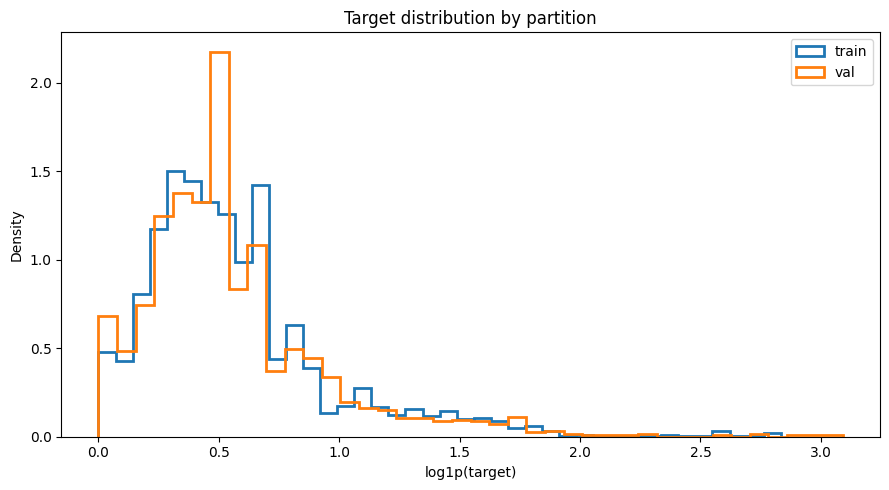

In [9]:
# @title 3.2 Plot the target distribution

TARGET_VIEW = "log1p" # @param ["raw", "log1p"]
HISTOGRAM_BINS = 40 # @param {type:"slider", min:10, max:100, step:5}

plt.figure(figsize=(9, 5))

for split in target_splits:
    values = frames[split][TARGET_COLUMN].dropna()

    if TARGET_VIEW == "log1p":
        if values.lt(0).any():
            raise ValueError(
                "The log1p view cannot be used because negative targets are present."
            )
        values = np.log1p(values)
        x_label = "log1p(target)"
    else:
        x_label = TARGET_COLUMN

    plt.hist(
        values,
        bins=HISTOGRAM_BINS,
        density=True,
        histtype="step",
        linewidth=2,
        label=split,
    )

plt.title("Target distribution by partition")
plt.xlabel(x_label)
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
show_and_save_plot()

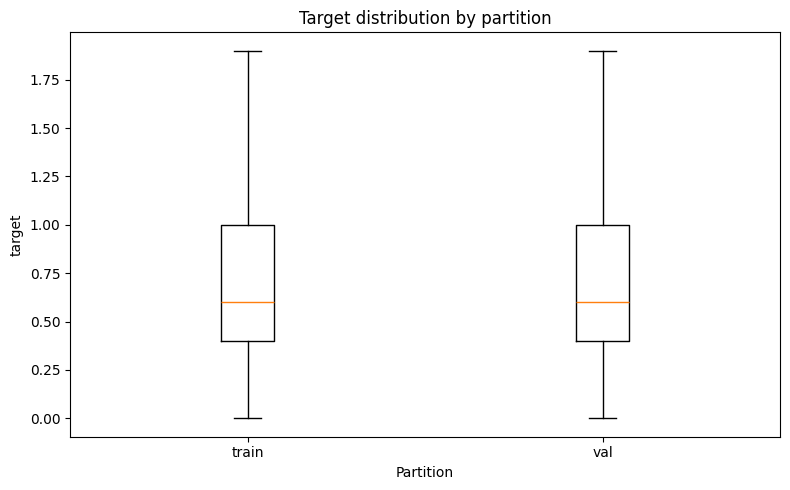

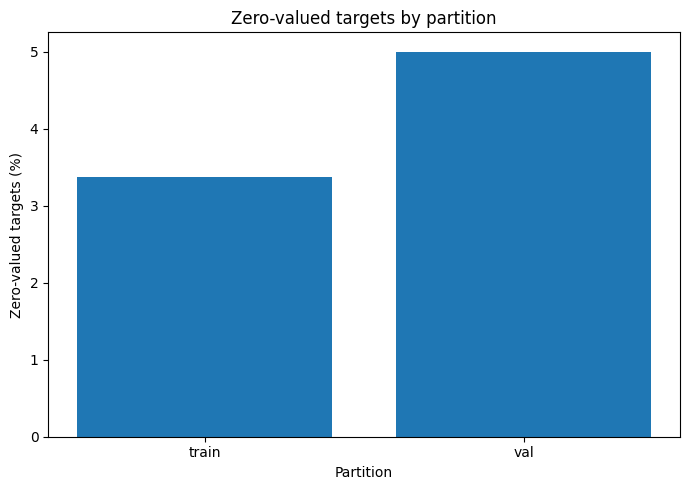

In [10]:
# @title 3.3 Compare target spread and zero-valued observations

SHOW_BOXPLOT_OUTLIERS = False # @param {type:"boolean"}

plt.figure(figsize=(8, 5))
try:
    plt.boxplot(
        [frames[split][TARGET_COLUMN].dropna() for split in target_splits],
        tick_labels=target_splits,
        showfliers=SHOW_BOXPLOT_OUTLIERS,
    )
except TypeError:
    plt.boxplot(
        [frames[split][TARGET_COLUMN].dropna() for split in target_splits],
        labels=target_splits,
        showfliers=SHOW_BOXPLOT_OUTLIERS,
    )
plt.title("Target distribution by partition")
plt.xlabel("Partition")
plt.ylabel(TARGET_COLUMN)
plt.tight_layout()
show_and_save_plot()

zero_rates = [
    100 * frames[split][TARGET_COLUMN].eq(0).mean()
    for split in target_splits
]

plt.figure(figsize=(7, 5))
plt.bar(target_splits, zero_rates)
plt.title("Zero-valued targets by partition")
plt.xlabel("Partition")
plt.ylabel("Zero-valued targets (%)")
plt.tight_layout()
show_and_save_plot()

## Feature distribution shift

The validation and test partitions occur later in time than the training partition. Their feature distributions may therefore differ.

The next cell uses the **standardized mean difference (SMD)**:

\[
\text{SMD} =
\frac{\mu_\text{comparison}-\mu_\text{train}}
{\sqrt{(\sigma^2_\text{comparison}+\sigma^2_\text{train})/2}}
\]

The sign indicates direction. The absolute value indicates how large the mean shift is relative to the pooled spread. SMD is a descriptive diagnostic, not a proof that the shift causes lower model performance.

When both partitions are constant, identical values have SMD 0. Different constant values are labelled `constant_value_changed`; SMD is undefined because the denominator is zero. Those cases remain visible in the table rather than being ranked as no shift.

Special cases: a changed constant is a real change, not an SMD of zero.


,feature,comparison,reference_n,comparison_n,reference_mean,comparison_mean,smd,status


,feature,comparison,reference_n,comparison_n,reference_mean,comparison_mean,smd,status
0,lag_1,val,4180,1600,0.9390,0.9655,0.0198,defined
1,lag_1,test,4180,1600,0.9390,1.0099,0.0520,defined
2,lag_7,val,4180,1600,0.9274,0.9772,0.0388,defined
3,lag_7,test,4180,1600,0.9274,0.9854,0.0446,defined
4,lag_14,val,4180,1600,0.9120,0.9496,0.0323,defined
5,lag_14,test,4180,1600,0.9120,0.9923,0.0637,defined
6,roll_7_mean,val,4180,1600,0.9253,1.0010,0.0631,defined
7,roll_7_mean,test,4180,1600,0.9253,0.9598,0.0287,defined
8,roll_28_mean,val,4180,1600,0.8996,0.9799,0.0771,defined
9,roll_28_mean,test,4180,1600,0.8996,0.9756,0.0694,defined


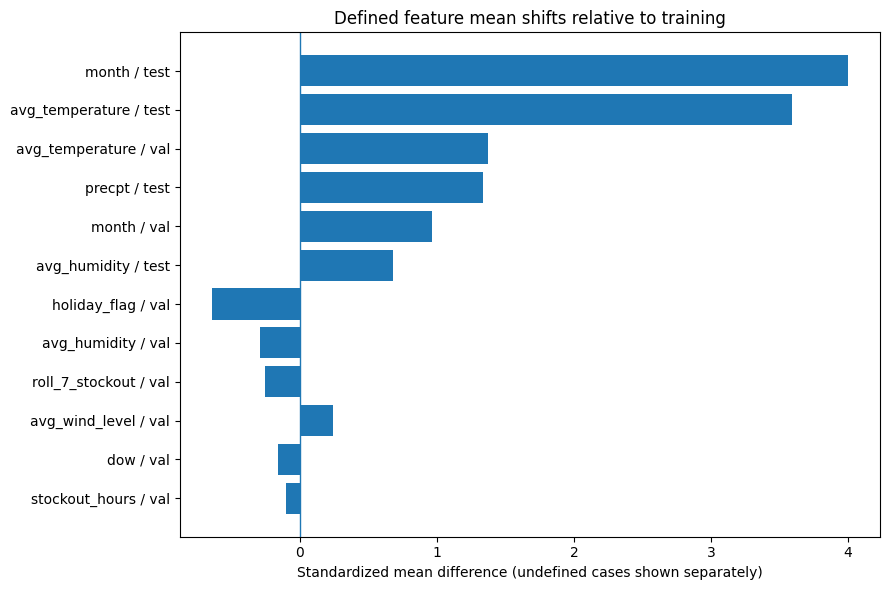

In [11]:
# @title 3.4 Examine feature shift, including constant-valued features
TOP_SHIFT_FEATURES = 12 # @param {type:"slider", min:5, max:17, step:1}
shift_rows=[]
for feature in feature_columns:
    for split in ("val","test"):
        stats=shift_statistics(frames["train"][feature],frames[split][feature])
        shift_rows.append({"feature":feature,"comparison":split,**stats})
shift_report=pd.DataFrame(shift_rows)
print("Special cases: a changed constant is a real change, not an SMD of zero.")
display(shift_report[~shift_report.status.isin(["defined","identical_constants"])])
display(shift_report.round(4))
finite=shift_report[shift_report.smd.notna()].copy()
finite["absolute_smd"]=finite.smd.abs()
plot_data=finite.nlargest(TOP_SHIFT_FEATURES,"absolute_smd").sort_values("absolute_smd")
if not plot_data.empty:
    plt.figure(figsize=(9,6))
    plt.barh(plot_data.feature+" / "+plot_data.comparison,plot_data.smd)
    plt.axvline(0,linewidth=1)
    plt.title("Defined feature mean shifts relative to training")
    plt.xlabel("Standardized mean difference (undefined cases shown separately)")
    plt.tight_layout();show_and_save_plot()

,correlation
discount,-0.0449
precpt,0.0429
roll_7_stockout,0.0476
stockout_hours,0.0524
holiday_flag,0.1403
dow,0.1406
roll_7_std,0.4204
lag_14,0.4663
lag_1,0.4812
lag_7,0.4893


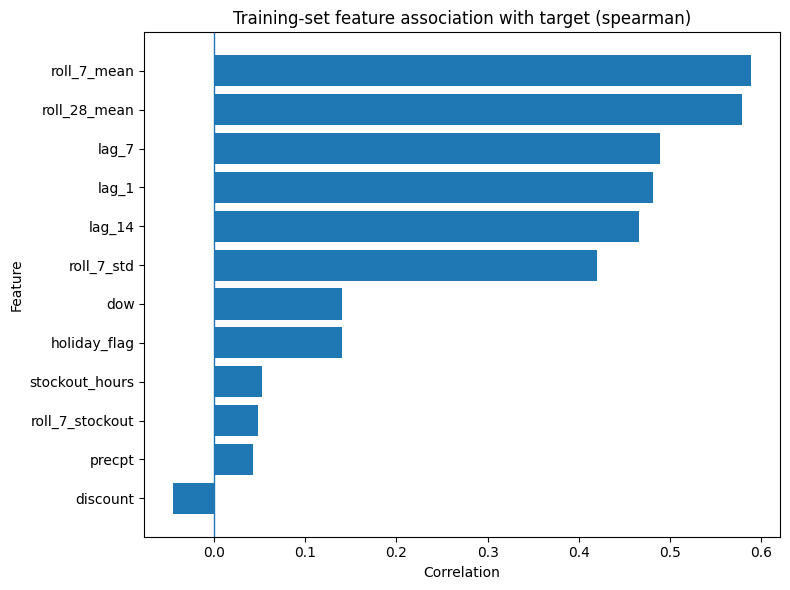

In [12]:
# @title 3.5 Rank training-set feature associations with the target

CORRELATION_METHOD = "spearman" # @param ["spearman", "pearson"]
TOP_CORRELATED_FEATURES = 12 # @param {type:"slider", min:5, max:17, step:1}

training_numeric = frames["train"][
    feature_columns + [TARGET_COLUMN]
].apply(pd.to_numeric, errors="coerce")

correlations = (
    training_numeric
    .corr(method=CORRELATION_METHOD)[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
)

ordered_features = (
    correlations.abs()
    .sort_values(ascending=False)
    .head(TOP_CORRELATED_FEATURES)
    .index
)

correlation_report = (
    correlations.loc[ordered_features]
    .sort_values()
    .rename("correlation")
    .to_frame()
)

display(correlation_report.round(4))

plt.figure(figsize=(8, 6))
plt.barh(
    correlation_report.index,
    correlation_report["correlation"],
)
plt.axvline(0, linewidth=1)
plt.title(
    f"Training-set feature association with target "
    f"({CORRELATION_METHOD})"
)
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
show_and_save_plot()

### Interpreting correlation

- A positive value means larger feature values tend to occur with larger target values.
- A negative value means larger feature values tend to occur with smaller target values.
- A value near zero means no strong monotonic or linear relationship was detected.
- Correlation can miss nonlinear relationships.
- Correlation does not establish that changing the feature would cause the target to change.

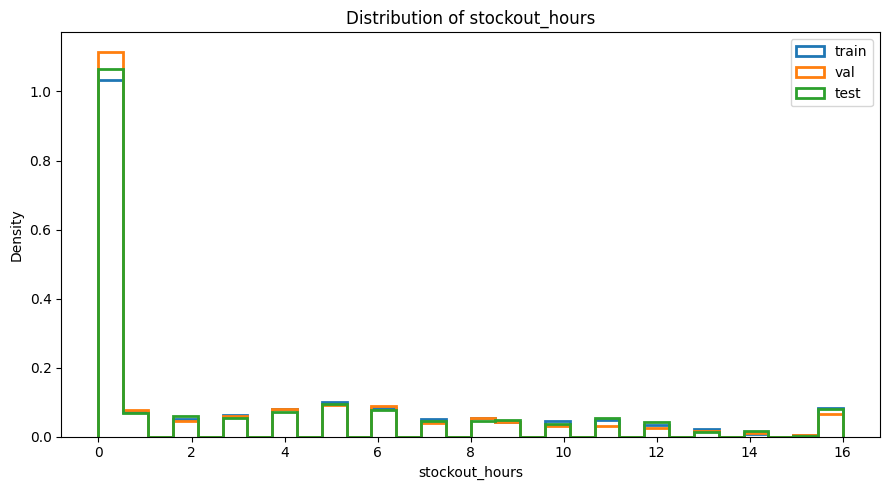

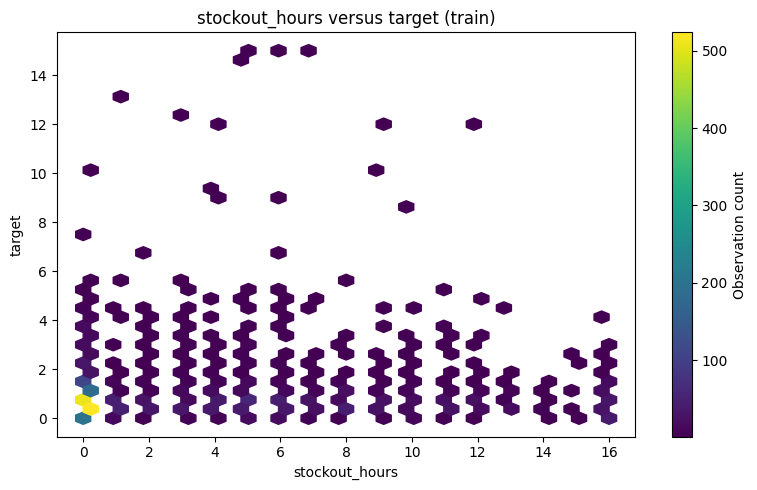

,feature_bin,count,mean,median
0,"(-0.001, 2.0]",2579,0.8425,0.6
1,"(2.0, 5.0]",543,1.3242,0.7
2,"(5.0, 7.0]",297,1.2585,0.7
3,"(7.0, 11.0]",423,1.0647,0.7
4,"(11.0, 16.0]",338,0.8829,0.6


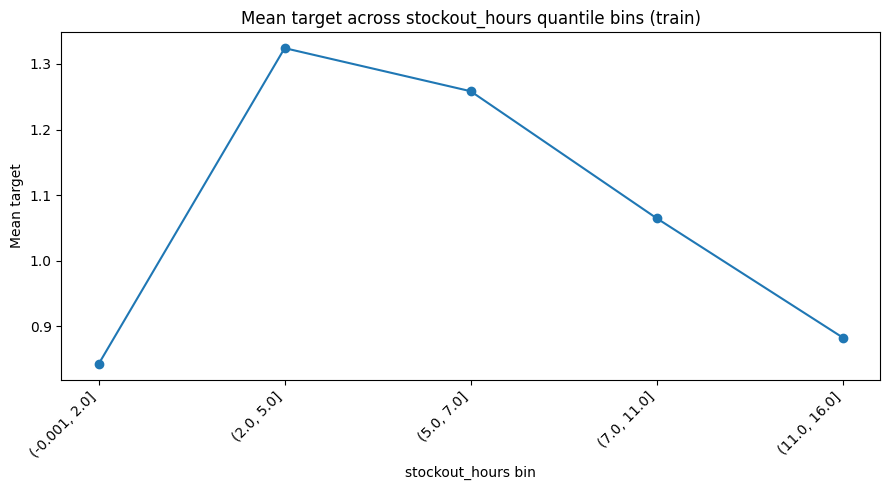

In [13]:
# @title 3.6 Explore one feature in detail

FEATURE = "stockout_hours" # @param ["lag_1", "lag_7", "lag_14", "roll_7_mean", "roll_28_mean", "roll_7_std", "stockout_hours", "roll_7_stockout", "discount", "holiday_flag", "activity_flag", "precpt", "avg_temperature", "avg_humidity", "avg_wind_level", "dow", "month"]
RELATIONSHIP_SPLIT = "train" # @param ["train", "val", "test"]
FEATURE_HISTOGRAM_BINS = 30 # @param {type:"slider", min:10, max:80, step:5}
MAX_SCATTER_POINTS = 3000 # @param {type:"slider", min:500, max:7000, step:500}
QUANTILE_BINS = 10 # @param {type:"slider", min:4, max:20, step:1}

if FEATURE not in feature_columns:
    raise ValueError(f"Feature not found: {FEATURE}")

plt.figure(figsize=(9, 5))

for split in ("train", "val", "test"):
    values = pd.to_numeric(
        frames[split][FEATURE],
        errors="coerce",
    ).dropna()

    plt.hist(
        values,
        bins=FEATURE_HISTOGRAM_BINS,
        density=True,
        histtype="step",
        linewidth=2,
        label=split,
    )

plt.title(f"Distribution of {FEATURE}")
plt.xlabel(FEATURE)
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
show_and_save_plot()

if (
    RELATIONSHIP_SPLIT == "test"
    and not INCLUDE_TEST_TARGETS_IN_EDA
):
    raise ValueError(
        "Test targets are sealed for EDA. "
        "Choose train or val, or explicitly enable test-target EDA."
    )

relationship_frame = (
    frames[RELATIONSHIP_SPLIT][[FEATURE, TARGET_COLUMN]]
    .apply(pd.to_numeric, errors="coerce")
    .dropna()
)

unique_values = relationship_frame[FEATURE].nunique()

if unique_values <= 12:
    grouped = (
        relationship_frame
        .groupby(FEATURE, observed=True)[TARGET_COLUMN]
        .agg(["count", "mean", "median"])
        .reset_index()
    )

    display(grouped.round(4))

    plt.figure(figsize=(9, 5))
    plt.bar(
        grouped[FEATURE].astype(str),
        grouped["mean"],
    )
    plt.title(
        f"Mean target by {FEATURE} "
        f"({RELATIONSHIP_SPLIT})"
    )
    plt.xlabel(FEATURE)
    plt.ylabel("Mean target")
    plt.tight_layout()
    show_and_save_plot()
else:
    sample_size = min(
        MAX_SCATTER_POINTS,
        len(relationship_frame),
    )

    sampled = relationship_frame.sample(
        n=sample_size,
        random_state=RANDOM_SEED,
    )

    plt.figure(figsize=(8, 5))
    plt.hexbin(
        sampled[FEATURE],
        sampled[TARGET_COLUMN],
        gridsize=35,
        mincnt=1,
    )
    plt.colorbar(label="Observation count")
    plt.title(
        f"{FEATURE} versus target "
        f"({RELATIONSHIP_SPLIT})"
    )
    plt.xlabel(FEATURE)
    plt.ylabel(TARGET_COLUMN)
    plt.tight_layout()
    show_and_save_plot()

    bins = pd.qcut(
        relationship_frame[FEATURE],
        q=min(QUANTILE_BINS, unique_values),
        duplicates="drop",
    )

    binned_summary = (
        relationship_frame
        .assign(feature_bin=bins)
        .groupby("feature_bin", observed=True)[TARGET_COLUMN]
        .agg(["count", "mean", "median"])
        .reset_index()
    )

    display(binned_summary.round(4))

    plt.figure(figsize=(9, 5))
    plt.plot(
        range(len(binned_summary)),
        binned_summary["mean"],
        marker="o",
    )
    plt.xticks(
        range(len(binned_summary)),
        binned_summary["feature_bin"].astype(str),
        rotation=45,
        ha="right",
    )
    plt.title(
        f"Mean target across {FEATURE} quantile bins "
        f"({RELATIONSHIP_SPLIT})"
    )
    plt.xlabel(f"{FEATURE} bin")
    plt.ylabel("Mean target")
    plt.tight_layout()
    show_and_save_plot()

## EDA checkpoint

Write brief answers before training a model:

1. Is the target strongly skewed?
2. How common are zero-valued targets?
3. Which feature has the strongest association with the target?
4. Which features shift most between training and validation?
5. What relationship do you observe between stockout exposure and future observed sales?
6. Which observations are descriptive associations rather than causal evidence?

**Your notes:**

- Target distribution:
- Largest feature shift:
- Strongest feature association:
- Stockout observation:
- One modeling implication:
- One limitation:

# 4. Establish a controlled evaluation protocol

## Metrics used in this activity

### Mean absolute error (MAE)

\[
\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
\]

MAE is the average absolute error in the target's original scale. Lower is better.

### Root mean squared error (RMSE)

\[
\text{RMSE} =
\sqrt{
\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
}
\]

RMSE penalizes large errors more strongly than MAE. Lower is better.

### Median absolute error

This is the median of all absolute errors. It is less sensitive to extreme errors than MAE.

### Coefficient of determination (\(R^2\))

\(R^2\) compares squared errors with a constant predictor based on the mean of the **evaluated partition**. Higher is better, but negative values are possible when a model performs worse than that reference.

### Why MAPE is not the primary metric

Approximately 3.4% of target observations are zero-valued. Percentage error is undefined when the true value is zero and can become unstable near zero.

In [14]:
# @title 4.1 Define shared regression metrics

def regression_metrics(
    y_true: pd.Series | np.ndarray,
    y_pred: pd.Series | np.ndarray,
) -> dict[str, float]:
    y_true_array = np.asarray(y_true, dtype=float)
    y_pred_array = np.asarray(y_pred, dtype=float)

    if y_true_array.shape != y_pred_array.shape:
        raise ValueError(
            f"Shape mismatch: y_true={y_true_array.shape}, "
            f"y_pred={y_pred_array.shape}"
        )

    if not np.isfinite(y_true_array).all():
        raise ValueError("y_true contains a non-finite value.")

    if not np.isfinite(y_pred_array).all():
        raise ValueError("y_pred contains a non-finite value.")

    return {
        "mae": float(mean_absolute_error(y_true_array, y_pred_array)),
        "rmse": float(
            np.sqrt(mean_squared_error(y_true_array, y_pred_array))
        ),
        "median_absolute_error": float(
            median_absolute_error(y_true_array, y_pred_array)
        ),
        "r2": float(r2_score(y_true_array, y_pred_array)),
    }

def make_result_record(
    *,
    model_key: str,
    model: str,
    family: str,
    condition: str,
    partition: str,
    y_true: pd.Series | np.ndarray,
    y_pred: pd.Series | np.ndarray,
    runtime_seconds: float | None = None,
    effective_mode: str | None = None,
    licence: str | None = None,
    notes: str | None = None,
) -> dict[str, Any]:
    record = {
        "model_key": model_key,
        "model": model,
        "family": family,
        "condition": condition,
        "partition": partition,
        **regression_metrics(y_true, y_pred),
        "runtime_seconds": runtime_seconds,
        "effective_mode": effective_mode,
        "licence": licence,
        "notes": notes,
        "device": "cpu",
    }
    return record

print("Metric functions are ready.")

Metric functions are ready.


## Baseline ladder

A meaningful experiment should not compare a foundation model only with a weak constant predictor. This notebook uses a baseline ladder:

1. **Training mean:** the same prediction for every row;
2. **Rolling-seven-day mean:** a domain-informed historical baseline;
3. **Ridge regression:** a regularized linear model;
4. **Random Forest:** a nonlinear tree ensemble; and
5. **LightGBM:** a gradient-boosted tree model.

A foundation model adds practical value only if it improves on relevant alternatives under the same split and metrics.

In [15]:
# @title 4.2 Fit, validate, and retain classical baseline artifacts
RF_TREES = 300 # @param {type:"slider", min:100, max:1000, step:100}
LGBM_ESTIMATORS = 500 # @param {type:"slider", min:100, max:1500, step:100}
LGBM_LEARNING_RATE = 0.05 # @param {type:"number"}
assert_current_data();SESSION.assert_development()


def classical_parameters(key):
    if key.startswith("training_mean"):return {"method":"training_mean"}
    if key.startswith("rolling_7_mean"):return {"method":"rolling_7_mean"}
    if key.startswith("ridge"):return {"alpha":1.0}
    if key.startswith("random_forest"):return {"n_estimators":RF_TREES,"min_samples_leaf":2,"random_state":RANDOM_SEED}
    if key.startswith("lightgbm"):return {"n_estimators":LGBM_ESTIMATORS,"learning_rate":LGBM_LEARNING_RATE,
                                        "num_leaves":31,"colsample_bytree":0.9,"random_state":RANDOM_SEED}
    raise KeyError(key)

def classical_controls(key, features=None):
    return {**base_controls(features),"backend":"classical","parameters":classical_parameters(key),
            "software_versions":SOFTWARE_VERSIONS,"adapter_version":"classical-workshop-v2"}

model_templates={
 "ridge":Pipeline([("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler()),("model",Ridge(alpha=1.0))]),
 "random_forest":Pipeline([("imputer",SimpleImputer(strategy="median")),
                  ("model",RandomForestRegressor(**classical_parameters("random_forest"),n_jobs=-1))])}
if LIGHTGBM_AVAILABLE:
    model_templates["lightgbm"]=Pipeline([("imputer",SimpleImputer(strategy="median")),
                               ("model",LGBMRegressor(**classical_parameters("lightgbm"),n_jobs=-1,verbosity=-1))])
models={"training_mean":ReferenceRegressor(y_train.mean()),
        "rolling_7_mean":ReferenceRegressor(y_train.mean(),"roll_7_mean"),
        **{k:clone(v) for k,v in model_templates.items()}}
names={"training_mean":"Training Mean","rolling_7_mean":"Rolling 7-Day Mean","ridge":"Ridge Regression",
       "random_forest":"Random Forest","lightgbm":"LightGBM"}
fitted_models={};CLASSICAL_RECEIPTS=[];validation_predictions={}
for key,model in models.items():
    start=time.perf_counter()
    if key in model_templates:model.fit(X_train,y_train)
    elapsed=time.perf_counter()-start
    ctrl=classical_controls(key)
    identity={"experiment_id":SESSION.experiment_id,"model_key":key,"controls":ctrl,
              "split_sha256":DATASET_IDENTITY["split_sha256"],"features":feature_columns}
    receipt=save_classical_run(SESSION,key,model,frames["train"],frames["val"],ctrl,fit_seconds=elapsed,
               identity=identity,model_name=names[key],family="Naive baseline" if key not in model_templates else "Classical ML",
               mode="fixed" if key not in model_templates else "trained from scratch")
    CLASSICAL_RECEIPTS.append(receipt);fitted_models[key]=model
    validation_predictions[key]=np.asarray(model.predict(X_val),dtype=float)
CURRENT_CLASSICAL_KEYS=list(models)
baseline_validation_results,_=load_results(CLASSICAL_RECEIPTS,frames["val"])
baseline_records=baseline_validation_results.to_dict("records")
display(baseline_validation_results[["model","mae","rmse","median_absolute_error","r2","runtime_seconds"]].round(5))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,mae,rmse,median_absolute_error,r2,runtime_seconds
0,Training Mean,0.69568,1.37177,0.46039,-0.00041,0.00066
1,Rolling 7-Day Mean,0.38919,0.76741,0.23857,0.68691,0.00088
2,Ridge Regression,0.39827,0.78233,0.24810,0.67462,0.02779
3,Random Forest,0.37644,0.69882,0.23805,0.74037,11.07837
4,LightGBM,0.37341,0.70548,0.23050,0.73540,1.40541


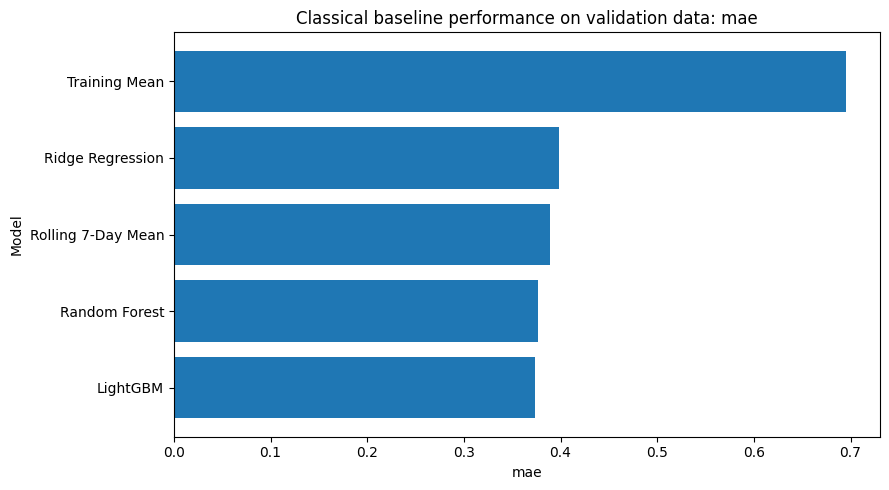

In [16]:
# @title 4.3 Visualize baseline validation performance

PLOT_METRIC = "mae" # @param ["mae", "rmse", "median_absolute_error", "r2"]

plot_results = baseline_validation_results.sort_values(
    PLOT_METRIC,
    ascending=(PLOT_METRIC != "r2"),
)

plt.figure(figsize=(9, 5))
plt.barh(
    plot_results["model"],
    plot_results[PLOT_METRIC],
)
plt.title(f"Classical baseline performance on validation data: {PLOT_METRIC}")
plt.xlabel(PLOT_METRIC)
plt.ylabel("Model")
plt.tight_layout()
show_and_save_plot(run_ids=plot_results.run_id.dropna().tolist())

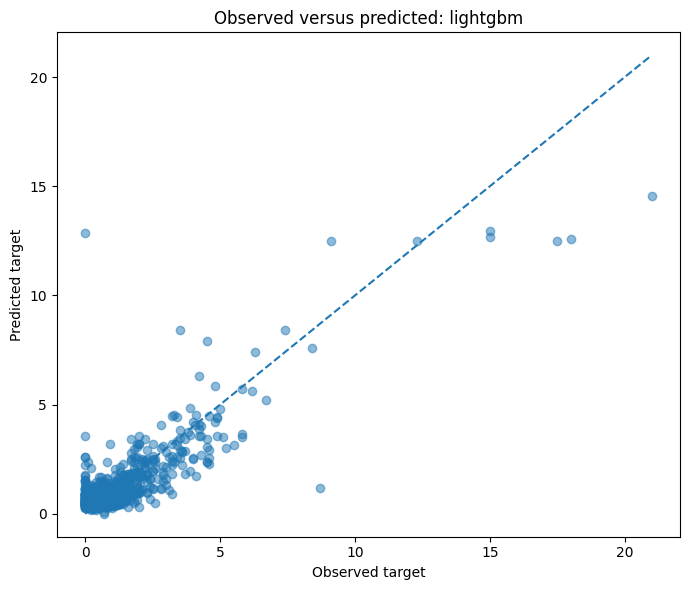

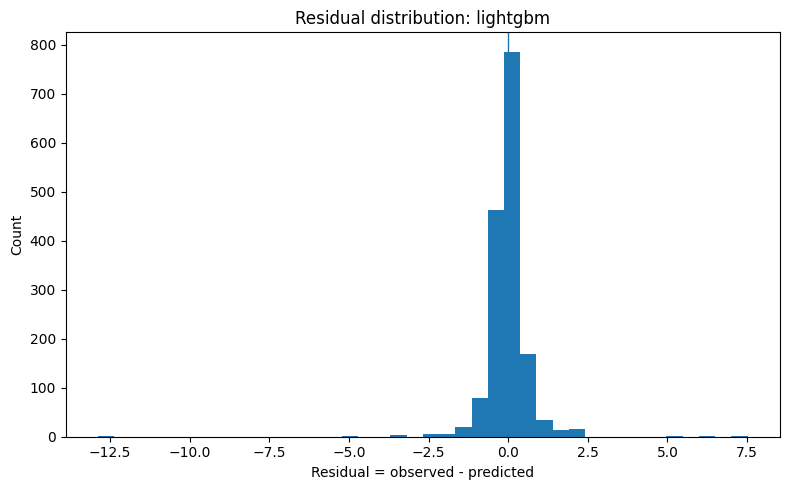

In [17]:
# @title 4.4 Inspect one baseline's predictions

BASELINE_TO_INSPECT = "" # @param {type:"string"}
MAX_POINTS = 1600 # @param {type:"slider", min:200, max:1600, step:200}

BASELINE_TO_INSPECT=choose_diagnostic_model(validation_predictions,BASELINE_TO_INSPECT)
if BASELINE_TO_INSPECT not in validation_predictions:
    raise ValueError(
        f"No validation predictions found for {BASELINE_TO_INSPECT}. "
        "Choose a model that was fitted successfully."
    )

inspection = pd.DataFrame(
    {
        "observed": y_val.to_numpy(),
        "predicted": validation_predictions[BASELINE_TO_INSPECT],
    }
)

if len(inspection) > MAX_POINTS:
    inspection = inspection.sample(
        n=MAX_POINTS,
        random_state=RANDOM_SEED,
    )

lower = float(
    min(inspection["observed"].min(), inspection["predicted"].min())
)
upper = float(
    max(inspection["observed"].max(), inspection["predicted"].max())
)

plt.figure(figsize=(7, 6))
plt.scatter(
    inspection["observed"],
    inspection["predicted"],
    alpha=0.5,
)
plt.plot([lower, upper], [lower, upper], linestyle="--")
plt.title(f"Observed versus predicted: {BASELINE_TO_INSPECT}")
plt.xlabel("Observed target")
plt.ylabel("Predicted target")
plt.tight_layout()
show_and_save_plot(run_ids=baseline_validation_results.loc[baseline_validation_results.model_key.eq(BASELINE_TO_INSPECT),"run_id"].tolist())

residuals = inspection["observed"] - inspection["predicted"]

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=40)
plt.axvline(0, linewidth=1)
plt.title(f"Residual distribution: {BASELINE_TO_INSPECT}")
plt.xlabel("Residual = observed - predicted")
plt.ylabel("Count")
plt.tight_layout()
show_and_save_plot(run_ids=baseline_validation_results.loc[baseline_validation_results.model_key.eq(BASELINE_TO_INSPECT),"run_id"].tolist())

## Baseline checkpoint

Answer the following:

1. Which baseline has the lowest validation MAE?
2. Does the same model also have the lowest RMSE?
3. Is its \(R^2\) positive?
4. Does one model make a small number of very large errors?
5. Does a complex classical model clearly improve on the rolling-seven-day mean?

Do not open the test metrics yet. The validation results are sufficient for model comparison at this stage.

# 5. Run the tabular foundation models locally in Colab

The regressors in this section execute inside the notebook. You do **not** submit model jobs through DIMER.

The notebook carries the reviewed public adapters from the pinned pipeline revisions represented by the DIMER profiles. Each model stack runs in its own Python 3.12 virtual environment and is invoked through the carried public adapter API; no DIMER pipeline repository is cloned or installed at runtime.

## Why use isolated environments?

The four model stacks pin different versions of PyTorch, NumPy, pandas, scikit-learn, Hugging Face Hub, and other packages. Installing them all into the main notebook environment could replace packages that the EDA and classical-baseline sections already use.

Isolation provides three advantages:

1. each model receives the dependency versions declared by its own repository;
2. one model's installation cannot silently change another model's runtime; and
3. the notebook can record the exact repository commit and package set used for each result.

## Public notebook capabilities

- **Mitra:** in-context learning; optional GPU fine-tuning
- **TabDPT:** in-context learning only
- **TabPFN-3:** in-context learning only in the public pipeline; v3 weights are non-commercial
- **TabICLv2:** in-context learning; optional GPU fine-tuning

The first environment build can be slow and storage-intensive. Select fewer models when workshop time or runtime storage is limited.

In [18]:
# @title 5.1 Select the foundation-model conditions

RUN_MITRA_ICL = True # @param {type:"boolean"}
RUN_TABDPT_ICL = True # @param {type:"boolean"}
RUN_TABPFN3_ICL = True # @param {type:"boolean"}
RUN_TABICLV2_ICL = True # @param {type:"boolean"}

RUN_MITRA_FINETUNED = False # @param {type:"boolean"}
RUN_TABICLV2_FINETUNED = False # @param {type:"boolean"}

DEVICE_PREFERENCE = "auto" # @param ["auto", "cpu", "cuda"]
REBUILD_MODEL_ENVIRONMENTS = False # @param {type:"boolean"}
FORCE_MODEL_RERUN = False # @param {type:"boolean"}
REQUIRE_ALL_SELECTED_MODELS = True # @param {type:"boolean"}
# Fitted artifacts are always retained until the runtime ends; final testing reloads them.

MITRA_TIME_LIMIT_SECONDS = 600 # @param {type:"integer"}
MITRA_FINE_TUNE_STEPS = 50 # @param {type:"slider", min:10, max:100, step:10}

TABDPT_N_ENSEMBLES = 4 # @param {type:"slider", min:1, max:16, step:1}
TABDPT_CONTEXT_SIZE = 4180 # @param {type:"integer"}
TABDPT_BATCH_SIZE = 4096 # @param {type:"integer"}

TABPFN_N_ESTIMATORS = 4 # @param {type:"slider", min:1, max:16, step:1}
TABICL_N_ESTIMATORS = 8 # @param {type:"slider", min:1, max:32, step:1}
TABICL_FINE_TUNE_EPOCHS = 10 # @param {type:"slider", min:1, max:30, step:1}
TABICL_FINE_TUNE_TIME_LIMIT = 600 # @param {type:"integer"}
TABICL_FINE_TUNE_PATIENCE = 3 # @param {type:"integer"}

MODEL_REPOSITORIES = {
    "mitra": {
        "repository": "kurtvalcorza/mitra-regressor-pipeline",
        "commit": "a2b36c21fe92d9e42e2f3310c98e9e1c7fe8d7af",
        "import_name": "mitra_pipeline",
        "licence": "Apache-2.0",
    },
    "tabdpt": {
        "repository": "kurtvalcorza/tabdpt-regressor-pipeline",
        "commit": "21085dd2e148041d8fa88944c21532b4bdf9a7ea",
        "import_name": "tabdpt_regressor_pipeline",
        "licence": "Apache-2.0",
    },
    "tabpfn": {
        "repository": "kurtvalcorza/tabpfn-regressor-pipeline",
        "commit": "45dddb070326b9994a18e689add0546d30684239",
        "import_name": "tabpfn_regressor_pipeline",
        "licence": "TabPFN-3 licence v1.0 — non-commercial weights",
    },
    "tabicl": {
        "repository": "kurtvalcorza/tabicl-regressor-pipeline",
        "commit": "08146a323d516fb8dc9aac7f51ad17994e37294c",
        "import_name": "tabicl_regressor_pipeline",
        "licence": "BSD-3-Clause",
    },
}

CONDITION_SPECS = {
    "mitra_icl": {
        "environment": "mitra",
        "model_family": "mitra",
        "display_name": "Mitra Regressor",
        "condition": "in_context",
        "configuration": {
            "fine_tune": False,
            "time_limit_seconds": MITRA_TIME_LIMIT_SECONDS,
            "fine_tune_steps": 0,
        },
    },
    "mitra_finetuned": {
        "environment": "mitra",
        "model_family": "mitra",
        "display_name": "Mitra Regressor",
        "condition": "fine_tuned",
        "configuration": {
            "fine_tune": True,
            "time_limit_seconds": MITRA_TIME_LIMIT_SECONDS,
            "fine_tune_steps": MITRA_FINE_TUNE_STEPS,
        },
    },
    "tabdpt_icl": {
        "environment": "tabdpt",
        "model_family": "tabdpt",
        "display_name": "TabDPT v1.2 Regressor",
        "condition": "in_context",
        "configuration": {
            "n_ensembles": TABDPT_N_ENSEMBLES,
            "context_size": TABDPT_CONTEXT_SIZE,
            "batch_size": TABDPT_BATCH_SIZE,
        },
    },
    "tabpfn3_icl": {
        "environment": "tabpfn",
        "model_family": "tabpfn",
        "display_name": "TabPFN-3 Regressor",
        "condition": "in_context",
        "configuration": {
            "n_estimators": TABPFN_N_ESTIMATORS,
        },
    },
    "tabiclv2_icl": {
        "environment": "tabicl",
        "model_family": "tabicl",
        "display_name": "TabICLv2 Regressor",
        "condition": "in_context",
        "configuration": {
            "n_estimators": TABICL_N_ESTIMATORS,
        },
    },
    "tabiclv2_finetuned": {
        "environment": "tabicl",
        "model_family": "tabicl",
        "display_name": "TabICLv2 Regressor",
        "condition": "fine_tuned",
        "configuration": {
            "n_estimators": TABICL_N_ESTIMATORS,
            "fine_tune_epochs": TABICL_FINE_TUNE_EPOCHS,
            "fine_tune_time_limit": TABICL_FINE_TUNE_TIME_LIMIT,
            "fine_tune_patience": TABICL_FINE_TUNE_PATIENCE,
        },
    },
}

selected_foundation_conditions = []

if RUN_MITRA_ICL:
    selected_foundation_conditions.append("mitra_icl")
if RUN_TABDPT_ICL:
    selected_foundation_conditions.append("tabdpt_icl")
if RUN_TABPFN3_ICL:
    selected_foundation_conditions.append("tabpfn3_icl")
if RUN_TABICLV2_ICL:
    selected_foundation_conditions.append("tabiclv2_icl")
if RUN_MITRA_FINETUNED:
    selected_foundation_conditions.append("mitra_finetuned")
if RUN_TABICLV2_FINETUNED:
    selected_foundation_conditions.append("tabiclv2_finetuned")

run_plan_rows = []

for condition_key in selected_foundation_conditions:
    condition = CONDITION_SPECS[condition_key]
    repository = MODEL_REPOSITORIES[condition["environment"]]

    run_plan_rows.append(
        {
            "model_key": condition_key,
            "model": condition["display_name"],
            "condition": condition["condition"],
            "repository": repository["repository"],
            "repository_commit": repository["commit"],
            "weights_licence": repository["licence"],
            "device_preference": DEVICE_PREFERENCE,
            "configuration": json.dumps(
                condition["configuration"],
                sort_keys=True,
            ),
        }
    )

foundation_run_plan = pd.DataFrame(run_plan_rows)

if foundation_run_plan.empty:
    print("No foundation-model conditions selected.")
else:
    display(foundation_run_plan)
# Immutable model provenance retained alongside the pinned repository revision.
MODEL_PROVENANCE={
 "mitra":{"model_id":"autogluon/mitra-regressor","revision":"5f277aa8f69042d39d6ac3612aed18bb9279bd95",
          "weights_sha256":"d8e75c62af0bec2fd404b0ad20a442d951d43ca6d331315cfcc0509b54f2c642"},
 "tabdpt":{"model_id":"Layer6/TabDPT","revision":"4462ffbd1d8dea25d4862d30beed4b70cd596ae5",
           "weights_sha256":"06680220fd66c4524051706b98c1c659a674d19d3a766cd0bb276505e99faccd"},
 "tabpfn":{"model_id":"Prior-Labs/tabpfn_3","revision":"24a16a89d245878b846555110985634aa2e656d7",
           "weights_sha256":"311ce18d97e9533d8585eaadafe040fbdd8070533209ed8696641dadc97a7301"},
 "tabicl":{"model_id":"jingang/TabICL","revision":"4dcd344ece2c00be9e831fdd35bed57b5ad83e19",
           "weights_sha256":"0db9cb538f114e79026bf08f45f41ad8dd7ad2de2aaca9a5ca8cd3bd9748ae7a"}}
CURRENT_FOUNDATION_KEYS=list(selected_foundation_conditions)


,model_key,model,condition,repository,repository_commit,weights_licence,device_preference,configuration
0,mitra_icl,Mitra Regressor,in_context,kurtvalcorza/mitra-regressor-pipeline,a2b36c21fe92d9e42e2f3310c98e9e1c7fe8d7af,Apache-2.0,auto,"{""fine_tune"": false, ""fine_tune_steps"": 0, ""ti..."
1,tabdpt_icl,TabDPT v1.2 Regressor,in_context,kurtvalcorza/tabdpt-regressor-pipeline,21085dd2e148041d8fa88944c21532b4bdf9a7ea,Apache-2.0,auto,"{""batch_size"": 4096, ""context_size"": 4180, ""n_..."
2,tabpfn3_icl,TabPFN-3 Regressor,in_context,kurtvalcorza/tabpfn-regressor-pipeline,45dddb070326b9994a18e689add0546d30684239,TabPFN-3 licence v1.0 — non-commercial weights,auto,"{""n_estimators"": 4}"
3,tabiclv2_icl,TabICLv2 Regressor,in_context,kurtvalcorza/tabicl-regressor-pipeline,08146a323d516fb8dc9aac7f51ad17994e37294c,BSD-3-Clause,auto,"{""n_estimators"": 8}"


## 5.2 Prepare isolated model environments from notebook-carried adapters

The notebook carries the reviewed public adapter modules from the pinned model-pipeline revisions as source text. At runtime it writes those modules into the session workspace, uses `uv` to create isolated Python 3.12 environments, installs only exact upstream dependency pins, and stages the checkpoint manifests used to verify immutable model downloads.

The runtime does **not** clone, fetch, check out, or install any DIMER pipeline repository. Checkpoint files are obtained only from the declared public upstream hosts and are verified against the carried manifests before model use.


In [19]:
# @title 5.2 Stage carried adapters and prepare isolated model environments
import shlex
WORKSHOP_ROOT=WORKSPACE_ROOT
ENVIRONMENT_ROOT=WORKSHOP_ROOT / "environments"
RUNNER_ROOT=SUPPORT_DIR
FOUNDATION_OUTPUT_ROOT=SESSION_ROOT / "runs"
INSTALL_LOG_ROOT=WORKSHOP_ROOT / "install_logs"
CARRIED_SOURCE_ROOT=SESSION_ROOT / "carried_source"
MODEL_WEIGHTS_ROOT=WORKSHOP_ROOT / "model_weights"
CARRIED_ADAPTER_SOURCES={"mitra_pipeline/tutorial_api.py":"\"\"\"Release-grade public API for the Mitra Regressor notebook surface.\n\nThis module owns the repository-facing behavior the notebooks must exercise directly:\nregression data validation, Mitra fit/predict calls, model snapshot locking, and predictor\nartifact validation. Imports that pull in heavy ML dependencies are intentionally delayed so\narchive and manifest checks remain unit-testable in a lightweight CI environment.\n\"\"\"\n\nfrom __future__ import annotations\n\nimport csv\nimport hashlib\nimport io\nimport json\nimport os\nimport random\nimport shutil\nimport stat\nimport tempfile\nimport urllib.request\nimport zipfile\nfrom collections.abc import Callable, Iterable, Mapping, Sequence\nfrom pathlib import Path, PurePosixPath\nfrom typing import Any\n\nimport numpy as np\nimport pandas as pd\n\n# Fleet snapshot identity (DIMER Notebook Specification 1.1, ST3/MOD13). The pinned upstream model is unchanged;\n# these are the fleet-standard names for the same repository, revision, license and snapshot key. The published\n# PINNED_REVISION spelling stays as an alias of MODEL_REVISION.\nMODEL_ID = \"autogluon/mitra-regressor\"\nMODEL_REVISION = \"5f277aa8f69042d39d6ac3612aed18bb9279bd95\"\nMODEL_LICENSE = \"apache-2.0\"\nMODEL_KEY = \"mitra-regressor\"\nMANIFEST_NAME = \"dimer-base-manifest.json\"\n# Root-level package: the repository root is one level up from this file.\nDEFAULT_WEIGHTS_DIR = Path(__file__).resolve().parents[1] / \"weights\" / MODEL_KEY\nWEIGHTS_FILE = \"model.safetensors\"\nCONFIG_FILE = \"config.json\"\n\nPINNED_REVISION = MODEL_REVISION\nWEIGHTS_SHA256 = \"d8e75c62af0bec2fd404b0ad20a442d951d43ca6d331315cfcc0509b54f2c642\"\nCONFIG_SHA256 = \"2bc1ed5047f7c25368245e8ad32540a5fa28940b1ec05d3f1f454a09ff5384c1\"\nMETRIC_IDS = (\"mae\", \"rmse\", \"r2\")  # the ids `regression_metrics` reports\n\nMAX_TRAIN_ROWS = 10_000\nMAX_FEATURES = 500\nMIN_TRAIN_ROWS = 50\n\nARTIFACT_FORMAT = \"dimer-autogluon-predictor\"\nARTIFACT_FORMAT_VERSION = 1\nARTIFACT_MANIFEST = \"artifact_manifest.json\"\nRUN_METADATA = \"tutorial_run_metadata.json\"\nDIMER_MODEL_MANIFEST = \"dimer-model-manifest.json\"\n\nMAX_ARCHIVE_MEMBER_BYTES = 1 * 1024**3\nMAX_ARCHIVE_EXPANDED_BYTES = 4 * 1024**3\nMAX_COMPRESSION_RATIO = 200.0\n\nREGRESSION_LOWER_IS_BETTER = {\n    \"root_mean_squared_error\",\n    \"mean_squared_error\",\n    \"mean_absolute_error\",\n    \"median_absolute_error\",\n    \"mean_absolute_percentage_error\",\n    \"symmetric_mean_absolute_percentage_error\",\n    \"root_mean_squared_logarithmic_error\",\n}\nMITRA_METRIC_MAP = {\n    \"mean_absolute_error\": \"mae\",\n    \"root_mean_squared_error\": \"rmse\",\n}\n\nREQUIRED_RUN_METADATA_FIELDS = {\n    \"artifact_format\",\n    \"artifact_format_version\",\n    \"base_model\",\n    \"base_model_revision\",\n    \"weights_sha256\",\n    \"config_sha256\",\n    \"autogluon_version\",\n    \"python_version\",\n    \"problem_type\",\n    \"target_column\",\n    \"features\",\n    \"mode\",\n    \"selection_basis\",\n}\n\n\ndef sha256_file(path: str | Path) -> str:\n    h = hashlib.sha256()\n    with open(path, \"rb\") as handle:\n        for chunk in iter(lambda: handle.read(1 << 20), b\"\"):\n            h.update(chunk)\n    return h.hexdigest()\n\n\ndef _assert_hex_digest(value: str, label: str) -> str:\n    digest = str(value).strip().lower()\n    if len(digest) != 64 or any(ch not in \"0123456789abcdef\" for ch in digest):\n        raise ValueError(f\"{label} must be a 64-character hexadecimal SHA-256 digest.\")\n    return digest\n\n\ndef read_csv_bytes(payload: bytes, label: str) -> pd.DataFrame:\n    \"\"\"Parse UTF-8/BOM CSV bytes while rejecting duplicate raw headers before pandas renames them.\"\"\"\n    try:\n        text = payload.decode(\"utf-8-sig\")\n    except UnicodeDecodeError as exc:\n        raise ValueError(f\"{label}: expected UTF-8 CSV input.\") from exc\n\n    rows = csv.reader(io.StringIO(text, newline=\"\"))\n    header = next((row for row in rows if row and not (len(row) == 1 and not row[0].strip())), [])\n    if not header:\n        raise ValueError(f\"{label}: CSV has no header row.\")\n\n    seen: set[str] = set()\n    duplicates: list[str] = []\n    for name in header:\n        if name in seen and name not in duplicates:\n            duplicates.append(name)\n        seen.add(name)\n    if duplicates:\n        raise ValueError(f\"{label}: duplicate column names are not supported: {duplicates}\")\n\n    return pd.read_csv(io.BytesIO(payload))\n\n\ndef validate_labeled_frame(\n    frame: pd.DataFrame,\n    target_column: str,\n    *,\n    name: str,\n    drop_columns: Iterable[str] = (),\n    min_rows: int = 2,\n    require_variation: bool = False,\n) -> tuple[pd.DataFrame, list[str], dict[str, Any]]:\n    \"\"\"Validate one labelled regression table using the repository's user-facing contract.\"\"\"\n    if frame.columns.duplicated().any():\n        duplicates = list(frame.columns[frame.columns.duplicated()])\n        raise ValueError(f\"{name}: duplicate column names are not supported: {duplicates}\")\n    if target_column not in frame.columns:\n        raise ValueError(f\"{name}: target {target_column!r} not found.\")\n\n    drops = [c for c in drop_columns if c != target_column and c in frame.columns]\n    out = frame.drop(columns=drops, errors=\"ignore\").copy()\n    raw_target = out[target_column]\n    numeric_target = pd.to_numeric(raw_target, errors=\"coerce\")\n    non_numeric = raw_target.notna() & numeric_target.isna()\n    if bool(non_numeric.any()):\n        examples = raw_target[non_numeric].astype(str).head(5).tolist()\n        raise ValueError(f\"{name}: target must be numeric; invalid examples: {examples}\")\n    out[target_column] = numeric_target\n\n    rows_before = len(out)\n    out = out.dropna(subset=[target_column]).copy()\n    dropped_target_rows = rows_before - len(out)\n    target_values = out[target_column].to_numpy(dtype=float)\n    if not np.isfinite(target_values).all():\n        raise ValueError(f\"{name}: target contains infinite values; use finite numeric regression targets only.\")\n\n    features = [c for c in out.columns if c != target_column]\n    errors: list[str] = []\n    if len(out) < min_rows:\n        errors.append(f\"use at least {min_rows} labelled rows after missing-target drops\")\n    if not features:\n        errors.append(\"no feature columns remain\")\n    if len(features) > MAX_FEATURES:\n        errors.append(f\"{len(features)} features exceed the {MAX_FEATURES}-feature Mitra ceiling\")\n    if require_variation and out[target_column].nunique(dropna=True) < 2:\n        errors.append(\"training target has no variation\")\n    if errors:\n        raise ValueError(f\"{name} is not ready: \" + \"; \".join(errors))\n\n    report = {\n        \"rows_before_target_drop\": int(rows_before),\n        \"rows_after_target_drop\": int(len(out)),\n        \"dropped_missing_target_rows\": int(dropped_target_rows),\n        \"exact_duplicate_rows\": int(out.duplicated().sum()),\n        \"feature_count\": int(len(features)),\n    }\n    return out, features, report\n\n\ndef cap_training_rows(\n    frame: pd.DataFrame,\n    target_column: str,\n    *,\n    seed: int,\n    max_rows: int = MAX_TRAIN_ROWS,\n) -> tuple[pd.DataFrame, dict[str, Any]]:\n    if max_rows > MAX_TRAIN_ROWS:\n        raise ValueError(f\"max_rows cannot exceed Mitra's {MAX_TRAIN_ROWS:,}-row ceiling.\")\n    before = len(frame)\n    if before <= max_rows:\n        return frame.copy(), {\"applied\": False, \"before\": before, \"after\": before}\n    capped = frame.sample(n=max_rows, random_state=seed).copy()\n    if capped[target_column].nunique(dropna=True) < 2:\n        raise ValueError(\"Capped training split has no target variation; provide a representative pre-split set.\")\n    return capped, {\"applied\": True, \"before\": before, \"after\": len(capped)}\n\n\ndef split_overlap_report(named_frames: dict[str, pd.DataFrame]) -> dict[str, int]:\n    \"\"\"Detect exact record overlap across labelled partitions without mutating them.\"\"\"\n    names = list(named_frames)\n    hashes = {\n        name: set(pd.util.hash_pandas_object(frame, index=False).astype(\"uint64\").tolist())\n        for name, frame in named_frames.items()\n    }\n    report: dict[str, int] = {}\n    for i, left in enumerate(names):\n        for right in names[i + 1 :]:\n            report[f\"{left}_vs_{right}\"] = len(hashes[left].intersection(hashes[right]))\n    return report\n\n\ndef seed_everything(seed: int) -> None:\n    random.seed(seed)\n    np.random.seed(seed)\n    try:\n        import torch\n\n        torch.manual_seed(seed)\n        if torch.cuda.is_available():\n            torch.cuda.manual_seed_all(seed)\n    except Exception:\n        pass\n\n\ndef fit_mitra_predictor(\n    train_data: pd.DataFrame,\n    *,\n    target_column: str,\n    eval_metric: str,\n    path: str | Path,\n    fine_tune: bool,\n    time_limit: int,\n    seed: int,\n    fine_tune_steps: int | None = None,\n    max_memory_usage_ratio: float = 1.10,\n):\n    \"\"\"Fit/register Mitra through the repository's supported notebook API.\n\n    With ``fine_tune=False`` AutoGluon's ``fit`` registers support/context rows and model\n    configuration; Mitra weights are not gradient-updated. With ``fine_tune=True`` the Mitra\n    weights are adapted for the requested number of steps, subject to the time limit.\n    \"\"\"\n    if eval_metric not in MITRA_METRIC_MAP:\n        raise ValueError(f\"Unsupported eval_metric {eval_metric!r}; choose {sorted(MITRA_METRIC_MAP)}\")\n    if fine_tune and (fine_tune_steps is None or fine_tune_steps <= 0):\n        raise ValueError(\"fine_tune_steps must be a positive integer when fine_tune=True.\")\n\n    seed_everything(seed)\n    hp: dict[str, Any] = {\n        \"fine_tune\": bool(fine_tune),\n        \"seed\": int(seed),\n        \"metric\": MITRA_METRIC_MAP[eval_metric],\n    }\n    if fine_tune:\n        hp[\"fine_tune_steps\"] = int(fine_tune_steps)\n\n    from autogluon.tabular import TabularPredictor\n\n    predictor = TabularPredictor(\n        label=target_column,\n        problem_type=\"regression\",\n        eval_metric=eval_metric,\n        path=str(path),\n        verbosity=2,\n    )\n    predictor.fit(\n        train_data,\n        hyperparameters={\"MITRA\": hp},\n        fit_weighted_ensemble=False,\n        time_limit=int(time_limit),\n        ag_args_fit={\"max_memory_usage_ratio\": float(max_memory_usage_ratio)},\n    )\n    trained = list(predictor.model_names())\n    if not trained or not any(\"mitra\" in model.lower() for model in trained):\n        raise RuntimeError(f\"Expected Mitra to fit/register; AutoGluon returned models={trained}.\")\n    return predictor\n\n\ndef normalize_autogluon_regression_metrics(raw: dict[str, Any]) -> dict[str, float]:\n    return {\n        key: float(-value if key in REGRESSION_LOWER_IS_BETTER else value)\n        for key, value in raw.items()\n    }\n\n\ndef regression_metrics(y_true: Iterable[float], y_pred: Iterable[float]) -> dict[str, float]:\n    truth = np.asarray(list(y_true), dtype=float)\n    pred = np.asarray(list(y_pred), dtype=float)\n    if truth.shape != pred.shape:\n        raise ValueError(f\"y_true shape {truth.shape} != y_pred shape {pred.shape}\")\n    err = truth - pred\n    mae = float(np.mean(np.abs(err)))\n    rmse = float(np.sqrt(np.mean(err**2)))\n    denom = float(np.sum((truth - np.mean(truth)) ** 2))\n    r2 = float(1.0 - np.sum(err**2) / denom) if denom > 0 else float(\"nan\")\n    return {\"mae\": mae, \"rmse\": rmse, \"r2\": r2}\n\n\ndef validate_inference_frame(\n    frame: pd.DataFrame,\n    required_features: Iterable[str],\n    *,\n    output_column: str = \"prediction\",\n) -> tuple[pd.DataFrame, list[str]]:\n    if frame.columns.duplicated().any():\n        duplicates = list(frame.columns[frame.columns.duplicated()])\n        raise ValueError(f\"Inference CSV contains duplicate column names: {duplicates}\")\n    required = list(required_features)\n    missing = [column for column in required if column not in frame.columns]\n    if missing:\n        raise ValueError(f\"Inference CSV is missing required feature columns: {missing}\")\n    if output_column in frame.columns:\n        raise ValueError(f\"Inference CSV already contains {output_column!r}; rename or remove it first.\")\n    extra = [column for column in frame.columns if column not in required]\n    return frame.reindex(columns=required).copy(), extra\n\n\ndef predict_regression(predictor, frame: pd.DataFrame, required_features: Iterable[str]) -> np.ndarray:\n    features = list(required_features)\n    missing = [column for column in features if column not in frame.columns]\n    if missing:\n        raise ValueError(f\"Prediction frame is missing required features: {missing}\")\n    predictions = predictor.predict(frame.reindex(columns=features))\n    return np.asarray(predictions, dtype=float)\n\n\ndef _download(url: str, destination: Path, *, timeout: int = 30) -> None:\n    with urllib.request.urlopen(url, timeout=timeout) as response, open(destination, \"wb\") as handle:\n        shutil.copyfileobj(response, handle)\n\n\ndef stage_verified_hf_snapshot(\n    weights_path: str | Path,\n    config_path: str | Path,\n    *,\n    hf_home: str | Path,\n) -> Path:\n    \"\"\"Verify exact Mitra bytes and stage them as the immutable pinned Hugging Face snapshot.\"\"\"\n    weights = Path(weights_path)\n    config = Path(config_path)\n    if sha256_file(weights) != WEIGHTS_SHA256:\n        raise RuntimeError(\"model.safetensors checksum mismatch for the pinned Mitra Regressor release.\")\n    if sha256_file(config) != CONFIG_SHA256:\n        raise RuntimeError(\"config.json checksum mismatch for the pinned Mitra Regressor release.\")\n\n    home = Path(hf_home)\n    repo = home / \"hub\" / (\"models--\" + MODEL_ID.replace(\"/\", \"--\"))\n    snapshot = repo / \"snapshots\" / PINNED_REVISION\n    refs = repo / \"refs\"\n    snapshot.mkdir(parents=True, exist_ok=True)\n    refs.mkdir(parents=True, exist_ok=True)\n    shutil.copy2(weights, snapshot / \"model.safetensors\")\n    shutil.copy2(config, snapshot / \"config.json\")\n    (refs / \"main\").write_text(PINNED_REVISION, encoding=\"utf-8\")\n\n    import huggingface_hub.constants\n\n    real_cache = Path(huggingface_hub.constants.HF_HUB_CACHE)\n    try:\n        if real_cache.resolve() != (home / \"hub\").resolve():\n            real_repo = real_cache / (\"models--\" + MODEL_ID.replace(\"/\", \"--\"))\n            real_snap = real_repo / \"snapshots\" / PINNED_REVISION\n            real_refs = real_repo / \"refs\"\n            real_snap.mkdir(parents=True, exist_ok=True)\n            real_refs.mkdir(parents=True, exist_ok=True)\n            shutil.copy2(weights, real_snap / \"model.safetensors\")\n            shutil.copy2(config, real_snap / \"config.json\")\n            (real_refs / \"main\").write_text(PINNED_REVISION, encoding=\"utf-8\")\n    except Exception:\n        pass\n\n    os.environ[\"HF_HOME\"] = str(home)\n    os.environ[\"HF_HUB_OFFLINE\"] = \"1\"\n    os.environ[\"TRANSFORMERS_OFFLINE\"] = \"1\"\n\n    from huggingface_hub import hf_hub_download\n\n    for filename, expected_digest in (\n        (\"model.safetensors\", WEIGHTS_SHA256),\n        (\"config.json\", CONFIG_SHA256),\n    ):\n        try:\n            resolved = Path(\n                hf_hub_download(\n                    repo_id=MODEL_ID,\n                    filename=filename,\n                    revision=PINNED_REVISION,\n                    cache_dir=str(home / \"hub\"),\n                    local_files_only=True,\n                )\n            ).resolve()\n        except Exception:\n            resolved = Path(\n                hf_hub_download(\n                    repo_id=MODEL_ID,\n                    filename=filename,\n                    revision=PINNED_REVISION,\n                    local_files_only=True,\n                )\n            ).resolve()\n        expected = (snapshot / filename).resolve()\n        if resolved != expected and not resolved.is_file():\n            raise RuntimeError(f\"Offline resolver mismatch for {filename}: {resolved} != {expected}\")\n        if sha256_file(resolved) != expected_digest:\n            raise RuntimeError(f\"Resolved {filename} digest changed after staging.\")\n    return snapshot\n\n\ndef _validate_zip_members(zf: zipfile.ZipFile, destination: Path) -> list[zipfile.ZipInfo]:\n    destination = destination.resolve()\n    total = 0\n    files: list[zipfile.ZipInfo] = []\n    seen_paths: set[str] = set()\n    seen_parent_paths: set[str] = set()\n    for info in zf.infolist():\n        name = info.filename\n        if not name or info.is_dir():\n            continue\n        if \"\\\\\" in name:\n            raise RuntimeError(f\"Backslash archive paths are not allowed: {name!r}\")\n        member = PurePosixPath(name)\n        if member.is_absolute() or \"..\" in member.parts:\n            raise RuntimeError(f\"Unsafe archive member path: {name!r}\")\n        normalized_name = member.as_posix()\n        if normalized_name in seen_paths:\n            raise RuntimeError(f\"Duplicate archive member path is not allowed: {name!r}\")\n        parent_paths = {PurePosixPath(*member.parts[:i]).as_posix() for i in range(1, len(member.parts))}\n        if normalized_name in seen_parent_paths or parent_paths.intersection(seen_paths):\n            raise RuntimeError(f\"Archive member path conflicts with a file/directory boundary: {name!r}\")\n        seen_paths.add(normalized_name)\n        seen_parent_paths.update(parent_paths)\n        mode = (info.external_attr >> 16) & 0o170000\n        if mode == stat.S_IFLNK:\n            raise RuntimeError(f\"Symlink entries are not allowed: {name!r}\")\n        if info.file_size > MAX_ARCHIVE_MEMBER_BYTES:\n            raise RuntimeError(f\"Archive member is too large: {name!r} ({info.file_size:,} bytes).\")\n        if info.compress_size > 0 and info.file_size / info.compress_size > MAX_COMPRESSION_RATIO:\n            raise RuntimeError(f\"Archive member has suspicious compression ratio: {name!r}.\")\n        total += info.file_size\n        if total > MAX_ARCHIVE_EXPANDED_BYTES:\n            raise RuntimeError(\"Archive expanded size exceeds the configured safety ceiling.\")\n        target = (destination / Path(*member.parts)).resolve()\n        if target != destination and destination not in target.parents:\n            raise RuntimeError(f\"Archive member escapes extraction root: {name!r}\")\n        files.append(info)\n    return files\n\n\ndef safe_extract_archive(zip_path: str | Path, destination: str | Path) -> Path:\n    destination_path = Path(destination)\n    with zipfile.ZipFile(zip_path) as zf:\n        # Validate the complete archive before touching any prior extraction destination.\n        infos = _validate_zip_members(zf, destination_path)\n        if destination_path.is_symlink():\n            raise RuntimeError(\"Archive extraction destination must not be a symlink.\")\n        destination_path.parent.mkdir(parents=True, exist_ok=True)\n        staging = Path(tempfile.mkdtemp(prefix=f\".{destination_path.name}.extract-\", dir=destination_path.parent))\n        try:\n            for info in infos:\n                member = PurePosixPath(info.filename)\n                target = staging.joinpath(*member.parts)\n                target.parent.mkdir(parents=True, exist_ok=True)\n                with zf.open(info) as source, open(target, \"wb\") as sink:\n                    shutil.copyfileobj(source, sink)\n            if destination_path.exists():\n                shutil.rmtree(destination_path)\n            staging.replace(destination_path)\n        except Exception:\n            shutil.rmtree(staging, ignore_errors=True)\n            raise\n    return destination_path\n\n\ndef validate_dimer_model_package(\n    zip_path: str | Path,\n    destination: str | Path,\n    *,\n    expected_archive_sha256: str | None = None,\n) -> tuple[Path, Path, dict[str, Any]]:\n    \"\"\"Validate the normative DIMER offline Mitra package before any model load.\"\"\"\n    zip_path = Path(zip_path)\n    if expected_archive_sha256:\n        expected = _assert_hex_digest(expected_archive_sha256, \"expected_archive_sha256\")\n        actual = sha256_file(zip_path)\n        if actual != expected:\n            raise RuntimeError(f\"DIMER model ZIP checksum mismatch: expected {expected}; got {actual}.\")\n\n    root = safe_extract_archive(zip_path, destination)\n    manifest_path = root / DIMER_MODEL_MANIFEST\n    if not manifest_path.is_file():\n        raise RuntimeError(\n            f\"DIMER model ZIP must contain root-level {DIMER_MODEL_MANIFEST}; legacy weight-only ZIPs do not satisfy Notebook Spec 1.0.\"\n        )\n    manifest = json.loads(manifest_path.read_text(encoding=\"utf-8\"))\n    if manifest.get(\"schema_version\") != 1:\n        raise RuntimeError(\"Unsupported DIMER model manifest schema_version.\")\n    if manifest.get(\"model_id\") != MODEL_ID:\n        raise RuntimeError(f\"DIMER package model_id must be {MODEL_ID!r}.\")\n    if manifest.get(\"revision\") != PINNED_REVISION:\n        raise RuntimeError(f\"DIMER package revision must be {PINNED_REVISION!r}.\")\n\n    declared = manifest.get(\"files\")\n    if not isinstance(declared, list) or not declared:\n        raise RuntimeError(\"DIMER model manifest must contain a non-empty files list.\")\n    entries: dict[str, dict[str, Any]] = {}\n    for entry in declared:\n        if not isinstance(entry, dict):\n            raise RuntimeError(\"DIMER model manifest file entries must be objects.\")\n        path = str(entry.get(\"path\", \"\"))\n        if not path or \"\\\\\" in path:\n            raise RuntimeError(f\"Invalid DIMER manifest path: {path!r}\")\n        member = PurePosixPath(path)\n        if member.is_absolute() or \"..\" in member.parts or path in entries:\n            raise RuntimeError(f\"Unsafe or duplicate DIMER manifest path: {path!r}\")\n        entries[path] = entry\n\n    for required in (\"model.safetensors\", \"config.json\"):\n        if required not in entries:\n            raise RuntimeError(f\"DIMER model manifest is missing required file {required!r}.\")\n\n    actual_files = {\n        path.relative_to(root).as_posix()\n        for path in root.rglob(\"*\")\n        if path.is_file() and path != root / DIMER_MODEL_MANIFEST\n    }\n    if actual_files != set(entries):\n        missing = sorted(set(entries) - actual_files)\n        unexpected = sorted(actual_files - set(entries))\n        raise RuntimeError(f\"DIMER model package file inventory mismatch; missing={missing}, unexpected={unexpected}\")\n\n    for rel, entry in entries.items():\n        path = root / rel\n        expected_size = int(entry.get(\"size\", -1))\n        expected_digest = _assert_hex_digest(str(entry.get(\"sha256\", \"\")), f\"sha256 for {rel}\")\n        if path.stat().st_size != expected_size:\n            raise RuntimeError(f\"DIMER model package size mismatch for {rel}.\")\n        if sha256_file(path) != expected_digest:\n            raise RuntimeError(f\"DIMER model package digest mismatch for {rel}.\")\n\n    weights = root / \"model.safetensors\"\n    config = root / \"config.json\"\n    if sha256_file(weights) != WEIGHTS_SHA256 or sha256_file(config) != CONFIG_SHA256:\n        raise RuntimeError(\"DIMER package bytes do not match the pinned Mitra Regressor release.\")\n    return weights, config, manifest\n\n\ndef _artifact_inventory(root: Path) -> list[dict[str, Any]]:\n    inventory = []\n    for path in sorted(p for p in root.rglob(\"*\") if p.is_file() and p != root / ARTIFACT_MANIFEST):\n        rel = path.relative_to(root).as_posix()\n        if \"\\\\\" in rel or PurePosixPath(rel).is_absolute() or \"..\" in PurePosixPath(rel).parts:\n            raise RuntimeError(f\"Unsafe artifact path: {rel!r}\")\n        inventory.append({\"path\": rel, \"size\": path.stat().st_size, \"sha256\": sha256_file(path)})\n    return inventory\n\n\ndef write_artifact_manifest(root: str | Path) -> Path:\n    root = Path(root)\n    metadata_path = root / RUN_METADATA\n    if not metadata_path.is_file():\n        raise RuntimeError(f\"Cannot manifest artifact without {RUN_METADATA}.\")\n    metadata = json.loads(metadata_path.read_text(encoding=\"utf-8\"))\n    missing = sorted(REQUIRED_RUN_METADATA_FIELDS - set(metadata))\n    if missing:\n        raise RuntimeError(f\"Run metadata missing required fields: {missing}\")\n    if metadata.get(\"artifact_format\") != ARTIFACT_FORMAT:\n        raise RuntimeError(\"Run metadata artifact_format mismatch.\")\n    if metadata.get(\"artifact_format_version\") != ARTIFACT_FORMAT_VERSION:\n        raise RuntimeError(\"Run metadata artifact_format_version mismatch.\")\n\n    manifest = {\n        \"schema_version\": 1,\n        \"artifact_format\": ARTIFACT_FORMAT,\n        \"artifact_format_version\": ARTIFACT_FORMAT_VERSION,\n        \"base_model\": metadata[\"base_model\"],\n        \"base_model_revision\": metadata[\"base_model_revision\"],\n        \"problem_type\": metadata[\"problem_type\"],\n        \"metadata_file\": RUN_METADATA,\n        \"files\": _artifact_inventory(root),\n    }\n    path = root / ARTIFACT_MANIFEST\n    path.write_text(json.dumps(manifest, indent=2, sort_keys=True), encoding=\"utf-8\")\n    return path\n\n\ndef validate_artifact_directory(\n    root: str | Path,\n    *,\n    expected_model_id: str = MODEL_ID,\n    expected_revision: str = PINNED_REVISION,\n) -> tuple[dict[str, Any], dict[str, Any]]:\n    \"\"\"Verify format, provenance, inventory, sizes and digests before deserializing predictor state.\"\"\"\n    root = Path(root)\n    manifest_path = root / ARTIFACT_MANIFEST\n    metadata_path = root / RUN_METADATA\n    if not manifest_path.is_file():\n        raise RuntimeError(f\"Predictor artifact is missing required {ARTIFACT_MANIFEST}.\")\n    if not metadata_path.is_file():\n        raise RuntimeError(f\"Predictor artifact is missing required {RUN_METADATA}.\")\n\n    manifest = json.loads(manifest_path.read_text(encoding=\"utf-8\"))\n    metadata = json.loads(metadata_path.read_text(encoding=\"utf-8\"))\n    if manifest.get(\"schema_version\") != 1:\n        raise RuntimeError(\"Unsupported artifact manifest schema_version.\")\n    if manifest.get(\"metadata_file\") != RUN_METADATA:\n        raise RuntimeError(f\"Artifact manifest metadata_file must be {RUN_METADATA!r}.\")\n    if manifest.get(\"artifact_format\") != ARTIFACT_FORMAT or metadata.get(\"artifact_format\") != ARTIFACT_FORMAT:\n        raise RuntimeError(\"Predictor artifact_format is not the DIMER AutoGluon predictor format.\")\n    if (\n        manifest.get(\"artifact_format_version\") != ARTIFACT_FORMAT_VERSION\n        or metadata.get(\"artifact_format_version\") != ARTIFACT_FORMAT_VERSION\n    ):\n        raise RuntimeError(\"Predictor artifact format version is incompatible with this notebook.\")\n\n    missing = sorted(REQUIRED_RUN_METADATA_FIELDS - set(metadata))\n    if missing:\n        raise RuntimeError(f\"Predictor provenance is missing required fields: {missing}\")\n    if metadata.get(\"base_model\") != expected_model_id or manifest.get(\"base_model\") != expected_model_id:\n        raise RuntimeError(f\"Predictor base model must be {expected_model_id!r}.\")\n    if metadata.get(\"base_model_revision\") != expected_revision or manifest.get(\"base_model_revision\") != expected_revision:\n        raise RuntimeError(f\"Predictor base model revision must be {expected_revision!r}.\")\n    if metadata.get(\"problem_type\") != \"regression\" or manifest.get(\"problem_type\") != \"regression\":\n        raise RuntimeError(\"Predictor artifact is not a regression artifact.\")\n    if metadata.get(\"weights_sha256\") != WEIGHTS_SHA256 or metadata.get(\"config_sha256\") != CONFIG_SHA256:\n        raise RuntimeError(\"Predictor provenance does not identify the pinned Mitra Regressor bytes.\")\n\n    declared = manifest.get(\"files\")\n    if not isinstance(declared, list) or not declared:\n        raise RuntimeError(\"Artifact manifest contains no file inventory.\")\n    entries: dict[str, dict[str, Any]] = {}\n    for entry in declared:\n        if not isinstance(entry, dict):\n            raise RuntimeError(\"Artifact manifest file entries must be objects.\")\n        rel = str(entry.get(\"path\", \"\"))\n        member = PurePosixPath(rel)\n        if not rel or \"\\\\\" in rel or member.is_absolute() or \"..\" in member.parts or rel in entries:\n            raise RuntimeError(f\"Unsafe or duplicate artifact manifest path: {rel!r}\")\n        entries[rel] = entry\n\n    actual = {\n        path.relative_to(root).as_posix()\n        for path in root.rglob(\"*\")\n        if path.is_file() and path != root / ARTIFACT_MANIFEST\n    }\n    if actual != set(entries):\n        missing_files = sorted(set(entries) - actual)\n        unexpected_files = sorted(actual - set(entries))\n        raise RuntimeError(\n            f\"Artifact inventory mismatch; missing={missing_files}, unexpected={unexpected_files}\"\n        )\n\n    for rel, entry in entries.items():\n        path = root / rel\n        expected_size = int(entry.get(\"size\", -1))\n        expected_digest = _assert_hex_digest(str(entry.get(\"sha256\", \"\")), f\"sha256 for {rel}\")\n        if path.stat().st_size != expected_size:\n            raise RuntimeError(f\"Artifact file size mismatch: {rel}\")\n        if sha256_file(path) != expected_digest:\n            raise RuntimeError(f\"Artifact file digest mismatch: {rel}\")\n\n    if not (root / \"predictor.pkl\").is_file():\n        raise RuntimeError(\"Artifact does not contain the required root-level AutoGluon predictor.pkl.\")\n    return manifest, metadata\n\n\n# ---------------------------------------------------------------------------\n# Fleet snapshot scheme (NOTEBOOK_SPEC 1.1 ST3/ST4, MOD13): manifest-driven verification and staging. The existing\n# `stage_verified_hf_snapshot` (digest check + offline HF cache staging) stays the loader path and is called by\n# `MitraRegressionPipeline.from_pretrained` after the manifest has been verified.\n# ---------------------------------------------------------------------------\n\n\ndef verify_snapshot(path: str | Path | None = None) -> dict[str, Any]:\n    \"\"\"Check a local pinned snapshot against its manifest; raise naming the first mismatch.\n\n    The manifest entries for ``model.safetensors`` and ``config.json`` must equal the package's own\n    ``WEIGHTS_SHA256`` / ``CONFIG_SHA256`` constants, so the two can never diverge silently.\n    \"\"\"\n    root = Path(path or DEFAULT_WEIGHTS_DIR)\n    manifest_path = root / MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f\"snapshot manifest not found: {manifest_path}\")\n    with open(manifest_path, encoding=\"utf-8\") as handle:\n        manifest = json.load(handle)\n    if manifest.get(\"modelId\") != MODEL_ID:\n        raise ValueError(f\"manifest modelId {manifest.get('modelId')!r} != {MODEL_ID!r}\")\n    if manifest.get(\"revision\") != MODEL_REVISION:\n        raise ValueError(f\"manifest revision {manifest.get('revision')!r} != {MODEL_REVISION!r}\")\n    entries = manifest.get(\"files\", [])\n    declared = {entry[\"path\"]: entry[\"sha256\"] for entry in entries}\n    for filename, expected in ((WEIGHTS_FILE, WEIGHTS_SHA256), (CONFIG_FILE, CONFIG_SHA256)):\n        if declared.get(filename) != expected:\n            raise ValueError(\n                f\"manifest {filename} sha256 {declared.get(filename)!r} != package constant {expected!r}\"\n            )\n    for entry in entries:\n        file_path = root / entry[\"path\"]\n        if not file_path.is_file():\n            raise FileNotFoundError(f\"snapshot file missing: {file_path}\")\n        size = file_path.stat().st_size\n        if size != entry[\"bytes\"]:\n            raise ValueError(f\"{entry['path']}: size {size} != manifest {entry['bytes']}\")\n        digest = sha256_file(file_path)\n        if digest != entry[\"sha256\"]:\n            raise ValueError(f\"{entry['path']}: sha256 {digest} != manifest {entry['sha256']}\")\n    return {\"path\": str(root), **manifest}\n\n\ndef _hub_download(relative_path: str, root: Path) -> None:\n    \"\"\"Fetch one manifest-listed file at MODEL_REVISION straight into the snapshot directory.\"\"\"\n    from huggingface_hub import hf_hub_download\n\n    hf_hub_download(repo_id=MODEL_ID, filename=relative_path, revision=MODEL_REVISION, local_dir=str(root))\n\n\ndef stage_missing_files(\n    path: str | Path | None = None,\n    *,\n    allow_download: bool = False,\n    downloader: Callable[[str, Path], None] | None = None,\n) -> list[str]:\n    \"\"\"Fetch manifest-listed files that are absent locally (a clone commits the manifest but git-ignores the\n    weights). Returns the relative paths fetched; ``verify_snapshot`` still runs after.\"\"\"\n    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR\n    manifest_path = root / MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f\"manifest not found: {manifest_path}\")\n    with open(manifest_path, encoding=\"utf-8\") as handle:\n        manifest = json.load(handle)\n    if manifest.get(\"modelId\") != MODEL_ID or manifest.get(\"revision\") != MODEL_REVISION:\n        raise ValueError(\n            f\"manifest names {manifest.get('modelId')}@{manifest.get('revision')}, \"\n            f\"package pins {MODEL_ID}@{MODEL_REVISION}; refusing to stage\"\n        )\n    missing = [entry[\"path\"] for entry in manifest[\"files\"] if not (root / entry[\"path\"]).is_file()]\n    if not missing:\n        return []\n    if not allow_download:\n        raise FileNotFoundError(\n            f\"snapshot at {root} is missing {missing}; \"\n            f\"pass allow_download=True to fetch them at {MODEL_REVISION}\"\n        )\n    fetch = downloader or _hub_download\n    for relative_path in missing:\n        fetch(relative_path, root)\n    return missing\n\n\nclass MitraRegressionPipeline:\n    \"\"\"Serving wrapper: the digest-verified pinned snapshot behind AutoGluon's Mitra regressor.\n\n    ``from_pretrained`` stages and verifies the snapshot, then stages the verified bytes as the immutable offline\n    Hugging Face snapshot AutoGluon resolves (``stage_verified_hf_snapshot``: HF_HUB_OFFLINE, no network path).\n    ``fit`` registers the support rows through ``fit_mitra_predictor`` (in-context; gradient fine-tuning only with\n    ``fine_tune=True``), ``evaluate`` and ``predict`` go through the repository's AutoGluon helpers.\n    \"\"\"\n\n    def __init__(\n        self,\n        *,\n        weights_path: Path,\n        config_path: Path,\n        snapshot_path: Path,\n        device: str,\n        source: str = \"local-snapshot\",\n        predictor: Any = None,\n        features: Sequence[str] | None = None,\n    ) -> None:\n        self.model_weight_path = Path(weights_path)\n        self.config_path = Path(config_path)\n        self.snapshot_path = Path(snapshot_path)\n        self.device = device\n        self.source = source\n        self.predictor = predictor\n        self.features: list[str] = list(features or [])\n        self.target_column: str | None = None\n\n    @classmethod\n    def from_pretrained(\n        cls,\n        weights_dir: str | Path | None = None,\n        *,\n        allow_download: bool = False,\n        hf_home: str | Path | None = None,\n        device: str | None = None,\n    ) -> MitraRegressionPipeline:\n        root = Path(weights_dir or DEFAULT_WEIGHTS_DIR)\n        stage_missing_files(root, allow_download=allow_download)\n        verify_snapshot(root)\n        home = Path(hf_home) if hf_home is not None else root / \".cache\" / \"hf\"\n        snapshot = stage_verified_hf_snapshot(root / WEIGHTS_FILE, root / CONFIG_FILE, hf_home=home)\n        if device is None:\n            try:\n                import torch\n\n                device = \"cuda\" if torch.cuda.is_available() else \"cpu\"\n            except ImportError:\n                device = \"cpu\"\n        return cls(\n            weights_path=root / WEIGHTS_FILE, config_path=root / CONFIG_FILE, snapshot_path=snapshot, device=device\n        )\n\n    def fit(\n        self,\n        train_data: pd.DataFrame,\n        *,\n        target_column: str,\n        eval_metric: str,\n        path: str | Path,\n        fine_tune: bool = False,\n        time_limit: int = 300,\n        seed: int = 42,\n        fine_tune_steps: int | None = None,\n        max_memory_usage_ratio: float = 1.10,\n    ) -> MitraRegressionPipeline:\n        self.predictor = fit_mitra_predictor(\n            train_data,\n            target_column=target_column,\n            eval_metric=eval_metric,\n            path=path,\n            fine_tune=fine_tune,\n            time_limit=time_limit,\n            seed=seed,\n            fine_tune_steps=fine_tune_steps,\n            max_memory_usage_ratio=max_memory_usage_ratio,\n        )\n        self.target_column = target_column\n        self.features = [column for column in train_data.columns if column != target_column]\n        self.source = \"fine-tuned\" if fine_tune else self.source\n        return self\n\n    def evaluate(self, frame: pd.DataFrame) -> dict[str, float]:\n        \"\"\"AutoGluon's evaluation of a labelled frame, normalised to positive error values.\"\"\"\n        if self.predictor is None:\n            raise RuntimeError(\"Pipeline is not fitted; call fit(...) first\")\n        raw = self.predictor.evaluate(frame, auxiliary_metrics=True, silent=True)\n        return normalize_autogluon_regression_metrics(raw)\n\n    def predict(self, frame: pd.DataFrame) -> np.ndarray:\n        if self.predictor is None:\n            raise RuntimeError(\"Pipeline is not fitted; call fit(...) first\")\n        return predict_regression(self.predictor, frame, self.features)\n\n\n# ---------------------------------------------------------------------------\n# Role stages (DAT24 / EVAL21) on top of the existing validation and metric helpers.\n# ---------------------------------------------------------------------------\n\nINPUT_SCHEMA: dict[str, Any] = {\n    \"input\": \"pandas.DataFrame, one row per example; feature columns of any dtype plus a numeric target\",\n    \"columns\": \"unique names; `drop_columns` are removed before validation\",\n    \"target\": (\n        \"coerced to numeric (non-numeric values are rejected); rows with a missing target are dropped and \"\n        \"counted; infinite values are rejected; the training target must vary\"\n    ),\n    \"train_rows\": [MIN_TRAIN_ROWS, MAX_TRAIN_ROWS],\n    \"eval_rows\": [2, None],\n    \"features\": [1, MAX_FEATURES],\n    \"inference_input\": \"every fitted feature column present; no `prediction` column; extras pass through\",\n    \"preprocessing\": (\n        \"none by the package (AutoGluon's Mitra handles raw columns); training rows above MAX_TRAIN_ROWS are \"\n        \"capped by seeded sampling and the cap is reported\"\n    ),\n}\n\n\ndef training_mean_baseline(\n    train_targets: Iterable[float], holdout_targets: Iterable[float]\n) -> dict[str, float]:\n    \"\"\"The trivial baseline: always predict the training mean (mae, rmse, r2: the `regression_metrics` ids).\"\"\"\n    train = np.asarray(list(train_targets), dtype=float)\n    holdout = np.asarray(list(holdout_targets), dtype=float)\n    if train.size == 0 or holdout.size == 0 or not (np.isfinite(train).all() and np.isfinite(holdout).all()):\n        raise ValueError(\"targets must be non-empty and finite\")\n    return regression_metrics(holdout, np.full(holdout.shape, float(train.mean())))\n\n\ndef validate_inputs(\n    frame: pd.DataFrame,\n    target_column: str | None = \"target\",\n    *,\n    drop_columns: Iterable[str] = (),\n    min_rows: int = MIN_TRAIN_ROWS,\n    require_variation: bool = True,\n    feature_columns: Iterable[str] | None = None,\n    names: Sequence[str] | None = None,\n) -> dict[str, Any]:\n    \"\"\"Validation stage: return the input manifest (schema, observed table properties, verdict).\n\n    With a ``target_column`` the table is checked exactly as ``validate_labeled_frame`` checks it (its report:\n    dropped missing-target rows, exact duplicates, feature count — is carried, not hidden); with\n    ``target_column=None`` it is an inference table checked exactly as ``validate_inference_frame`` checks it.\n    Rejection is reported by raising the same error the core helper raises.\n    \"\"\"\n    if names is not None and len(names) != 1:\n        raise ValueError(\"names must have exactly one entry (the table's id)\")\n    table_id = names[0] if names else \"table-0\"\n    if target_column is None:\n        if feature_columns is None:\n            raise ValueError(\"feature_columns is required to validate an inference table\")\n        checked, extra = validate_inference_frame(frame, feature_columns)\n        entry: dict[str, Any] = {\n            \"id\": table_id,\n            \"mode\": \"inference\",\n            \"rows\": len(checked),\n            \"feature_columns\": list(checked.columns),\n            \"extra_columns\": extra,\n            \"missing_value_columns\": {str(c): int(n) for c, n in checked.isna().sum().items() if n > 0},\n        }\n    else:\n        clean, features, report = validate_labeled_frame(\n            frame,\n            target_column,\n            name=table_id,\n            drop_columns=drop_columns,\n            min_rows=min_rows,\n            require_variation=require_variation,\n        )\n        values = clean[target_column].to_numpy(dtype=float)\n        entry = {\n            \"id\": table_id,\n            \"mode\": \"fit\",\n            \"rows\": len(clean),\n            \"feature_columns\": features,\n            \"categorical_columns\": [c for c in features if not pd.api.types.is_numeric_dtype(clean[c])],\n            \"missing_value_columns\": {\n                str(c): int(n) for c, n in clean[features].isna().sum().items() if n > 0\n            },\n            \"report\": report,\n            \"target_summary\": {\n                \"min\": float(values.min()),\n                \"max\": float(values.max()),\n                \"mean\": float(values.mean()),\n                \"distinct\": int(clean[target_column].nunique()),\n            },\n        }\n    return {\n        \"schema\": dict(INPUT_SCHEMA),\n        \"inputs\": [entry],\n        \"target_column\": target_column,\n        \"drop_columns\": list(drop_columns),\n        \"min_rows\": min_rows if target_column is not None else None,\n        \"verdict\": \"accepted\",\n        \"findings\": [],\n        \"model_id\": MODEL_ID,\n        \"model_revision\": MODEL_REVISION,\n    }\n\n\ndef evaluation_report(\n    metrics: Mapping[str, float] | None,\n    *,\n    baseline: Mapping[str, float] | None = None,\n    independent_test: Mapping[str, float] | None = None,\n    n_holdout: int | None = None,\n    n_test: int | None = None,\n    target_column: str | None = None,\n    selection: str | None = None,\n    sample_kind: str = \"sample\",\n    estimation: str = \"single seeded split; no dispersion estimate\",\n) -> dict[str, Any]:\n    \"\"\"Evaluation stage: a machine-readable report even when nothing is measurable.\n\n    ``metrics`` / ``independent_test`` are dicts from ``regression_metrics`` (mae, rmse, r2) and ``baseline``\n    from ``training_mean_baseline``; the verdict is ``sample-sanity``. Without metrics (no labelled rows) the\n    verdict is ``not-measurable`` and the report says what labelled data would make the task measurable.\n    \"\"\"\n    units = {\"mae\": \"target units\", \"rmse\": \"target units\", \"r2\": \"unitless\"}\n\n    def _entries(source: Mapping[str, float]) -> list[dict[str, Any]]:\n        unknown = sorted(set(source) - set(METRIC_IDS))\n        if unknown:\n            raise ValueError(f\"unknown metric ids {unknown}; regression_metrics reports {list(METRIC_IDS)}\")\n        return [\n            {\n                \"id\": metric_id,\n                \"value\": None if not np.isfinite(float(source[metric_id])) else float(source[metric_id]),\n                \"units\": units[metric_id],\n                \"higher_is_better\": metric_id == \"r2\",\n            }\n            for metric_id in METRIC_IDS\n            if metric_id in source\n        ]\n\n    base: dict[str, Any] = {\n        \"task\": \"tabular regression by in-context conditioning on labelled support rows (AutoGluon Mitra)\",\n        \"score_semantics\": \"continuous point predictions in target units; no per-prediction uncertainty\",\n        \"sample_kind\": sample_kind,\n        \"n_holdout\": n_holdout,\n        \"n_test\": n_test,\n        \"target_column\": target_column,\n        \"selection\": selection,\n        \"baselines\": [],\n        \"model_id\": MODEL_ID,\n        \"model_revision\": MODEL_REVISION,\n    }\n    if metrics is None:\n        return {\n            **base,\n            \"metrics\": [],\n            \"independent_test\": [],\n            \"verdict\": \"not-measurable\",\n            \"reason\": \"no labelled holdout rows were supplied for the scored table\",\n            \"needs\": (\n                \"a labelled holdout table with a finite, varying numeric target column, scored with \"\n                \"`regression_metrics` (mae, rmse, r2) against `training_mean_baseline`; an independent test \"\n                \"partition from the deployment domain for any generalisable claim\"\n            ),\n        }\n    reported = [{**entry, \"estimation\": estimation} for entry in _entries(metrics)]\n    test_entries: list[dict[str, Any]] = []\n    if independent_test is not None:\n        test_estimation = \"independent test partition, single run\"\n        test_entries = [{**e, \"estimation\": test_estimation} for e in _entries(independent_test)]\n    baselines = [] if baseline is None else [{\"id\": \"training_mean\", \"metrics\": _entries(baseline)}]\n    rows = \"an unstated number of\" if n_holdout is None else str(n_holdout)\n    return {\n        **base,\n        \"metrics\": reported,\n        \"independent_test\": test_entries,\n        \"baselines\": baselines,\n        \"verdict\": \"sample-sanity\",\n        \"reason\": f\"{rows} labelled holdout row(s) from one seeded split; tutorial evidence, not a benchmark\",\n        \"needs\": (\n            \"an independent, domain-representative labelled test set for any generalisable quality claim; \"\n            \"the point predictions carry no uncertainty interval\"\n        ),\n    }\n","tabdpt_regressor_pipeline/pipeline.py":"from __future__ import annotations\n\nimport hashlib\nimport json\nfrom collections.abc import Callable, Mapping, Sequence\nfrom pathlib import Path\nfrom typing import Any\n\nimport numpy as np\nimport pandas as pd\nfrom huggingface_hub import hf_hub_download\nfrom sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score\n\nTABDPT_PACKAGE_VERSION = \"1.2.0\"\nTABDPT_UPSTREAM_CODE_COMMIT = \"9cfb05e0a6bc380ae6c99c08adc8d50dacd4f246\"\n\n# Fleet snapshot identity (DIMER Notebook Specification 1.1, ST3/MOD13). The pinned upstream model is\n# unchanged; these are the fleet-standard names for the same repository, revision, license and snapshot\n# key. The TABDPT_* spellings below stay as the package's published names and alias these constants.\nMODEL_ID = \"Layer6/TabDPT\"\nMODEL_REVISION = \"4462ffbd1d8dea25d4862d30beed4b70cd596ae5\"\nMODEL_LICENSE = \"apache-2.0\"\nMODEL_KEY = \"tabdpt-1.2\"\nMANIFEST_NAME = \"dimer-base-manifest.json\"\nDEFAULT_WEIGHTS_DIR = Path(__file__).resolve().parents[2] / \"weights\" / MODEL_KEY\n\nTABDPT_HF_REPO = MODEL_ID\nTABDPT_HF_REVISION = MODEL_REVISION\nTABDPT_WEIGHT_FILENAME = \"tabdpt1_2.safetensors\"\nTABDPT_WEIGHT_SHA256 = \"06680220fd66c4524051706b98c1c659a674d19d3a766cd0bb276505e99faccd\"\n\nMIN_DISTINCT_TARGETS = 2  # `fit` refuses a constant target (R² would be undefined)\nMETRIC_IDS = (\"mae\", \"rmse\", \"r2\")  # the ids `evaluate` reports (target units, target units, unitless)\n\n\ndef sha256_file(path: str | Path) -> str:\n    digest = hashlib.sha256()\n    with open(path, \"rb\") as handle:\n        for chunk in iter(lambda: handle.read(1 << 20), b\"\"):\n            digest.update(chunk)\n    return digest.hexdigest()\n\n\ndef resolve_tabdpt_weights(model_weight_path: str | Path | None = None, cache_dir: str | Path | None = None) -> Path:\n    if model_weight_path is None:\n        model_weight_path = hf_hub_download(\n            repo_id=TABDPT_HF_REPO,\n            filename=TABDPT_WEIGHT_FILENAME,\n            revision=TABDPT_HF_REVISION,\n            cache_dir=str(cache_dir) if cache_dir is not None else None,\n        )\n    path = Path(model_weight_path)\n    if not path.is_file():\n        raise FileNotFoundError(f\"TabDPT model weight not found: {path}\")\n    actual = sha256_file(path)\n    if actual != TABDPT_WEIGHT_SHA256:\n        raise RuntimeError(\n            f\"TabDPT weight SHA-256 mismatch: expected {TABDPT_WEIGHT_SHA256}, got {actual}\"\n        )\n    return path\n\n\ndef verify_snapshot(path: str | Path | None = None) -> dict[str, Any]:\n    \"\"\"Check a local pinned snapshot against its manifest; raise naming the first mismatch.\n\n    The manifest is the parity anchor the standalone tutorial carries inline (NOTEBOOK_SPEC 1.1 ST3).\n    The package's own ``TABDPT_WEIGHT_SHA256`` is not replaced by it: the manifest entry for\n    ``TABDPT_WEIGHT_FILENAME`` must equal that constant, so the two can never diverge silently.\n    \"\"\"\n    root = Path(path or DEFAULT_WEIGHTS_DIR)\n    manifest_path = root / MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f\"snapshot manifest not found: {manifest_path}\")\n    with open(manifest_path, encoding=\"utf-8\") as handle:\n        manifest = json.load(handle)\n    if manifest.get(\"modelId\") != MODEL_ID:\n        raise ValueError(f\"manifest modelId {manifest.get('modelId')!r} != {MODEL_ID!r}\")\n    if manifest.get(\"revision\") != MODEL_REVISION:\n        raise ValueError(f\"manifest revision {manifest.get('revision')!r} != {MODEL_REVISION!r}\")\n    entries = manifest.get(\"files\", [])\n    declared = {entry[\"path\"]: entry[\"sha256\"] for entry in entries}\n    if declared.get(TABDPT_WEIGHT_FILENAME) != TABDPT_WEIGHT_SHA256:\n        raise ValueError(\n            f\"manifest {TABDPT_WEIGHT_FILENAME} sha256 {declared.get(TABDPT_WEIGHT_FILENAME)!r} \"\n            f\"!= TABDPT_WEIGHT_SHA256 {TABDPT_WEIGHT_SHA256!r}\"\n        )\n    for entry in entries:\n        file_path = root / entry[\"path\"]\n        if not file_path.is_file():\n            raise FileNotFoundError(f\"snapshot file missing: {file_path}\")\n        size = file_path.stat().st_size\n        if size != entry[\"bytes\"]:\n            raise ValueError(f\"{entry['path']}: size {size} != manifest {entry['bytes']}\")\n        digest = sha256_file(file_path)\n        if digest != entry[\"sha256\"]:\n            raise ValueError(f\"{entry['path']}: sha256 {digest} != manifest {entry['sha256']}\")\n    return {\"path\": str(root), **manifest}\n\n\ndef _hub_download(relative_path: str, root: Path) -> None:\n    \"\"\"Fetch one manifest-listed file at MODEL_REVISION straight into the snapshot directory.\"\"\"\n    hf_hub_download(\n        repo_id=MODEL_ID,\n        filename=relative_path,\n        revision=MODEL_REVISION,\n        local_dir=str(root),\n    )\n\n\ndef stage_missing_files(\n    path: str | Path | None = None,\n    *,\n    allow_download: bool = False,\n    downloader: Callable[[str, Path], None] | None = None,\n) -> list[str]:\n    \"\"\"Fetch manifest-listed files that are absent locally (a clone commits the manifest but\n    git-ignores the checkpoint). Returns the relative paths fetched; ``verify_snapshot`` still runs after.\"\"\"\n    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR\n    manifest_path = root / MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f\"manifest not found: {manifest_path}\")\n    with open(manifest_path, encoding=\"utf-8\") as handle:\n        manifest = json.load(handle)\n    if manifest.get(\"modelId\") != MODEL_ID or manifest.get(\"revision\") != MODEL_REVISION:\n        raise ValueError(\n            f\"manifest names {manifest.get('modelId')}@{manifest.get('revision')}, \"\n            f\"package pins {MODEL_ID}@{MODEL_REVISION}; refusing to stage\"\n        )\n    missing = [entry[\"path\"] for entry in manifest[\"files\"] if not (root / entry[\"path\"]).is_file()]\n    if not missing:\n        return []\n    if not allow_download:\n        raise FileNotFoundError(\n            f\"snapshot at {root} is missing {missing}; \"\n            f\"pass allow_download=True to fetch them at {MODEL_REVISION}\"\n        )\n    fetch = downloader or _hub_download\n    for relative_path in missing:\n        fetch(relative_path, root)\n    return missing\n\n\ndef _resolve_use_flash(requested: bool | None, device: str | None) -> bool:\n    \"\"\"Enable FlashAttention by default only on CUDA devices with compute capability >= 8.0.\"\"\"\n    if requested is not None:\n        return requested\n    if device is not None and not str(device).startswith(\"cuda\"):\n        return False\n    try:\n        import torch\n\n        if not torch.cuda.is_available():\n            return False\n        target = None if device in (None, \"cuda\") else device\n        major, _ = torch.cuda.get_device_capability(target)\n        return major >= 8\n    except Exception:\n        return False\n\n\nclass TabularFeatureEncoder:\n    \"\"\"Train-fitted mixed-table encoder with explicit missing/unknown categorical codes.\"\"\"\n\n    STATE_SCHEMA_VERSION = 1\n\n    def __init__(self) -> None:\n        self.feature_columns: list[str] = []\n        self.numeric_columns: set[str] = set()\n        self.category_maps: dict[str, dict[str, int]] = {}\n        self.is_fitted = False\n\n    def fit(self, frame: pd.DataFrame) -> TabularFeatureEncoder:\n        if frame.columns.duplicated().any():\n            raise ValueError(\"Duplicate feature column names are not supported\")\n        if frame.shape[1] == 0:\n            raise ValueError(\"At least one feature column is required\")\n        self.feature_columns = list(frame.columns)\n        self.numeric_columns = {\n            col for col in self.feature_columns if pd.api.types.is_numeric_dtype(frame[col])\n        }\n        self.category_maps = {}\n        for col in self.feature_columns:\n            if col in self.numeric_columns:\n                continue\n            values = sorted({str(v) for v in frame[col].dropna().tolist()})\n            self.category_maps[col] = {value: idx for idx, value in enumerate(values)}\n        self.is_fitted = True\n        return self\n\n    def to_state(self) -> dict[str, Any]:\n        if not self.is_fitted:\n            raise RuntimeError(\"Feature encoder is not fitted\")\n        return {\n            \"schemaVersion\": self.STATE_SCHEMA_VERSION,\n            \"featureColumns\": list(self.feature_columns),\n            \"numericColumns\": [col for col in self.feature_columns if col in self.numeric_columns],\n            \"categoryMaps\": {\n                col: dict(self.category_maps[col])\n                for col in self.feature_columns\n                if col in self.category_maps\n            },\n            \"categoricalEncoding\": {\n                \"valueNormalization\": \"str\",\n                \"unknownCode\": \"len(categoryMap)\",\n                \"missingCode\": \"len(categoryMap)+1\",\n            },\n        }\n\n    @classmethod\n    def from_state(cls, state: dict[str, Any]) -> TabularFeatureEncoder:\n        if not isinstance(state, dict) or state.get(\"schemaVersion\") != cls.STATE_SCHEMA_VERSION:\n            raise ValueError(\"Unsupported feature-encoder state schema\")\n        feature_columns = state.get(\"featureColumns\")\n        numeric_columns = state.get(\"numericColumns\")\n        category_maps = state.get(\"categoryMaps\")\n        if not isinstance(feature_columns, list) or not feature_columns or not all(isinstance(v, str) for v in feature_columns):\n            raise ValueError(\"featureColumns must be a non-empty list of strings\")\n        if len(feature_columns) != len(set(feature_columns)):\n            raise ValueError(\"featureColumns contains duplicates\")\n        if not isinstance(numeric_columns, list) or not all(isinstance(v, str) for v in numeric_columns):\n            raise ValueError(\"numericColumns must be a list of strings\")\n        if not set(numeric_columns).issubset(feature_columns):\n            raise ValueError(\"numericColumns must be a subset of featureColumns\")\n        if not isinstance(category_maps, dict):\n            raise ValueError(\"categoryMaps must be an object\")\n        expected_categorical = set(feature_columns) - set(numeric_columns)\n        if set(category_maps) != expected_categorical:\n            raise ValueError(\"categoryMaps must exactly cover non-numeric feature columns\")\n        normalized_maps: dict[str, dict[str, int]] = {}\n        for col in feature_columns:\n            if col in numeric_columns:\n                continue\n            mapping = category_maps[col]\n            if not isinstance(mapping, dict) or not all(isinstance(k, str) and isinstance(v, int) for k, v in mapping.items()):\n                raise ValueError(f\"Invalid category map for {col!r}\")\n            codes = sorted(mapping.values())\n            if codes != list(range(len(codes))):\n                raise ValueError(f\"Category codes for {col!r} must be contiguous from zero\")\n            normalized_maps[col] = dict(mapping)\n        encoder = cls()\n        encoder.feature_columns = list(feature_columns)\n        encoder.numeric_columns = set(numeric_columns)\n        encoder.category_maps = normalized_maps\n        encoder.is_fitted = True\n        return encoder\n\n    def transform(self, frame: pd.DataFrame) -> np.ndarray:\n        if not self.is_fitted:\n            raise RuntimeError(\"Feature encoder is not fitted\")\n        missing = [col for col in self.feature_columns if col not in frame.columns]\n        extra = [col for col in frame.columns if col not in self.feature_columns]\n        if missing or extra:\n            raise ValueError(f\"Feature schema mismatch; missing={missing}, extra={extra}\")\n        out = np.empty((len(frame), len(self.feature_columns)), dtype=np.float64)\n        for idx, col in enumerate(self.feature_columns):\n            series = frame[col]\n            if col in self.numeric_columns:\n                out[:, idx] = pd.to_numeric(series, errors=\"coerce\").to_numpy(dtype=np.float64)\n                continue\n            mapping = self.category_maps[col]\n            unknown_code = float(len(mapping))\n            missing_code = float(len(mapping) + 1)\n            encoded = []\n            for value in series.tolist():\n                if pd.isna(value):\n                    encoded.append(missing_code)\n                else:\n                    encoded.append(float(mapping.get(str(value), unknown_code)))\n            out[:, idx] = encoded\n        return out\n\n    def fit_transform(self, frame: pd.DataFrame) -> np.ndarray:\n        return self.fit(frame).transform(frame)\n\n\ndef _set_deterministic_seed(seed: int | None) -> None:\n    if seed is None:\n        return\n    import random\n\n    random.seed(seed)\n    np.random.seed(seed)\n    try:\n        import torch\n\n        torch.manual_seed(seed)\n        if torch.cuda.is_available():\n            torch.cuda.manual_seed_all(seed)\n    except (ImportError, AttributeError):\n        pass\n\n\nINPUT_SCHEMA: dict[str, Any] = {\n    \"input\": (\n        \"pandas.DataFrame, one row per example; feature columns of any dtype plus, for fit/evaluate, \"\n        \"a numeric target column\"\n    ),\n    \"columns\": \"unique column names; `drop_columns` are removed before encoding\",\n    \"target\": \"numeric, finite, no missing values, at least MIN_DISTINCT_TARGETS distinct values\",\n    \"distinct_targets\": [MIN_DISTINCT_TARGETS, None],\n    \"features\": [1, None],\n    \"inference_input\": (\n        \"exactly the fitted feature columns (after `drop_columns`), no target or output columns\"\n    ),\n    \"preprocessing\": (\n        \"numeric columns are kept (NaN passes to TabDPT's support-fitted mean imputer); other columns \"\n        \"are mapped to fitted integer codes with dedicated missing and unknown codes; upstream \"\n        \"standardisation and any PCA basis are fitted on the support rows and reused at inference\"\n    ),\n}\n\n\ndef _check_fit_inputs(\n    frame: pd.DataFrame, target_column: str, drop_columns: Sequence[str] | None\n) -> tuple[list[str], pd.DataFrame, pd.Series]:\n    \"\"\"The checks `fit` applies, in `fit`'s order, raising `fit`'s errors; returns what `fit` derives.\"\"\"\n    if frame.columns.duplicated().any():\n        raise ValueError(\"Duplicate column names are not supported\")\n    if target_column not in frame.columns:\n        raise ValueError(f\"Target column {target_column!r} not found\")\n    drops = list(dict.fromkeys(c for c in (drop_columns or []) if c != target_column))\n    raw_target = frame[target_column]\n    target = pd.to_numeric(raw_target, errors=\"coerce\")\n    invalid = raw_target.notna() & target.isna()\n    if invalid.any():\n        examples = raw_target[invalid].astype(str).head(5).tolist()\n        raise ValueError(f\"Regression target contains non-numeric values: {examples}\")\n    if target.isna().any() or not np.isfinite(target.to_numpy(dtype=np.float64)).all():\n        raise ValueError(\"Regression target must be finite and non-missing\")\n    if target.nunique() < MIN_DISTINCT_TARGETS:\n        raise ValueError(\"Regression target must not be constant\")\n    features = frame.drop(columns=[target_column, *drops], errors=\"ignore\")\n    if features.shape[1] == 0:\n        raise ValueError(\"At least one feature column is required\")\n    return drops, features, target\n\n\ndef _check_inference_inputs(\n    frame: pd.DataFrame, required: Sequence[str], drop_columns: Sequence[str]\n) -> pd.DataFrame:\n    \"\"\"The schema check `predict` applies to an inference table; returns the ordered feature frame.\"\"\"\n    effective = frame.drop(columns=list(drop_columns), errors=\"ignore\")\n    missing = [col for col in required if col not in effective.columns]\n    extra = [col for col in effective.columns if col not in required]\n    if missing or extra:\n        raise ValueError(f\"Feature schema mismatch; missing={missing}, extra={extra}\")\n    return effective.loc[:, list(required)]\n\n\ndef validate_inputs(\n    frame: pd.DataFrame,\n    target_column: str | None = \"target\",\n    drop_columns: Sequence[str] | None = None,\n    *,\n    feature_columns: Sequence[str] | None = None,\n    names: Sequence[str] | None = None,\n) -> dict[str, Any]:\n    \"\"\"Validation stage: return the input manifest (schema, observed table properties, verdict).\n\n    With a ``target_column`` the table is checked exactly as ``fit`` checks it; with\n    ``target_column=None`` it is an inference table checked against ``feature_columns`` (the fitted\n    schema) exactly as ``predict`` checks it. Rejection is reported by raising the same error the\n    core method raises; a caller that wants the finding recorded catches it and stores ``str(exc)``.\n    \"\"\"\n    if names is not None and len(names) != 1:\n        raise ValueError(\"names must have exactly one entry (the table's id)\")\n    table_id = names[0] if names else \"table-0\"\n    if target_column is None:\n        if feature_columns is None:\n            raise ValueError(\"feature_columns is required to validate an inference table\")\n        drops = list(drop_columns or [])\n        checked = _check_inference_inputs(frame, list(feature_columns), drops)\n        missing_counts = checked.isna().sum()\n        entry: dict[str, Any] = {\n            \"id\": table_id,\n            \"mode\": \"inference\",\n            \"rows\": len(checked),\n            \"feature_columns\": list(checked.columns),\n            \"missing_value_columns\": {str(col): int(n) for col, n in missing_counts.items() if n > 0},\n        }\n    else:\n        drops, features, target = _check_fit_inputs(frame, target_column, drop_columns)\n        numeric = [col for col in features.columns if pd.api.types.is_numeric_dtype(features[col])]\n        missing_counts = features.isna().sum()\n        values = target.to_numpy(dtype=np.float64)\n        entry = {\n            \"id\": table_id,\n            \"mode\": \"fit\",\n            \"rows\": len(frame),\n            \"feature_columns\": list(features.columns),\n            \"numeric_columns\": numeric,\n            \"categorical_columns\": [col for col in features.columns if col not in numeric],\n            \"missing_value_columns\": {str(col): int(n) for col, n in missing_counts.items() if n > 0},\n            \"target_summary\": {\n                \"min\": float(values.min()),\n                \"max\": float(values.max()),\n                \"mean\": float(values.mean()),\n                \"distinct\": int(target.nunique()),\n            },\n        }\n    return {\n        \"schema\": dict(INPUT_SCHEMA),\n        \"inputs\": [entry],\n        \"target_column\": target_column,\n        \"drop_columns\": drops,\n        \"verdict\": \"accepted\",\n        \"findings\": [],\n        \"model_id\": MODEL_ID,\n        \"model_revision\": MODEL_REVISION,\n    }\n\n\ndef training_mean_baseline(\n    support_targets: Sequence[Any], holdout_targets: Sequence[Any]\n) -> dict[str, float]:\n    \"\"\"The trivial baseline `evaluate` is compared against: always predict the support mean.\n\n    The metric ids and their definitions are the ones ``evaluate`` reports (MAE and RMSE in target\n    units, R² relative to the holdout's own mean, so the baseline's R² is at most 0).\n    \"\"\"\n    support = pd.to_numeric(pd.Series(list(support_targets)), errors=\"coerce\")\n    holdout = pd.to_numeric(pd.Series(list(holdout_targets)), errors=\"coerce\")\n    for name, series in ((\"support_targets\", support), (\"holdout_targets\", holdout)):\n        if series.empty or series.isna().any() or not np.isfinite(series.to_numpy(dtype=np.float64)).all():\n            raise ValueError(f\"{name} must be non-empty, numeric and finite\")\n    if holdout.nunique() < MIN_DISTINCT_TARGETS:\n        raise ValueError(\"Regression evaluation target must not be constant because R² is undefined\")\n    y_true = holdout.to_numpy(dtype=np.float64)\n    constant = np.full(len(y_true), float(support.mean()))\n    return {\n        \"mae\": float(mean_absolute_error(y_true, constant)),\n        \"rmse\": float(np.sqrt(mean_squared_error(y_true, constant))),\n        \"r2\": float(r2_score(y_true, constant)),\n    }\n\n\ndef evaluation_report(\n    metrics: Mapping[str, float] | None,\n    *,\n    baseline: Mapping[str, float] | None = None,\n    n_holdout: int | None = None,\n    target_column: str | None = None,\n    sample_kind: str = \"sample\",\n    estimation: str = \"single seeded random holdout; no dispersion estimate\",\n) -> dict[str, Any]:\n    \"\"\"Evaluation stage: a machine-readable report even when nothing is measurable.\n\n    ``metrics`` is the dict ``evaluate`` returns (ids ``mae``, ``rmse``, ``r2``) and ``baseline`` the\n    dict ``training_mean_baseline`` returns; the report is ``sample-sanity`` evidence. Without metrics\n    (no labelled holdout) the verdict is ``not-measurable`` and the report says what labelled data would\n    make the task measurable.\n    \"\"\"\n    base: dict[str, Any] = {\n        \"task\": \"tabular regression by in-context conditioning on labelled support rows\",\n        \"score_semantics\": (\n            \"continuous point predictions in target units; no per-prediction uncertainty interval is produced\"\n        ),\n        \"sample_kind\": sample_kind,\n        \"n_holdout\": n_holdout,\n        \"target_column\": target_column,\n        \"baselines\": [],\n        \"model_id\": MODEL_ID,\n        \"model_revision\": MODEL_REVISION,\n    }\n    if metrics is None:\n        return {\n            **base,\n            \"metrics\": [],\n            \"verdict\": \"not-measurable\",\n            \"reason\": \"no labelled holdout rows were supplied for the scored table\",\n            \"needs\": (\n                \"a labelled holdout table with a finite, non-constant numeric target column, scored with \"\n                \"`evaluate` (mae, rmse, r2) against `training_mean_baseline`; an independent test set from \"\n                \"the deployment domain for any generalisable claim, and calibration data before any \"\n                \"prediction interval is attached\"\n            ),\n        }\n    unknown = sorted(set(metrics) - set(METRIC_IDS))\n    if unknown:\n        raise ValueError(f\"unknown metric ids {unknown}; `evaluate` reports {list(METRIC_IDS)}\")\n    units = {\"mae\": \"target units\", \"rmse\": \"target units\", \"r2\": \"unitless (1 - SSE/SST)\"}\n    reported = [\n        {\n            \"id\": metric_id,\n            \"value\": float(metrics[metric_id]),\n            \"units\": units[metric_id],\n            \"higher_is_better\": metric_id == \"r2\",\n            \"estimation\": estimation,\n        }\n        for metric_id in METRIC_IDS\n        if metric_id in metrics\n    ]\n    baselines = []\n    if baseline is not None:\n        baselines.append(\n            {\n                \"id\": \"training_mean\",\n                \"metrics\": [\n                    {\"id\": metric_id, \"value\": float(baseline[metric_id])}\n                    for metric_id in METRIC_IDS\n                    if metric_id in baseline\n                ],\n            }\n        )\n    rows = \"an unstated number of\" if n_holdout is None else str(n_holdout)\n    return {\n        **base,\n        \"metrics\": reported,\n        \"baselines\": baselines,\n        \"verdict\": \"sample-sanity\",\n        \"reason\": f\"{rows} labelled holdout row(s) from one seeded split; tutorial evidence, not a benchmark\",\n        \"needs\": (\n            \"an independent, domain-representative labelled test set for any generalisable quality \"\n            \"claim; the point predictions carry no uncertainty interval\"\n        ),\n    }\n\n\nclass TabDPTRegressionPipeline:\n    def __init__(\n        self,\n        model_weight_path: str | Path | None = None,\n        cache_dir: str | Path | None = None,\n        device: str | None = None,\n        use_flash: bool | None = None,\n        compile_model: bool = False,\n        verbose: bool = False,\n        seed: int | None = 42,\n    ) -> None:\n        self.model_weight_path = model_weight_path\n        self.cache_dir = cache_dir\n        self.device = device\n        self.use_flash = _resolve_use_flash(use_flash, device)\n        self.compile_model = compile_model\n        self.verbose = verbose\n        self.seed = seed\n        self.feature_encoder = TabularFeatureEncoder()\n        self.target_column: str | None = None\n        self.drop_columns_: list[str] = []\n        self.estimator: Any | None = None\n        self.source: str = \"local-snapshot\" if model_weight_path is not None else \"hf-cache\"\n\n    @classmethod\n    def from_pretrained(\n        cls,\n        weights_dir: str | Path | None = None,\n        allow_download: bool = False,\n        **kwargs: Any,\n    ) -> TabDPTRegressionPipeline:\n        \"\"\"Build a pipeline whose base checkpoint is the digest-verified snapshot in ``weights_dir``.\n\n        Stages only the manifest entries that are absent (at ``MODEL_REVISION``), re-hashes every entry\n        against the manifest, and then pins ``model_weight_path`` to the verified file, so the in-context\n        ``fit`` that follows can load nothing else. No model is loaded here.\n        \"\"\"\n        root = Path(weights_dir or DEFAULT_WEIGHTS_DIR)\n        stage_missing_files(root, allow_download=allow_download)\n        verify_snapshot(root)\n        weight_path = root / TABDPT_WEIGHT_FILENAME\n        pipeline = cls(model_weight_path=weight_path, **kwargs)\n        pipeline.source = \"local-snapshot\"\n        return pipeline\n\n    def fit(\n        self,\n        frame: pd.DataFrame,\n        target_column: str = \"target\",\n        drop_columns: list[str] | None = None,\n        seed: int | None = None,\n    ):\n        # The same checks `validate_inputs` applies (one shared function, so they cannot diverge).\n        drops, features, target = _check_fit_inputs(frame, target_column, drop_columns)\n        if seed is not None:\n            self.seed = seed\n        _set_deterministic_seed(self.seed)\n        self.drop_columns_ = drops\n        X = self.feature_encoder.fit_transform(features)\n        y = target.to_numpy(dtype=np.float64)\n        weights = resolve_tabdpt_weights(self.model_weight_path, self.cache_dir)\n        from tabdpt import TabDPTRegressor\n\n        self.estimator = TabDPTRegressor(\n            model_weight_path=str(weights),\n            device=self.device,\n            use_flash=self.use_flash,\n            compile=self.compile_model,\n            context_reduction=\"subsample\",\n            verbose=self.verbose,\n        )\n        self.estimator.fit(X, y)\n        self.target_column = target_column\n        return self\n\n    def export_preprocessing_state(self) -> dict[str, Any]:\n        if not self.feature_encoder.is_fitted or self.target_column is None:\n            raise RuntimeError(\"Pipeline preprocessing state is not fitted\")\n        state: dict[str, Any] = {\n            \"schemaVersion\": 1,\n            \"targetColumn\": self.target_column,\n            \"dropColumns\": list(self.drop_columns_),\n            \"seed\": self.seed,\n            \"encoder\": self.feature_encoder.to_state(),\n        }\n        if self.estimator is not None:\n            upstream: dict[str, Any] = {\"seed\": self.seed}\n            V = getattr(self.estimator, \"V\", None)\n            if V is not None:\n                if hasattr(V, \"detach\"):\n                    upstream[\"pca_basis\"] = V.detach().cpu().numpy().tolist()\n                elif isinstance(V, np.ndarray):\n                    upstream[\"pca_basis\"] = V.tolist()\n                elif isinstance(V, list):\n                    upstream[\"pca_basis\"] = V\n                elif hasattr(V, \"data\"):\n                    v_data = V.data\n                    if hasattr(v_data, \"detach\"):\n                        upstream[\"pca_basis\"] = v_data.detach().cpu().numpy().tolist()\n                    elif isinstance(v_data, np.ndarray):\n                        upstream[\"pca_basis\"] = v_data.tolist()\n                    elif isinstance(v_data, list):\n                        upstream[\"pca_basis\"] = v_data\n                    else:\n                        upstream[\"pca_basis\"] = np.asarray(v_data).tolist()\n            imputer = getattr(self.estimator, \"imputer\", None)\n            if imputer is not None and hasattr(imputer, \"statistics_\") and imputer.statistics_ is not None:\n                upstream[\"imputer_statistics\"] = np.asarray(imputer.statistics_).tolist()\n            scaler = getattr(self.estimator, \"scaler\", None)\n            if scaler is not None and hasattr(scaler, \"mean_\") and scaler.mean_ is not None:\n                upstream[\"scaler_mean\"] = np.asarray(scaler.mean_).tolist()\n                upstream[\"scaler_scale\"] = np.asarray(scaler.scale_).tolist()\n            state[\"upstream\"] = upstream\n        return state\n\n    def condition_on_context(\n        self,\n        context_frame: pd.DataFrame,\n        preprocessing_state: dict[str, Any],\n        seed: int | None = None,\n    ) -> TabDPTRegressionPipeline:\n        \"\"\"Condition the pipeline on an in-context support table using restored preprocessing state without refitting.\"\"\"\n        if not isinstance(preprocessing_state, dict) or preprocessing_state.get(\"schemaVersion\") != 1:\n            raise ValueError(\"Unsupported preprocessing state schemaVersion\")\n        encoder_state = preprocessing_state.get(\"encoder\")\n        if not isinstance(encoder_state, dict):\n            raise ValueError(\"Invalid preprocessing state: missing 'encoder'\")\n        target_column = preprocessing_state.get(\"targetColumn\")\n        if not target_column or target_column not in context_frame.columns:\n            raise ValueError(f\"Target column {target_column!r} not found in context frame\")\n\n        effective_seed = seed if seed is not None else preprocessing_state.get(\"seed\", self.seed)\n        _set_deterministic_seed(effective_seed)\n        self.seed = effective_seed\n\n        self.feature_encoder = TabularFeatureEncoder.from_state(encoder_state)\n        self.target_column = target_column\n        self.drop_columns_ = list(preprocessing_state.get(\"dropColumns\", []))\n\n        features = context_frame.drop(columns=[target_column, *self.drop_columns_], errors=\"ignore\")\n        X = self.feature_encoder.transform(features)\n\n        raw_target = pd.to_numeric(context_frame[target_column], errors=\"coerce\")\n        if raw_target.isna().any() or not np.isfinite(raw_target.to_numpy(dtype=np.float64)).all():\n            raise ValueError(\"Regression target in context frame must be finite and non-missing\")\n        if raw_target.nunique() < 2:\n            raise ValueError(\"Regression target in context frame must not be constant\")\n        y = raw_target.to_numpy(dtype=np.float64)\n\n        weights = resolve_tabdpt_weights(self.model_weight_path, self.cache_dir)\n        from tabdpt import TabDPTRegressor\n\n        self.estimator = TabDPTRegressor(\n            model_weight_path=str(weights),\n            device=self.device,\n            use_flash=self.use_flash,\n            compile=self.compile_model,\n            context_reduction=\"subsample\",\n            verbose=self.verbose,\n        )\n        self.estimator.fit(X, y)\n\n        upstream = preprocessing_state.get(\"upstream\")\n        if isinstance(upstream, dict):\n            pca_basis = upstream.get(\"pca_basis\")\n            if pca_basis is not None and hasattr(self.estimator, \"V\"):\n                existing_v = getattr(self.estimator, \"V\", None)\n                target_device = (\n                    getattr(existing_v, \"device\", None)\n                    or getattr(self.estimator, \"device\", None)\n                    or self.device\n                    or \"cpu\"\n                )\n                try:\n                    import torch\n\n                    target_dtype = getattr(existing_v, \"dtype\", torch.float32)\n                    self.estimator.V = torch.as_tensor(\n                        pca_basis,\n                        dtype=target_dtype,\n                        device=target_device,\n                    )\n                except Exception:\n                    if hasattr(existing_v, \"device\") or (target_device and str(target_device) != \"cpu\"):\n                        from types import SimpleNamespace\n\n                        self.estimator.V = SimpleNamespace(\n                            data=np.array(pca_basis, dtype=np.float32),\n                            device=target_device,\n                            dtype=getattr(existing_v, \"dtype\", \"float32\"),\n                        )\n                    else:\n                        self.estimator.V = np.array(pca_basis, dtype=np.float32)\n        return self\n\n    @classmethod\n    def load_artifact(\n        cls,\n        artifact_path: str | Path,\n        context_path: str | Path | None = None,\n        model_weight_path: str | Path | None = None,\n        cache_dir: str | Path | None = None,\n        device: str | None = None,\n        use_flash: bool | None = None,\n        compile_model: bool = False,\n        verbose: bool = False,\n        seed: int | None = None,\n    ) -> TabDPTRegressionPipeline:\n        \"\"\"Load a DIMER serving artifact bundle, restoring preprocessing from manifest without refitting.\"\"\"\n        artifact_file = Path(artifact_path)\n        if not artifact_file.is_file():\n            raise FileNotFoundError(f\"Artifact manifest not found: {artifact_file}\")\n        manifest = json.loads(artifact_file.read_text(encoding=\"utf-8\"))\n        fmt = manifest.get(\"format\")\n        if fmt not in (\"tabdpt-dimer-context-v3\", \"tabdpt-dimer-context-v2\"):\n            raise ValueError(f\"Unsupported artifact format: {fmt!r}\")\n        if manifest.get(\"taskType\") != \"tabular_regression\":\n            raise ValueError(\n                f\"Artifact taskType mismatch: expected 'tabular_regression', got {manifest.get('taskType')!r}\"\n            )\n        preprocessing = manifest.get(\"preprocessing\")\n        if not isinstance(preprocessing, dict):\n            raise ValueError(\"Artifact manifest missing 'preprocessing' state\")\n\n        if context_path is None:\n            default_name = \"training_context.parquet\" if fmt == \"tabdpt-dimer-context-v3\" else \"training_context.csv\"\n            context_rel = manifest.get(\"trainingContext\", {}).get(\"path\", default_name)\n            context_file = artifact_file.parent / context_rel\n        else:\n            context_file = Path(context_path)\n\n        if not context_file.is_file():\n            raise FileNotFoundError(f\"Training context table not found: {context_file}\")\n\n        expected_sha = manifest.get(\"trainingContext\", {}).get(\"sha256\")\n        if expected_sha:\n            actual_sha = sha256_file(context_file)\n            if actual_sha != expected_sha:\n                raise RuntimeError(\n                    f\"Training context digest mismatch: expected {expected_sha}, got {actual_sha}\"\n                )\n\n        encoder_state = preprocessing.get(\"encoder\", {})\n        category_cols = list(encoder_state.get(\"categoryMaps\", {}).keys())\n\n        suffix = context_file.suffix.lower()\n        if suffix in (\".parquet\", \".pq\"):\n            try:\n                context_df = pd.read_parquet(context_file, engine=\"pyarrow\")\n            except ImportError as err:\n                raise ImportError(\n                    \"pyarrow is required to load parquet serving context in 'tabdpt-dimer-context-v3'. \"\n                    \"Install it with 'pip install pyarrow'.\"\n                ) from err\n            for col in category_cols:\n                if col in context_df.columns:\n                    context_df[col] = context_df[col].astype(\"string\")\n        else:\n            dtype_spec = {col: \"string\" for col in category_cols}\n            context_df = pd.read_csv(context_file, dtype=dtype_spec)\n        effective_seed = seed if seed is not None else preprocessing.get(\"seed\", 42)\n        pipeline = cls(\n            model_weight_path=model_weight_path,\n            cache_dir=cache_dir,\n            device=device,\n            use_flash=use_flash,\n            compile_model=compile_model,\n            verbose=verbose,\n            seed=effective_seed,\n        )\n        pipeline.condition_on_context(context_df, preprocessing, seed=effective_seed)\n        return pipeline\n\n    def _require_fitted(self):\n        if self.estimator is None or self.target_column is None:\n            raise RuntimeError(\"Pipeline is not fitted\")\n\n    def _feature_frame(self, frame: pd.DataFrame) -> pd.DataFrame:\n        return _check_inference_inputs(frame, self.feature_encoder.feature_columns, self.drop_columns_)\n\n    def predict(\n        self,\n        frame: pd.DataFrame,\n        n_ensembles: int = 4,\n        context_size: int | None = 2048,\n        batch_size: int | None = 4096,\n        seed: int = 42,\n    ) -> pd.Series:\n        self._require_fitted()\n        X = self.feature_encoder.transform(self._feature_frame(frame))\n        pred = self.estimator.predict(\n            X,\n            n_ensembles=n_ensembles,\n            context_size=context_size,\n            batch_size=batch_size,\n            seed=seed,\n        )\n        return pd.Series(np.asarray(pred, dtype=np.float64), index=frame.index, name=\"prediction\")\n\n    def evaluate(self, frame: pd.DataFrame, **kwargs) -> dict[str, float]:\n        self._require_fitted()\n        if self.target_column not in frame.columns:\n            raise ValueError(f\"Evaluation target {self.target_column!r} not found\")\n        y_true = pd.to_numeric(frame[self.target_column], errors=\"coerce\")\n        if y_true.isna().any() or not np.isfinite(y_true.to_numpy(dtype=np.float64)).all():\n            raise ValueError(\"Evaluation target must be finite and numeric\")\n        if y_true.nunique() < 2:\n            raise ValueError(\"Regression evaluation target must not be constant because R² is undefined\")\n        features = frame.drop(columns=[self.target_column])\n        pred = self.predict(features, **kwargs)\n        mse = mean_squared_error(y_true, pred)\n        return {\n            \"mae\": float(mean_absolute_error(y_true, pred)),\n            \"rmse\": float(np.sqrt(mse)),\n            \"r2\": float(r2_score(y_true, pred)),\n        }\n","tabpfn_regressor_pipeline/pipeline.py":"\"\"\"TabPFN-3 tabular regression — public tutorial API (DIMER pipeline, standalone-notebook carrier).\n\nInference-only: the pinned TabPFN-3 regressor checkpoint conditions on the labelled training rows **in context**\n(``fit`` registers the support set; no gradient update) and predicts query rows in a forward pass. The DIMER\nfine-tuning path of this pipeline lives in the private ``tabpfn-regressor-finetuner`` worker and is NOT carried\nhere (private code; TabPFN-3 weights are non-commercial). This module owns the pinned snapshot scheme, the input\ncontract (DAT24), the ICL fit / predict / evaluate calls, the ``model.tabpfn_fit`` + ``model.ckpt`` +\n``artifact_manifest.json`` bundle the serving path consumes, its pre-load validation, and the evaluation report\n(EVAL21). ``tabpfn`` / ``torch`` are imported lazily inside the functions that need them.\n\"\"\"\n# ruff: noqa: E501  -- contract dictionaries and messages are kept on single lines\nfrom __future__ import annotations\n\nimport hashlib\nimport io\nimport json\nimport shutil\nimport tempfile\nimport zipfile\nfrom collections.abc import Callable, Sequence\nfrom dataclasses import dataclass\nfrom pathlib import Path, PurePosixPath\nfrom typing import Any\n\nimport numpy as np\nimport pandas as pd\n\nMODEL_ID = \"Prior-Labs/tabpfn_3\"\nMODEL_REVISION = \"24a16a89d245878b846555110985634aa2e656d7\"\n# Non-commercial licence: testing, evaluation and internal benchmarking only (no production deployment).\nMODEL_LICENSE = \"tabpfn-3-license-v1.0\"\nMODEL_KEY = \"tabpfn-3-regressor\"\nDEFAULT_WEIGHTS_DIR = Path(__file__).resolve().parents[2] / \"weights\" / MODEL_KEY\nMANIFEST_NAME = \"dimer-base-manifest.json\"\nWEIGHTS_FILE = \"tabpfn-v3-regressor-v3_default.ckpt\"\nWEIGHTS_SHA256 = \"311ce18d97e9533d8585eaadafe040fbdd8070533209ed8696641dadc97a7301\"\nWEIGHTS_BYTES = 233289807\nMODEL_VERSION = \"v3\"\nTABPFN_VERSION = \"8.1.0\"\n\nTASK_TYPE = \"tabular_regression\"\n# Ceilings of the selected generation (contract/model-versions.json, `v3`): rows, features (maxClasses is unused by regression).\nMAX_TRAIN_ROWS = 1_000_000\nMAX_FEATURES = 2000\nMIN_TRAIN_ROWS = 10\nDEFAULT_N_ESTIMATORS = 4\nDEFAULT_SEED = 42\nDEFAULT_VALIDATION_SPLIT = 0.2\nMAX_ZIP_EXPANDED_BYTES = 512 * 1024 * 1024  # BYOD ZIP expansion ceiling (512 MiB)\nMAX_ZIP_RATIO = 200  # compression-bomb guard: expanded / compressed\nDECISION_RULE = \"point-estimate\"  # predict() returns TabPFN's point estimate (mean of the predictive distribution); no intervals are shipped\nMETRIC_IDS = (\"mae\", \"rmse\", \"r2\", \"mape\")\nARTIFACT_SCHEMA_VERSION = 1\nFITTED_NAME = \"model.tabpfn_fit\"\nCHECKPOINT_NAME = \"model.ckpt\"\nARTIFACT_MANIFEST_NAME = \"artifact_manifest.json\"\n\n\n# --------------------------------------------------------------------------- snapshot scheme\n\n\ndef sha256_hex(data: bytes) -> str:\n    return hashlib.sha256(data).hexdigest()\n\n\ndef sha256_file(path: str | Path) -> str:\n    digest = hashlib.sha256()\n    with open(path, \"rb\") as handle:\n        for chunk in iter(lambda: handle.read(1 << 20), b\"\"):\n            digest.update(chunk)\n    return digest.hexdigest()\n\n\ndef _read_manifest(root: Path) -> dict[str, Any]:\n    manifest_path = root / MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f\"snapshot manifest missing: {manifest_path}\")\n    manifest = json.loads(manifest_path.read_text(encoding=\"utf-8\"))\n    if (manifest.get(\"modelId\"), manifest.get(\"revision\")) != (MODEL_ID, MODEL_REVISION):\n        raise ValueError(f\"manifest names {manifest.get('modelId')}@{manifest.get('revision')}, expected {MODEL_ID}@{MODEL_REVISION}\")\n    if not isinstance(manifest.get(\"files\"), list) or not manifest[\"files\"]:\n        raise ValueError(\"manifest has no file entries\")\n    return manifest\n\n\ndef verify_snapshot(weights_dir: str | Path | None = None) -> dict[str, Any]:\n    \"\"\"Re-hash every manifest entry under ``weights_dir``; raise on any missing file, size or digest mismatch.\"\"\"\n    root = Path(weights_dir or DEFAULT_WEIGHTS_DIR)\n    manifest = _read_manifest(root)\n    checkpoint_ok = False\n    for entry in manifest[\"files\"]:\n        path = root / entry[\"path\"]\n        if not path.is_file():\n            raise FileNotFoundError(f\"snapshot file missing: {path}\")\n        size = path.stat().st_size\n        if size != entry[\"bytes\"]:\n            raise ValueError(f\"{entry['path']}: size {size} != manifest {entry['bytes']}\")\n        digest = sha256_file(path)\n        if digest != entry[\"sha256\"]:\n            raise ValueError(f\"{entry['path']}: sha256 {digest} != manifest {entry['sha256']}\")\n        if entry[\"path\"] == WEIGHTS_FILE:\n            checkpoint_ok = digest == WEIGHTS_SHA256 and size == WEIGHTS_BYTES\n    if not checkpoint_ok:\n        raise ValueError(f\"manifest does not pin {WEIGHTS_FILE} at sha256 {WEIGHTS_SHA256} / {WEIGHTS_BYTES} bytes\")\n    return manifest\n\n\ndef stage_missing_files(weights_dir: str | Path | None = None, *, allow_download: bool = False, downloader: Callable[..., Any] | None = None) -> list[str]:\n    \"\"\"Fetch the manifest entries absent from ``weights_dir`` (revision-pinned, never ``main``); refuse without ``allow_download``.\"\"\"\n    root = Path(weights_dir or DEFAULT_WEIGHTS_DIR)\n    manifest = _read_manifest(root)\n    missing = [entry[\"path\"] for entry in manifest[\"files\"] if not (root / entry[\"path\"]).is_file()]\n    if not missing:\n        return []\n    if not allow_download:\n        raise FileNotFoundError(f\"snapshot at {root} is missing {missing}; pass allow_download=True to stage them from {MODEL_ID}@{MODEL_REVISION[:12]}\")\n    if downloader is None:\n        from huggingface_hub import hf_hub_download\n\n        downloader = hf_hub_download\n    for rel in missing:\n        downloader(repo_id=MODEL_ID, filename=rel, revision=MODEL_REVISION, local_dir=str(root))\n        if not (root / rel).is_file():\n            raise FileNotFoundError(f\"download did not produce {root / rel}\")\n    return missing\n\n\n# --------------------------------------------------------------------------- datasets\n\n\ndef build_synthetic_dataset(out: str | Path, rows: int = 600, seed: int = DEFAULT_SEED) -> Path:\n    \"\"\"Deterministic train/val/test regression ZIP (mirrors examples/build_synthetic_dataset.py); tutorial data only.\"\"\"\n    from sklearn.model_selection import train_test_split\n\n    if rows < 100:\n        raise ValueError(\"rows must be at least 100\")\n    rng = np.random.default_rng(seed)\n    x1 = rng.normal(size=rows)\n    x2 = rng.uniform(-2.0, 2.0, size=rows)\n    category = rng.choice([\"a\", \"b\", \"c\"], size=rows)\n    category_effect = pd.Series(category).map({\"a\": -2.0, \"b\": 0.5, \"c\": 3.0}).to_numpy()\n    noise = rng.normal(scale=0.35, size=rows)\n    target = 4.0 * x1 - 1.5 * x2 + category_effect + noise - 1.0\n    frame = pd.DataFrame({\"x1\": x1, \"x2\": x2, \"category\": category, \"target\": target})\n    train, remainder = train_test_split(frame, test_size=0.3, random_state=seed)\n    val, test = train_test_split(remainder, test_size=0.5, random_state=seed)\n    out = Path(out).resolve()\n    out.parent.mkdir(parents=True, exist_ok=True)\n    with zipfile.ZipFile(out, \"w\", compression=zipfile.ZIP_DEFLATED) as archive:\n        for name, part in ((\"train.csv\", train), (\"val.csv\", val), (\"test.csv\", test)):\n            archive.writestr(name, part.reset_index(drop=True).to_csv(index=False))\n    return out\n\n\ndef _safe_member(name: str) -> str:\n    path = PurePosixPath(name.replace(\"\\\\\", \"/\"))\n    if path.is_absolute() or \"..\" in path.parts or not path.name:\n        raise ValueError(f\"unsafe archive member: {name!r}\")\n    return path.name\n\n\ndef safe_extract_zip(zip_path: str | Path, destination: str | Path, max_expanded_bytes: int = MAX_ZIP_EXPANDED_BYTES, max_ratio: int = MAX_ZIP_RATIO) -> list[str]:\n    \"\"\"Extract a ZIP member by member (bare file names only, no directories/absolute/traversing paths); never ``extractall``.\"\"\"\n    zip_path, destination = Path(zip_path), Path(destination)\n    destination.mkdir(parents=True, exist_ok=True)\n    written: list[str] = []\n    with zipfile.ZipFile(zip_path) as archive:\n        infos = [info for info in archive.infolist() if not info.is_dir()]\n        expanded = sum(info.file_size for info in infos)\n        compressed = max(1, sum(info.compress_size for info in infos))\n        if expanded > max_expanded_bytes:\n            raise ValueError(f\"archive expands to {expanded} bytes > ceiling {max_expanded_bytes}\")\n        if expanded / compressed > max_ratio:\n            raise ValueError(f\"archive compression ratio {expanded / compressed:.0f} > ceiling {max_ratio}\")\n        for info in infos:\n            name = _safe_member(info.filename)\n            with archive.open(info) as source, open(destination / name, \"wb\") as target:\n                shutil.copyfileobj(source, target)\n            written.append(name)\n    return written\n\n\ndef read_dataset_zip(zip_path: str | Path, *, max_expanded_bytes: int = MAX_ZIP_EXPANDED_BYTES, max_ratio: int = MAX_ZIP_RATIO) -> dict[str, pd.DataFrame]:\n    \"\"\"Read ``train.csv`` (+ optional ``val.csv`` / ``test.csv``) from a ZIP with archive-safety checks; never ``extractall``.\"\"\"\n    zip_path = Path(zip_path)\n    frames: dict[str, pd.DataFrame] = {}\n    with zipfile.ZipFile(zip_path) as archive:\n        infos = [info for info in archive.infolist() if not info.is_dir()]\n        expanded = sum(info.file_size for info in infos)\n        compressed = max(1, sum(info.compress_size for info in infos))\n        if expanded > max_expanded_bytes:\n            raise ValueError(f\"archive expands to {expanded} bytes > ceiling {max_expanded_bytes}\")\n        if expanded / compressed > max_ratio:\n            raise ValueError(f\"archive compression ratio {expanded / compressed:.0f} > ceiling {max_ratio}\")\n        for info in infos:\n            name = _safe_member(info.filename)\n            if name in (\"train.csv\", \"val.csv\", \"test.csv\"):\n                if name in frames:\n                    raise ValueError(f\"archive carries {name} more than once\")\n                frames[name] = pd.read_csv(io.BytesIO(archive.read(info.filename)))\n    if \"train.csv\" not in frames:\n        raise ValueError(\"archive has no train.csv\")\n    return frames\n\n\ndef read_dataset_dir(dataset_dir: str | Path) -> dict[str, pd.DataFrame]:\n    \"\"\"Read a ZIP (``*.zip``) or loose ``train.csv`` / ``val.csv`` / ``test.csv`` from a directory.\"\"\"\n    root = Path(dataset_dir)\n    zips = sorted(root.glob(\"*.zip\"))\n    if zips:\n        if len(zips) > 1:\n            raise ValueError(f\"expected one ZIP in {root}, found {len(zips)}\")\n        return read_dataset_zip(zips[0])\n    frames = {name: pd.read_csv(root / name) for name in (\"train.csv\", \"val.csv\", \"test.csv\") if (root / name).is_file()}\n    if \"train.csv\" not in frames:\n        raise ValueError(f\"{root} has neither a ZIP nor train.csv\")\n    return frames\n\n\ndef random_holdout(train: pd.DataFrame, target_column: str, validation_split: float = DEFAULT_VALIDATION_SPLIT, seed: int = DEFAULT_SEED) -> tuple[pd.DataFrame, pd.DataFrame]:\n    \"\"\"Seeded random split for a single ``train.csv``; wrong for temporal/grouped data (supply explicit splits instead).\"\"\"\n    from sklearn.model_selection import train_test_split\n\n    if not 0.0 < validation_split < 1.0:\n        raise ValueError(\"validation_split must be in (0, 1)\")\n    if target_column not in train.columns:\n        raise ValueError(f\"target column {target_column!r} not present\")\n    fit_part, val_part = train_test_split(train, test_size=validation_split, random_state=seed)\n    return fit_part.reset_index(drop=True), val_part.reset_index(drop=True)\n\n\n# --------------------------------------------------------------------------- input contract (DAT24)\n\nINPUT_SCHEMA = {\n    \"format\": \"CSV table(s): train.csv with an optional val.csv / test.csv (ZIP or loose files); one row per observation\",\n    \"target\": \"one numeric target column (declared name), no missing or non-finite values, >= MIN_TRAIN_ROWS training rows, non-constant\",\n    \"features\": \"every other column; numeric or categorical (strings); unique column names; identical schema across splits\",\n    \"ceilings\": {\"MAX_TRAIN_ROWS\": MAX_TRAIN_ROWS, \"MAX_FEATURES\": MAX_FEATURES, \"MIN_TRAIN_ROWS\": MIN_TRAIN_ROWS},\n    \"splits\": \"explicit val.csv/test.csv are preserved; without val.csv a seeded random holdout is drawn (independent rows assumed)\",\n    \"reserved_columns\": \"no `prediction` column in inputs\",\n}\n\n\nclass InputRejected(ValueError):\n    \"\"\"Raised by ``validate_inputs`` with a structured finding.\"\"\"\n\n    def __init__(self, finding: dict[str, Any]) -> None:\n        super().__init__(finding[\"message\"])\n        self.finding = finding\n\n\ndef _reject(code: str, message: str, observed: Any = None) -> InputRejected:\n    return InputRejected({\"code\": code, \"verdict\": \"rejected\", \"message\": message, \"observed\": observed})\n\n\ndef _check_frame(name: str, frame: pd.DataFrame, target_column: str, feature_columns: list[str] | None) -> list[str]:\n    columns = list(frame.columns)\n    duplicates = sorted({c for c in columns if columns.count(c) > 1})\n    if duplicates:\n        raise _reject(\"DUPLICATE_COLUMNS\", f\"{name}: duplicate column names\", duplicates)\n    if target_column not in columns:\n        raise _reject(\"TARGET_MISSING\", f\"{name}: target column {target_column!r} not present\", columns)\n    features = [c for c in columns if c != target_column]\n    reserved = [c for c in features if c == \"prediction\"]\n    if reserved:\n        raise _reject(\"RESERVED_COLUMNS\", f\"{name}: reserved output columns present\", reserved)\n    if feature_columns is not None and features != feature_columns:\n        raise _reject(\"SCHEMA_MISMATCH\", f\"{name}: feature columns differ from train.csv\", {\"expected\": feature_columns, \"observed\": features})\n    if frame[target_column].isna().any():\n        raise _reject(\"TARGET_MISSING_VALUES\", f\"{name}: target has missing values\", int(frame[target_column].isna().sum()))\n    if not pd.api.types.is_numeric_dtype(frame[target_column]):\n        raise _reject(\"TARGET_NOT_NUMERIC\", f\"{name}: target column {target_column!r} is not numeric\", str(frame[target_column].dtype))\n    if not np.isfinite(frame[target_column].to_numpy(dtype=float)).all():\n        raise _reject(\"TARGET_NON_FINITE\", f\"{name}: target has infinite values\", target_column)\n    if len(frame) == 0:\n        raise _reject(\"EMPTY_SPLIT\", f\"{name}: no rows\", 0)\n    return features\n\n\ndef validate_inputs(train: pd.DataFrame, target_column: str, *, val: pd.DataFrame | None = None, test: pd.DataFrame | None = None, names: Sequence[str] | None = None) -> dict[str, Any]:\n    \"\"\"Apply the input contract to the supplied splits and return the DAT24 input manifest (raises ``InputRejected``).\"\"\"\n    features = _check_frame(\"train.csv\", train, target_column, None)\n    if not features:\n        raise _reject(\"NO_FEATURES\", \"train.csv has no feature columns\", list(train.columns))\n    if len(features) > MAX_FEATURES:\n        raise _reject(\"TOO_MANY_FEATURES\", f\"train.csv has {len(features)} features > MAX_FEATURES {MAX_FEATURES}\", len(features))\n    if len(train) > MAX_TRAIN_ROWS:\n        raise _reject(\"TOO_MANY_ROWS\", f\"train.csv has {len(train)} rows > MAX_TRAIN_ROWS {MAX_TRAIN_ROWS}\", len(train))\n    if len(train) < MIN_TRAIN_ROWS:\n        raise _reject(\"TOO_FEW_ROWS\", f\"train.csv has {len(train)} rows < MIN_TRAIN_ROWS {MIN_TRAIN_ROWS}\", len(train))\n    target_values = train[target_column].to_numpy(dtype=float)\n    if float(np.std(target_values)) == 0.0:\n        raise _reject(\"CONSTANT_TARGET\", \"train.csv target is constant; nothing to regress\", float(target_values[0]))\n    findings: list[dict[str, Any]] = []\n    target_stats = {\"mean\": float(np.mean(target_values)), \"std\": float(np.std(target_values)), \"min\": float(np.min(target_values)), \"max\": float(np.max(target_values))}\n    splits: dict[str, Any] = {\"train\": {\"rows\": int(len(train)), \"target\": target_stats}}\n    for name, frame in ((\"val.csv\", val), (\"test.csv\", test)):\n        if frame is None:\n            continue\n        _check_frame(name, frame, target_column, features)\n        values = frame[target_column].to_numpy(dtype=float)\n        if values.min() < target_stats[\"min\"] or values.max() > target_stats[\"max\"]:\n            findings.append({\"input\": name, \"verdict\": \"warning\", \"code\": \"TARGET_OUT_OF_TRAINING_RANGE\", \"message\": f\"{name} targets fall outside the training range; extrapolation is being scored\", \"observed\": {\"min\": float(values.min()), \"max\": float(values.max())}})\n        splits[name.split(\".\")[0]] = {\"rows\": int(len(frame)), \"target\": {\"mean\": float(np.mean(values)), \"std\": float(np.std(values)), \"min\": float(values.min()), \"max\": float(values.max())}}\n    numeric = [c for c in features if pd.api.types.is_numeric_dtype(train[c])]\n    for c in numeric:\n        values = train[c].dropna().to_numpy(dtype=float)\n        if values.size and not np.isfinite(values).all():\n            raise _reject(\"NON_FINITE_FEATURE\", f\"train.csv numeric feature {c!r} contains infinite values\", c)\n    if (target_values == 0).mean() > 0.5:\n        findings.append({\"input\": \"train.csv\", \"verdict\": \"warning\", \"code\": \"ZERO_HEAVY_TARGET\", \"message\": \"more than half of the training targets are zero; mape is computed over non-zero rows only\", \"observed\": float((target_values == 0).mean())})\n    return {\n        \"schema\": dict(INPUT_SCHEMA),\n        \"inputs\": [{\"id\": names[0] if names else \"dataset-0\", \"mode\": \"in-context-fit\", \"target_column\": target_column, \"feature_columns\": features, \"numeric_features\": len(numeric), \"categorical_features\": len(features) - len(numeric), \"target_stats\": target_stats, \"splits\": splits, \"train_sha256\": sha256_hex(train.to_csv(index=False).encode(\"utf-8\"))}],\n        \"verdict\": \"accepted\",\n        \"findings\": findings,\n        \"model_id\": MODEL_ID,\n        \"model_revision\": MODEL_REVISION,\n        \"model_version\": MODEL_VERSION,\n    }\n\n\ndef validate_new_rows(frame: pd.DataFrame, feature_columns: Sequence[str], *, target_column: str | None = None) -> pd.DataFrame:\n    \"\"\"Rows for inference must carry exactly the artifact's feature columns and no target/output columns.\"\"\"\n    columns = list(frame.columns)\n    duplicates = sorted({c for c in columns if columns.count(c) > 1})\n    if duplicates:\n        raise _reject(\"DUPLICATE_COLUMNS\", \"new rows: duplicate column names\", duplicates)\n    reserved = [c for c in [target_column, \"prediction\"] if c and c in columns]\n    if reserved:\n        raise _reject(\"RESERVED_COLUMNS\", \"new rows: remove target/prediction columns before inference\", reserved)\n    missing = [c for c in feature_columns if c not in columns]\n    extra = [c for c in columns if c not in feature_columns]\n    if missing or extra:\n        raise _reject(\"SCHEMA_MISMATCH\", \"new rows: feature schema mismatch\", {\"missing\": missing, \"extra\": extra})\n    if len(frame) == 0:\n        raise _reject(\"EMPTY_INPUT\", \"new rows: no rows\", 0)\n    frame = frame.loc[:, list(feature_columns)].copy()\n    for c in frame.select_dtypes(include=np.number).columns:\n        values = frame[c].dropna().to_numpy(dtype=float)\n        if values.size and not np.isfinite(values).all():\n            raise _reject(\"NON_FINITE_FEATURE\", f\"new rows: numeric feature {c!r} contains infinite values\", c)\n    return frame\n\n\n# --------------------------------------------------------------------------- metrics / baseline\n\n\ndef regression_metrics(y_true: Sequence[Any], y_pred: Sequence[Any]) -> dict[str, float]:\n    \"\"\"MAE, RMSE, R² and MAPE (the latter over non-zero targets only; absent when every target is zero).\"\"\"\n    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score\n\n    yt = np.asarray(y_true, dtype=float)\n    yp = np.asarray(y_pred, dtype=float)\n    if yt.shape != yp.shape or yt.size == 0:\n        raise ValueError(\"y_true and y_pred must be equal-length, non-empty 1-D arrays\")\n    out = {\"mae\": float(mean_absolute_error(yt, yp)), \"rmse\": float(np.sqrt(mean_squared_error(yt, yp))), \"r2\": float(r2_score(yt, yp)) if yt.size > 1 and float(np.std(yt)) > 0 else float(\"nan\")}\n    nonzero = yt != 0\n    if nonzero.any():\n        out[\"mape\"] = float(np.mean(np.abs((yt[nonzero] - yp[nonzero]) / yt[nonzero])))\n    return out\n\n\ndef mean_baseline(train_targets: Sequence[Any], eval_targets: Sequence[Any]) -> dict[str, Any]:\n    \"\"\"Always predict the training mean, scored on the evaluation rows.\"\"\"\n    train_targets = np.asarray(train_targets, dtype=float)\n    eval_targets = np.asarray(eval_targets, dtype=float)\n    if train_targets.size == 0 or eval_targets.size == 0:\n        raise ValueError(\"baseline needs training and evaluation targets\")\n    mean = float(train_targets.mean())\n    metrics = regression_metrics(eval_targets, np.full(eval_targets.shape, mean))\n    return {\"trainMean\": mean, **metrics}\n\n\n# --------------------------------------------------------------------------- artifact bundle\n\n\ndef _safe_fitted_archive(path: Path) -> dict[str, Any]:\n    with zipfile.ZipFile(path) as archive:\n        names = archive.namelist()\n        for name in names:\n            _safe_member(name)\n        if \"init_params.json\" not in names:\n            raise ValueError(\"fitted archive lacks init_params.json\")\n        return json.loads(archive.read(\"init_params.json\"))\n\n\ndef manifest_digest(manifest: dict[str, Any], key: str) -> str:\n    \"\"\"Both manifest shapes: flat ``<key>Sha256`` (this module, the worker) or nested ``sha256[<key>]``.\"\"\"\n    value = manifest.get(key + \"Sha256\") or (manifest.get(\"sha256\") or {}).get(key)\n    if not isinstance(value, str) or len(value) != 64:\n        raise ValueError(f\"manifest has no SHA-256 for {key}\")\n    return value\n\n\ndef validate_artifact_bundle(artifact_dir: str | Path, *, expected_fitted_sha256: str = \"\", expected_checkpoint_sha256: str = \"\") -> dict[str, Any]:\n    \"\"\"Check manifest schema, member names, sizes, digests and archive safety BEFORE any model state is deserialised.\"\"\"\n    root = Path(artifact_dir)\n    manifest_path = root / ARTIFACT_MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f\"{ARTIFACT_MANIFEST_NAME} missing in {root}\")\n    manifest = json.loads(manifest_path.read_text(encoding=\"utf-8\"))\n    if manifest.get(\"schemaVersion\") != ARTIFACT_SCHEMA_VERSION or manifest.get(\"taskType\") != TASK_TYPE:\n        raise ValueError(f\"unsupported manifest: schemaVersion={manifest.get('schemaVersion')} taskType={manifest.get('taskType')}\")\n    for key in (\"targetColumn\", \"featureColumns\"):\n        if key not in manifest:\n            raise ValueError(f\"manifest lacks {key}\")\n    digests: dict[str, str] = {}\n    for key, override in ((\"fittedEstimator\", expected_fitted_sha256), (\"foundationCheckpoint\", expected_checkpoint_sha256)):\n        name = manifest.get(key)\n        if not isinstance(name, str) or Path(name).name != name:\n            raise ValueError(f\"manifest {key} must be a bare file name, got {name!r}\")\n        path = root / name\n        if not path.is_file() or path.stat().st_size < 1024:\n            raise ValueError(f\"{name} is missing or implausibly small\")\n        digest = sha256_file(path)\n        if digest != manifest_digest(manifest, key):\n            raise ValueError(f\"{name} SHA-256 {digest} != manifest {manifest_digest(manifest, key)}\")\n        if override and digest != override.strip().lower():\n            raise ValueError(f\"{name} SHA-256 {digest} != expected {override.strip().lower()}\")\n        digests[key] = digest\n    init_params = _safe_fitted_archive(root / manifest[\"fittedEstimator\"])\n    return {**manifest, \"verifiedSha256\": digests, \"recordedModelPath\": init_params.get(\"model_path\")}\n\n\ndef rewrite_model_path(fitted_archive: Path, checkpoint: Path, destination: Path) -> Path:\n    \"\"\"Copy a ``.tabpfn_fit`` archive while pointing its ``init_params.json`` ``model_path`` at ``checkpoint`` (original untouched).\"\"\"\n    fitted_archive, checkpoint, destination = fitted_archive.resolve(), checkpoint.resolve(), destination.resolve()\n    if not fitted_archive.is_file():\n        raise FileNotFoundError(f\"fitted estimator not found: {fitted_archive}\")\n    if not checkpoint.is_file():\n        raise FileNotFoundError(f\"companion checkpoint not found: {checkpoint}\")\n    saw_init = False\n    destination.parent.mkdir(parents=True, exist_ok=True)\n    with zipfile.ZipFile(fitted_archive, \"r\") as source, zipfile.ZipFile(destination, \"w\", compression=zipfile.ZIP_DEFLATED) as target:\n        for info in source.infolist():\n            _safe_member(info.filename)\n            payload = source.read(info.filename)\n            if info.filename == \"init_params.json\":\n                params = json.loads(payload.decode(\"utf-8\"))\n                params[\"model_path\"] = str(checkpoint)\n                payload = json.dumps(params, sort_keys=True).encode(\"utf-8\")\n                saw_init = True\n            target.writestr(info, payload)\n    if not saw_init:\n        destination.unlink(missing_ok=True)\n        raise ValueError(\"fitted artifact does not contain init_params.json\")\n    return destination\n\n\ndef zip_artifact_bundle(artifact_dir: str | Path, zip_path: str | Path) -> str:\n    \"\"\"Zip the three bundle members flat (bare names) for transport to the artifact-inference notebook; returns the ZIP SHA-256.\"\"\"\n    root, zip_path = Path(artifact_dir), Path(zip_path)\n    zip_path.parent.mkdir(parents=True, exist_ok=True)\n    with zipfile.ZipFile(zip_path, \"w\", compression=zipfile.ZIP_DEFLATED) as archive:\n        for name in (ARTIFACT_MANIFEST_NAME, FITTED_NAME, CHECKPOINT_NAME):\n            archive.write(root / name, arcname=name)\n    return sha256_file(zip_path)\n\n\ndef _coerce_non_json_init_params(model: Any) -> None:\n    \"\"\"tabpfn 8.1.0 serialises ``get_params()`` as JSON; stringify the values that are not JSON-encodable (e.g. a Path).\"\"\"\n    for param, value in model.get_params(deep=False).items():\n        try:\n            json.dumps(value)\n        except (TypeError, ValueError):\n            setattr(model, param, str(value))\n\n\n# --------------------------------------------------------------------------- pipeline\n\n\n@dataclass\nclass TabPFNRegressorPipeline:\n    \"\"\"The verified TabPFN-3 checkpoint plus, after ``fit`` or ``from_artifact``, an in-context-fitted estimator.\"\"\"\n\n    weights_path: Path\n    device: str = \"cpu\"\n    source: str = \"local-snapshot\"\n    n_estimators: int = DEFAULT_N_ESTIMATORS\n    random_state: int = DEFAULT_SEED\n    target_column: str | None = None\n    feature_columns: list[str] | None = None\n    target_stats: dict[str, float] | None = None\n    _model: Any = None\n\n    @classmethod\n    def from_pretrained(cls, device: str | None = None, weights_dir: str | Path | None = None, allow_download: bool = False, *, n_estimators: int = DEFAULT_N_ESTIMATORS, random_state: int = DEFAULT_SEED) -> TabPFNRegressorPipeline:\n        root = Path(weights_dir or DEFAULT_WEIGHTS_DIR)\n        stage_missing_files(root, allow_download=allow_download)\n        verify_snapshot(root)\n        if device is None:\n            import torch\n\n            device = \"cuda\" if torch.cuda.is_available() else \"cpu\"\n        return cls(weights_path=root / WEIGHTS_FILE, device=device, n_estimators=n_estimators, random_state=random_state)\n\n    def _build_estimator(self) -> Any:\n        from tabpfn import TabPFNRegressor\n\n        return TabPFNRegressor(model_path=str(self.weights_path), device=self.device, n_estimators=self.n_estimators, random_state=self.random_state, show_progress_bar=False)\n\n    def fit(self, X: pd.DataFrame, y: Sequence[Any], *, target_column: str = \"target\", estimator_factory: Callable[[], Any] | None = None) -> TabPFNRegressorPipeline:\n        \"\"\"In-context fit: register the training rows as the support set. No gradient update is performed.\"\"\"\n        model = (estimator_factory or self._build_estimator)()\n        targets = pd.Series(np.asarray(list(y), dtype=float), name=target_column)\n        model.fit(X, targets)\n        self._model = model\n        self.target_column = target_column\n        self.feature_columns = list(X.columns)\n        values = targets.to_numpy()\n        self.target_stats = {\"mean\": float(values.mean()), \"std\": float(values.std()), \"min\": float(values.min()), \"max\": float(values.max())}\n        self.source = \"in-context-fit\"\n        return self\n\n    def _require(self) -> Any:\n        if self._model is None or self.feature_columns is None:\n            raise RuntimeError(\"no fitted estimator: call fit() or from_artifact() first\")\n        return self._model\n\n    def predict_values(self, X: pd.DataFrame) -> np.ndarray:\n        model = self._require()\n        X = validate_new_rows(X, self.feature_columns or [], target_column=self.target_column)\n        return np.asarray(model.predict(X), dtype=float).reshape(-1)\n\n    def predict(self, X: pd.DataFrame) -> pd.DataFrame:\n        \"\"\"``prediction`` = TabPFN's point estimate per row (no intervals are shipped).\"\"\"\n        values = self.predict_values(X)\n        out = pd.DataFrame({\"row_id\": np.asarray(X.index), \"prediction\": values})\n        out.attrs[\"decision_rule\"] = DECISION_RULE\n        return out\n\n    def evaluate(self, X: pd.DataFrame, y: Sequence[Any]) -> dict[str, float]:\n        return regression_metrics(np.asarray(list(y), dtype=float), self.predict_values(X))\n\n    def save_artifact(self, artifact_dir: str | Path, *, saver: Callable[[Any, Path], None] | None = None) -> dict[str, Any]:\n        \"\"\"Write ``model.tabpfn_fit`` + ``model.ckpt`` (byte copy of the verified checkpoint) + ``artifact_manifest.json``.\"\"\"\n        model = self._require()\n        root = Path(artifact_dir)\n        root.mkdir(parents=True, exist_ok=True)\n        if saver is None:\n            from tabpfn.model_loading import save_fitted_tabpfn_model\n\n            def saver(estimator: Any, path: Path) -> None:\n                _coerce_non_json_init_params(estimator)\n                save_fitted_tabpfn_model(estimator, path)\n\n        saver(model, root / FITTED_NAME)\n        shutil.copyfile(self.weights_path, root / CHECKPOINT_NAME)\n        manifest = {\n            \"schemaVersion\": ARTIFACT_SCHEMA_VERSION,\n            \"taskType\": TASK_TYPE,\n            \"targetColumn\": self.target_column,\n            \"featureColumns\": list(self.feature_columns or []),\n            \"targetStats\": dict(self.target_stats or {}),\n            \"fittedEstimator\": FITTED_NAME,\n            \"foundationCheckpoint\": CHECKPOINT_NAME,\n            \"fittedEstimatorSha256\": sha256_file(root / FITTED_NAME),\n            \"foundationCheckpointSha256\": sha256_file(root / CHECKPOINT_NAME),\n            \"portableLoader\": \"tabpfn_regressor_pipeline.TabPFNRegressorPipeline.from_artifact\",\n            \"baseModel\": {\"modelId\": MODEL_ID, \"revision\": MODEL_REVISION, \"file\": WEIGHTS_FILE, \"sha256\": WEIGHTS_SHA256, \"modelVersion\": MODEL_VERSION, \"license\": MODEL_LICENSE},\n            \"mode\": \"zero-shot-icl\",\n            \"nEstimators\": self.n_estimators,\n            \"randomState\": self.random_state,\n        }\n        (root / ARTIFACT_MANIFEST_NAME).write_text(json.dumps(manifest, indent=2) + \"\\n\", encoding=\"utf-8\")\n        return manifest\n\n    @classmethod\n    def from_artifact(cls, artifact_dir: str | Path, device: str | None = None, *, expected_fitted_sha256: str = \"\", expected_checkpoint_sha256: str = \"\", loader: Callable[[Path, str], Any] | None = None) -> TabPFNRegressorPipeline:\n        \"\"\"Validate the bundle, then reconstruct the estimator from the fitted archive + companion checkpoint (no refit, no download).\"\"\"\n        root = Path(artifact_dir)\n        manifest = validate_artifact_bundle(root, expected_fitted_sha256=expected_fitted_sha256, expected_checkpoint_sha256=expected_checkpoint_sha256)\n        if device is None:\n            import torch\n\n            device = \"cuda\" if torch.cuda.is_available() else \"cpu\"\n        if loader is None:\n            from tabpfn.model_loading import load_fitted_tabpfn_model\n\n            def loader(fitted: Path, dev: str) -> Any:\n                return load_fitted_tabpfn_model(fitted, device=dev)\n\n        checkpoint = root / manifest[\"foundationCheckpoint\"]\n        with tempfile.TemporaryDirectory() as temp_dir:\n            rewritten = rewrite_model_path(root / manifest[\"fittedEstimator\"], checkpoint, Path(temp_dir) / FITTED_NAME)\n            model = loader(rewritten, device)\n        if not hasattr(model, \"predict\"):\n            raise RuntimeError(\"reconstructed estimator has no predict method\")\n        return cls(weights_path=checkpoint, device=device, source=\"artifact\", n_estimators=int(manifest.get(\"nEstimators\", DEFAULT_N_ESTIMATORS)), random_state=int(manifest.get(\"randomState\", DEFAULT_SEED)), target_column=manifest[\"targetColumn\"], feature_columns=list(manifest[\"featureColumns\"]), target_stats=dict(manifest.get(\"targetStats\") or {}), _model=model)\n\n\n# --------------------------------------------------------------------------- evaluation report (EVAL21)\n\n\ndef evaluation_report(metrics: dict[str, float] | None, *, baseline: dict[str, Any] | None = None, n_validation: int = 0, target_column: str | None = None, sample_kind: str = \"synthetic\", reload_check: dict[str, Any] | None = None, split_name: str = \"val.csv\") -> dict[str, Any]:\n    \"\"\"Evaluation stage: the metrics are honest about what they are (single holdout, tutorial sample) or ``not-measurable``.\"\"\"\n    base = {\n        \"task\": TASK_TYPE,\n        \"model_id\": MODEL_ID,\n        \"model_revision\": MODEL_REVISION,\n        \"model_version\": MODEL_VERSION,\n        \"decision_rule\": DECISION_RULE,\n        \"adaptation\": \"in-context conditioning only (no gradient update); the private-worker fine-tune path is not carried\",\n        \"sample_kind\": sample_kind,\n        \"n_validation\": int(n_validation),\n        \"split\": split_name,\n        \"target_column\": target_column,\n        \"reload_check\": reload_check,\n        \"caveats\": [\"single holdout, no dispersion estimate\", \"point estimates only; no prediction intervals are shipped\", \"mape is computed over non-zero targets only\", \"synthetic sample metrics are plumbing evidence only\" if sample_kind == \"synthetic\" else \"BYOD metrics are one holdout of one table\"],\n    }\n    if not metrics or n_validation == 0:\n        return {**base, \"metrics\": [], \"verdict\": \"not-measurable\", \"reason\": \"no labelled validation split was scored\", \"needs\": \"a labelled, leakage-safe holdout from the deployment domain scored with mae / rmse / r2 against mean_baseline; repeated splits for any dispersion estimate\"}\n    entries = [{\"id\": k, \"value\": float(v)} for k, v in metrics.items() if k in METRIC_IDS]\n    return {**base, \"metrics\": entries, \"baselines\": {\"training_mean\": baseline} if baseline else {}, \"verdict\": \"sample-sanity\", \"reason\": f\"{n_validation} validation row(s) from one holdout; tutorial evidence, not a benchmark\", \"needs\": \"a domain-representative labelled test set, subgroup breakdowns, residual analysis on held-out data and repeated splits for any generalisable claim\"}\n","tabicl_regressor_pipeline/api.py":"from __future__ import annotations\n\nimport csv\nimport hashlib\nimport importlib.metadata\nimport io\nimport json\nimport math\nimport os\nimport shutil\nimport stat\nimport sys\nimport zipfile\nfrom collections.abc import Callable, Mapping, Sequence\nfrom pathlib import Path\nfrom typing import Any\n\nimport numpy as np\nimport pandas as pd\n\nARTIFACT_FORMAT = \"tabicl-dimer-regressor-v1\"\n\n# Fleet snapshot identity (DIMER Notebook Specification 1.1, ST3/MOD13). The pinned upstream checkpoint is\n# unchanged; these are the fleet-standard names for the same repository, revision, license and snapshot key.\n# The BASE_* spellings below stay as the package's published names and alias these constants.\nMODEL_ID = \"jingang/TabICL\"\nMODEL_REVISION = \"4dcd344ece2c00be9e831fdd35bed57b5ad83e19\"\nMODEL_LICENSE = \"bsd-3-clause\"\nMODEL_KEY = \"tabicl-regressor-v2\"\nMANIFEST_NAME = \"dimer-base-manifest.json\"\nDEFAULT_WEIGHTS_DIR = Path(__file__).resolve().parents[2] / \"weights\" / MODEL_KEY\n\nBASE_MODEL_REPO = MODEL_ID\nBASE_CHECKPOINT_NAME = \"tabicl-regressor-v2-20260212.ckpt\"\nBASE_MODEL_REVISION = MODEL_REVISION\nBASE_MODEL_SHA256 = \"0db9cb538f114e79026bf08f45f41ad8dd7ad2de2aaca9a5ca8cd3bd9748ae7a\"\n\n# Operational ceilings the tutorials enforce before any model execution (DAT22).\nMIN_TRAIN_ROWS = 50  # labelled support rows required to condition the regressor\nMIN_EVAL_ROWS = 2  # labelled rows required for a holdout / test partition\nMAX_TRAIN_ROWS = 50_000  # support rows per conditioning call\nMAX_FEATURES = 2_000  # feature columns per table\nMAX_ARTIFACT_EXPANDED_BYTES = 1024 * 1024 * 1024  # 1 GiB expanded ZIP size for a serving artifact\nDEFAULT_N_ESTIMATORS = 8\nDEFAULT_RANDOM_STATE = 42\nMETRIC_IDS = (\"mae\", \"mse\", \"rmse\", \"r2\", \"pearsonr\")  # the ids `regression_metrics` reports\n\n\ndef runtime_identity() -> dict[str, str]:\n    import torch\n\n    return {\n        \"pythonVersion\": sys.version.split()[0],\n        \"tabiclVersion\": importlib.metadata.version(\"tabicl\"),\n        \"torchVersion\": torch.__version__,\n        \"device\": \"cuda\" if torch.cuda.is_available() else \"cpu\",\n    }\n\n\ndef create_regressor(\n    *,\n    model_path: str | Path,\n    n_estimators: int,\n    random_state: int,\n    device: str,\n    allow_auto_download: bool = False,\n):\n    \"\"\"Construct the supported TabICLv2 regression serving estimator.\"\"\"\n    from tabicl import TabICLRegressor\n\n    return TabICLRegressor(\n        model_path=str(model_path),\n        allow_auto_download=allow_auto_download,\n        n_estimators=n_estimators,\n        random_state=random_state,\n        device=device,\n    )\n\n\ndef create_finetuned_regressor(**kwargs: Any):\n    \"\"\"Construct the supported TabICLv2 regression fine-tuning estimator.\"\"\"\n    from tabicl import FinetunedTabICLRegressor\n\n    kwargs.setdefault(\"allow_auto_download\", False)\n    return FinetunedTabICLRegressor(**kwargs)\n\n\ndef fine_tune_regressor(model: Any, X: Any, y: Any, **kwargs: Any) -> Any:\n    \"\"\"Run the upstream fine-tuning operation through the repository API.\"\"\"\n    return model.fit(X, y, **kwargs)\n\n\ndef condition_regressor(model: Any, X: Any, y: Any) -> Any:\n    \"\"\"Register the serving support context required by TabICL inference.\"\"\"\n    model.fit(X, y)\n    return model\n\n\ndef predict_points(model: Any, X: Any) -> np.ndarray:\n    \"\"\"Return finite one-dimensional regression point predictions.\"\"\"\n    values = np.asarray(model.predict(X), dtype=float)\n    if values.ndim != 1:\n        values = values.reshape(-1)\n    if not np.isfinite(values).all():\n        raise RuntimeError(\"TabICL produced non-finite point predictions\")\n    return values\n\n\ndef read_single_input(*, env_var: str, label: str) -> tuple[str, bytes]:\n    \"\"\"Read one user-supplied file from an explicit path or Colab upload dialog.\"\"\"\n    explicit = os.environ.get(env_var, \"\").strip()\n    if explicit:\n        path = Path(explicit).expanduser().resolve()\n        if not path.is_file():\n            raise FileNotFoundError(f\"{label} path does not exist: {path}\")\n        return path.name, path.read_bytes()\n\n    try:\n        from google.colab import files  # type: ignore\n    except ModuleNotFoundError as exc:\n        raise RuntimeError(\n            f\"{label} requires either a Colab upload or environment variable {env_var}\"\n        ) from exc\n\n    uploaded = files.upload()\n    if len(uploaded) != 1:\n        raise ValueError(f\"Upload exactly one {label}\")\n    name, payload = next(iter(uploaded.items()))\n    return str(name), bytes(payload)\n\n\ndef download_output(path: str | Path) -> Path:\n    \"\"\"Download in Colab; otherwise retain the file at its explicit Jupyter path.\"\"\"\n    resolved = Path(path).resolve()\n    try:\n        from google.colab import files  # type: ignore\n    except ModuleNotFoundError:\n        print(f\"Output retained at {resolved}\")\n        return resolved\n    files.download(str(resolved))\n    return resolved\n\n\ndef _base_version(value: str) -> str:\n    return value.split(\"+\")[0]\n\n\ndef validate_artifact_runtime(\n    manifest: dict[str, Any],\n    *,\n    expected_artifact_format: str = ARTIFACT_FORMAT,\n    expected_tabicl_version: str = \"2.1.1\",\n    expected_torch_version: str = \"2.11.0\",\n) -> dict[str, Any]:\n    \"\"\"Validate and return artifact/runtime provenance before model deserialization.\"\"\"\n    if manifest.get(\"artifactFormat\") != expected_artifact_format:\n        raise ValueError(f\"Unsupported artifactFormat: {manifest.get('artifactFormat')}\")\n    if manifest.get(\"tabiclVersion\") != expected_tabicl_version:\n        raise ValueError(\"Artifact TabICL version does not match the supported runtime\")\n\n    observed = runtime_identity()\n    if _base_version(observed[\"torchVersion\"]) != expected_torch_version:\n        raise RuntimeError(\n            f\"Runtime torch {observed['torchVersion']} is incompatible with the \"\n            f\"release-verified torch {expected_torch_version}\"\n        )\n\n    producer = manifest.get(\"runtime\")\n    compatibility = {\n        \"artifactFormat\": manifest.get(\"artifactFormat\"),\n        \"baseCheckpoint\": manifest.get(\"baseCheckpoint\"),\n        \"baseModelRevision\": manifest.get(\"baseModelRevision\"),\n        \"baseModelSha256\": manifest.get(\"baseModelSha256\"),\n        \"tabiclVersion\": manifest.get(\"tabiclVersion\"),\n        \"producerRuntime\": producer,\n        \"consumerRuntime\": observed,\n        \"policy\": \"TabICL exact; consumer torch base version 2.11.0; device may differ\",\n    }\n\n    if producer:\n        producer_torch = str(producer.get(\"torchVersion\", \"\"))\n        if producer_torch and _base_version(producer_torch) != expected_torch_version:\n            raise RuntimeError(\n                f\"Artifact was produced with torch {producer_torch}; expected release family \"\n                f\"{expected_torch_version}\"\n            )\n    else:\n        compatibility[\"warning\"] = (\n            \"Legacy artifact has no runtime block; TabICL/version and digest checks apply, \"\n            \"but producer runtime compatibility cannot be proven.\"\n        )\n    return compatibility\n\n\n# ---------------------------------------------------------------------------\n# Fleet snapshot scheme (NOTEBOOK_SPEC 1.1 ST3/ST4, MOD13): manifest-driven verification and staging.\n# ---------------------------------------------------------------------------\n\n\ndef sha256_file(path: str | Path) -> str:\n    digest = hashlib.sha256()\n    with Path(path).open(\"rb\") as handle:\n        for chunk in iter(lambda: handle.read(1 << 20), b\"\"):\n            digest.update(chunk)\n    return digest.hexdigest()\n\n\ndef verify_snapshot(path: str | Path | None = None) -> dict[str, Any]:\n    \"\"\"Check a local pinned snapshot against its manifest; raise naming the first mismatch.\n\n    The manifest is the parity anchor the standalone tutorials carry inline (ST3). The package's own\n    ``BASE_MODEL_SHA256`` is not replaced by it: the manifest entry for ``BASE_CHECKPOINT_NAME`` must equal\n    that constant, so the two can never diverge silently.\n    \"\"\"\n    root = Path(path or DEFAULT_WEIGHTS_DIR)\n    manifest_path = root / MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f\"snapshot manifest not found: {manifest_path}\")\n    with open(manifest_path, encoding=\"utf-8\") as handle:\n        manifest = json.load(handle)\n    if manifest.get(\"modelId\") != MODEL_ID:\n        raise ValueError(f\"manifest modelId {manifest.get('modelId')!r} != {MODEL_ID!r}\")\n    if manifest.get(\"revision\") != MODEL_REVISION:\n        raise ValueError(f\"manifest revision {manifest.get('revision')!r} != {MODEL_REVISION!r}\")\n    entries = manifest.get(\"files\", [])\n    declared = {entry[\"path\"]: entry[\"sha256\"] for entry in entries}\n    if declared.get(BASE_CHECKPOINT_NAME) != BASE_MODEL_SHA256:\n        raise ValueError(\n            f\"manifest {BASE_CHECKPOINT_NAME} sha256 {declared.get(BASE_CHECKPOINT_NAME)!r} \"\n            f\"!= BASE_MODEL_SHA256 {BASE_MODEL_SHA256!r}\"\n        )\n    for entry in entries:\n        file_path = root / entry[\"path\"]\n        if not file_path.is_file():\n            raise FileNotFoundError(f\"snapshot file missing: {file_path}\")\n        size = file_path.stat().st_size\n        if size != entry[\"bytes\"]:\n            raise ValueError(f\"{entry['path']}: size {size} != manifest {entry['bytes']}\")\n        digest = sha256_file(file_path)\n        if digest != entry[\"sha256\"]:\n            raise ValueError(f\"{entry['path']}: sha256 {digest} != manifest {entry['sha256']}\")\n    return {\"path\": str(root), **manifest}\n\n\ndef _hub_download(relative_path: str, root: Path) -> None:\n    \"\"\"Fetch one manifest-listed file at MODEL_REVISION straight into the snapshot directory.\"\"\"\n    from huggingface_hub import hf_hub_download\n\n    hf_hub_download(repo_id=MODEL_ID, filename=relative_path, revision=MODEL_REVISION, local_dir=str(root))\n\n\ndef stage_missing_files(\n    path: str | Path | None = None,\n    *,\n    allow_download: bool = False,\n    downloader: Callable[[str, Path], None] | None = None,\n) -> list[str]:\n    \"\"\"Fetch manifest-listed files that are absent locally (a clone commits the manifest but\n    git-ignores the checkpoint). Returns the relative paths fetched; ``verify_snapshot`` still runs after.\"\"\"\n    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR\n    manifest_path = root / MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f\"manifest not found: {manifest_path}\")\n    with open(manifest_path, encoding=\"utf-8\") as handle:\n        manifest = json.load(handle)\n    if manifest.get(\"modelId\") != MODEL_ID or manifest.get(\"revision\") != MODEL_REVISION:\n        raise ValueError(\n            f\"manifest names {manifest.get('modelId')}@{manifest.get('revision')}, \"\n            f\"package pins {MODEL_ID}@{MODEL_REVISION}; refusing to stage\"\n        )\n    missing = [entry[\"path\"] for entry in manifest[\"files\"] if not (root / entry[\"path\"]).is_file()]\n    if not missing:\n        return []\n    if not allow_download:\n        raise FileNotFoundError(\n            f\"snapshot at {root} is missing {missing}; \"\n            f\"pass allow_download=True to fetch them at {MODEL_REVISION}\"\n        )\n    fetch = downloader or _hub_download\n    for relative_path in missing:\n        fetch(relative_path, root)\n    return missing\n\n\nclass TabICLRegressionPipeline:\n    \"\"\"Serving wrapper: the digest-verified pinned checkpoint behind the upstream ``TabICLRegressor``.\n\n    ``from_pretrained`` stages and verifies the snapshot and constructs the estimator through\n    ``create_regressor`` (no auto-download); ``fit`` registers the support context (in-context learning,\n    no gradient training) and ``predict`` returns finite point predictions through ``predict_points``.\n    \"\"\"\n\n    def __init__(\n        self,\n        estimator: Any,\n        *,\n        model_path: Path,\n        n_estimators: int,\n        random_state: int,\n        device: str,\n        source: str = \"local-snapshot\",\n    ) -> None:\n        self.estimator = estimator\n        self.model_path = Path(model_path)\n        self.n_estimators = n_estimators\n        self.random_state = random_state\n        self.device = device\n        self.source = source\n        self.is_fitted = False\n\n    @classmethod\n    def from_pretrained(\n        cls,\n        weights_dir: str | Path | None = None,\n        *,\n        allow_download: bool = False,\n        n_estimators: int = DEFAULT_N_ESTIMATORS,\n        random_state: int = DEFAULT_RANDOM_STATE,\n        device: str | None = None,\n    ) -> TabICLRegressionPipeline:\n        \"\"\"Stage what is missing (at ``MODEL_REVISION``), re-hash every manifest entry, then build the\n        estimator on the verified checkpoint. ``tabicl`` deserialises the checkpoint on the first ``fit``.\"\"\"\n        root = Path(weights_dir or DEFAULT_WEIGHTS_DIR)\n        stage_missing_files(root, allow_download=allow_download)\n        verify_snapshot(root)\n        if device is None:\n            import torch\n\n            device = \"cuda\" if torch.cuda.is_available() else \"cpu\"\n        model_path = root / BASE_CHECKPOINT_NAME\n        estimator = create_regressor(\n            model_path=model_path,\n            n_estimators=n_estimators,\n            random_state=random_state,\n            device=device,\n            allow_auto_download=False,\n        )\n        return cls(\n            estimator,\n            model_path=model_path,\n            n_estimators=n_estimators,\n            random_state=random_state,\n            device=device,\n        )\n\n    def fit(self, X: Any, y: Any) -> TabICLRegressionPipeline:\n        condition_regressor(self.estimator, X, y)\n        self.is_fitted = True\n        return self\n\n    def predict(self, X: Any) -> np.ndarray:\n        if not self.is_fitted:\n            raise RuntimeError(\"Pipeline is not conditioned; call fit(X, y) with the support rows first\")\n        return predict_points(self.estimator, X)\n\n\n# ---------------------------------------------------------------------------\n# Table preparation, encoding, metrics (extracted from the tutorials so both notebooks share one code path).\n# ---------------------------------------------------------------------------\n\n\ndef _check_regression_table(\n    frame: pd.DataFrame,\n    target_column: str,\n    *,\n    min_rows: int,\n    max_rows: int = MAX_TRAIN_ROWS,\n    max_features: int = MAX_FEATURES,\n) -> tuple[pd.DataFrame, int]:\n    \"\"\"The checks `prepare_regression_table` applies; returns the cleaned table and the dropped-row count.\"\"\"\n    if not isinstance(frame, pd.DataFrame):\n        raise TypeError(\"frame must be a pandas.DataFrame\")\n    if frame.columns.duplicated().any():\n        dupes = sorted(set(frame.columns[frame.columns.duplicated()]))\n        raise ValueError(f\"table contains duplicate column names: {dupes}\")\n    if target_column not in frame.columns:\n        raise KeyError(f\"missing target {target_column!r}\")\n    out = frame.copy()\n    numeric = pd.to_numeric(out[target_column], errors=\"coerce\")\n    finite = numeric.notna() & np.isfinite(numeric.to_numpy(dtype=float, na_value=np.nan))\n    dropped = int((~finite).sum())\n    out = out.loc[finite].copy().reset_index(drop=True)\n    out[target_column] = numeric.loc[finite].to_numpy(dtype=float)\n    if len(out) < min_rows:\n        raise ValueError(f\"need at least {min_rows} labelled rows, got {len(out)}\")\n    features = [column for column in out.columns if column != target_column]\n    if not features:\n        raise ValueError(\"No feature columns\")\n    if len(features) > max_features or len(out) > max_rows:\n        raise ValueError(\n            f\"Operational row/feature ceiling exceeded: rows={len(out)} (MAX_TRAIN_ROWS={max_rows}), \"\n            f\"features={len(features)} (MAX_FEATURES={max_features})\"\n        )\n    if out[target_column].nunique() < 2:\n        raise ValueError(\"Regression target must vary\")\n    return out, dropped\n\n\ndef prepare_regression_table(\n    frame: pd.DataFrame, target_column: str, *, min_rows: int = MIN_TRAIN_ROWS\n) -> tuple[pd.DataFrame, int]:\n    \"\"\"Coerce the target to finite floats, drop rows where that fails (the count is returned so the notebook\n    can report it — DAT23), enforce the row/feature ceilings and a varying target.\"\"\"\n    return _check_regression_table(frame, target_column, min_rows=min_rows)\n\n\ndef align_to_schema(frame: pd.DataFrame, feature_columns: Sequence[str], target_column: str) -> pd.DataFrame:\n    \"\"\"Require the training schema exactly; order columns like train.\"\"\"\n    expected = set(feature_columns) | {target_column}\n    if set(frame.columns) != expected:\n        raise ValueError(\n            f\"schema does not match train; missing={sorted(expected - set(frame.columns))}, \"\n            f\"extra={sorted(set(frame.columns) - expected)}\"\n        )\n    return frame[[*feature_columns, target_column]].reset_index(drop=True)\n\n\ndef fit_categorical_encoder(frame: pd.DataFrame, feature_columns: Sequence[str]) -> dict[str, list[str]]:\n    \"\"\"Ordinal maps for non-numeric columns, fitted on the training split only.\"\"\"\n    encoders: dict[str, list[str]] = {}\n    for column in feature_columns:\n        series = frame[column]\n        if pd.api.types.is_numeric_dtype(series) and not pd.api.types.is_bool_dtype(series):\n            continue\n        encoders[column] = sorted({str(value) for value in series.dropna().unique()})\n    return encoders\n\n\ndef apply_categorical_encoder(\n    frame: pd.DataFrame, encoders: Mapping[str, Sequence[str]]\n) -> tuple[pd.DataFrame, dict[str, int]]:\n    \"\"\"Apply training-fitted ordinal maps; unseen or missing values get the extra 'unknown' code.\n\n    Returns the encoded frame and, per column, how many unseen values were mapped to the unknown code\n    (DAT20: the notebook reports them).\"\"\"\n    out = frame.copy()\n    unseen_counts: dict[str, int] = {}\n    for column, categories in encoders.items():\n        lookup = {category: index for index, category in enumerate(categories)}\n        unknown = len(categories)\n        encoded, unseen = [], 0\n        for value in out[column]:\n            if pd.isna(value):\n                encoded.append(unknown)\n                continue\n            key = str(value)\n            if key not in lookup:\n                unseen += 1\n            encoded.append(lookup.get(key, unknown))\n        out[column] = encoded\n        if unseen:\n            unseen_counts[column] = unseen\n    return out, unseen_counts\n\n\ndef _missing_counts(frame: pd.DataFrame) -> dict[str, int]:\n    return {str(column): int(n) for column, n in frame.isna().sum().items() if n > 0}\n\n\ndef _check_inference_frame(frame: pd.DataFrame, feature_columns: Sequence[str]) -> pd.DataFrame:\n    \"\"\"The checks `read_inference_csv` applies to an inference table (after the raw-header check).\"\"\"\n    if frame.columns.duplicated().any():\n        dupes = sorted(set(frame.columns[frame.columns.duplicated()]))\n        raise ValueError(f\"Inference CSV contains duplicate column names: {dupes}\")\n    if \"prediction\" in frame.columns:\n        raise ValueError(\"Inference CSV already contains a 'prediction' column\")\n    missing = [column for column in feature_columns if column not in frame.columns]\n    if missing:\n        raise ValueError(f\"Inference CSV missing features: {missing}\")\n    return frame\n\n\ndef raw_csv_header(payload: bytes) -> list[str]:\n    \"\"\"First non-empty CSV row, read before pandas can rename duplicate names.\"\"\"\n    reader = csv.reader(io.StringIO(payload.decode(\"utf-8-sig\")))\n    for row in reader:\n        if row and any(cell.strip() for cell in row):\n            return row\n    raise ValueError(\"CSV has no header\")\n\n\ndef read_csv_payload(payload: bytes, label: str) -> pd.DataFrame:\n    \"\"\"Read a CSV payload, refusing duplicate header names before pandas renames them (DAT16).\"\"\"\n    header = raw_csv_header(payload)\n    dupes = sorted({name for name in header if header.count(name) > 1})\n    if dupes:\n        raise ValueError(f\"{label} contains duplicate column names: {dupes}\")\n    return pd.read_csv(io.BytesIO(payload))\n\n\ndef read_inference_csv(payload: bytes, feature_columns: Sequence[str]) -> pd.DataFrame:\n    \"\"\"Read an unlabelled inference CSV: unique header, no `prediction` column, every feature present.\"\"\"\n    return _check_inference_frame(read_csv_payload(payload, \"Inference CSV\"), feature_columns)\n\n\ndef regression_metrics(y_true: Any, y_pred: Any) -> dict[str, float]:\n    \"\"\"The repository's metric set: mae, mse, rmse (target units), r2, pearsonr (NaN if undefined).\"\"\"\n    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score\n\n    y = np.asarray(y_true, dtype=float).reshape(-1)\n    pred = np.asarray(y_pred, dtype=float).reshape(-1)\n    if y.shape != pred.shape or y.size == 0:\n        raise ValueError(\"y_true and y_pred must be non-empty and the same length\")\n    mse = float(mean_squared_error(y, pred))\n    out = {\n        \"mae\": float(mean_absolute_error(y, pred)),\n        \"mse\": mse,\n        \"rmse\": float(np.sqrt(mse)),\n        \"r2\": float(r2_score(y, pred)),\n    }\n    with np.errstate(invalid=\"ignore\", divide=\"ignore\"):\n        corr = np.corrcoef(y, pred)[0, 1] if y.size > 1 else float(\"nan\")\n    out[\"pearsonr\"] = float(corr) if np.isfinite(corr) else float(\"nan\")\n    return out\n\n\ndef training_mean_baseline(train_targets: Any, holdout_targets: Any) -> dict[str, float]:\n    \"\"\"The trivial baseline: always predict the training mean (mae, mse, rmse, r2; pearsonr is undefined).\"\"\"\n    train = np.asarray(train_targets, dtype=float).reshape(-1)\n    holdout = np.asarray(holdout_targets, dtype=float).reshape(-1)\n    if train.size == 0 or holdout.size == 0 or not (np.isfinite(train).all() and np.isfinite(holdout).all()):\n        raise ValueError(\"targets must be non-empty and finite\")\n    metrics = regression_metrics(holdout, np.full(holdout.shape, float(train.mean())))\n    metrics.pop(\"pearsonr\")\n    return metrics\n\n\ndef compare_metric(candidate: Mapping[str, float], reference: Mapping[str, float], name: str) -> bool:\n    \"\"\"True when `candidate` beats `reference` on metric `name` (higher r2/pearsonr, lower error metrics).\"\"\"\n    candidate_value, reference_value = float(candidate[name]), float(reference[name])\n    if not (math.isfinite(candidate_value) and math.isfinite(reference_value)):\n        raise ValueError(f\"{name} unavailable for selection\")\n    if name in (\"r2\", \"pearsonr\"):\n        return candidate_value > reference_value\n    return candidate_value < reference_value\n\n\n# ---------------------------------------------------------------------------\n# Role stages (DAT24 / EVAL21).\n# ---------------------------------------------------------------------------\n\nINPUT_SCHEMA: dict[str, Any] = {\n    \"input\": \"pandas.DataFrame, one row per example; numeric/categorical features plus a numeric target\",\n    \"columns\": \"unique names; non-numeric feature columns are ordinal-encoded with maps fitted on training\",\n    \"target\": (\n        \"coerced to float; rows whose target is missing or non-finite are dropped and counted; must vary \"\n        \"(>= 2 distinct values)\"\n    ),\n    \"train_rows\": [MIN_TRAIN_ROWS, MAX_TRAIN_ROWS],\n    \"eval_rows\": [MIN_EVAL_ROWS, None],\n    \"features\": [1, MAX_FEATURES],\n    \"inference_input\": \"every fitted feature column present; no `prediction` column; extras pass through\",\n    \"preprocessing\": (\n        \"no scaling by the package; unseen or missing categorical values map to the fitted 'unknown' code; \"\n        \"the model is conditioned on the (encoded) training rows at prediction time\"\n    ),\n}\n\n\ndef validate_inputs(\n    frame: pd.DataFrame,\n    target_column: str | None = \"target\",\n    *,\n    feature_columns: Sequence[str] | None = None,\n    min_rows: int = MIN_TRAIN_ROWS,\n    names: Sequence[str] | None = None,\n) -> dict[str, Any]:\n    \"\"\"Validation stage: return the input manifest (schema, observed table properties, verdict).\n\n    With a ``target_column`` the table is checked exactly as ``prepare_regression_table`` checks it (the\n    number of dropped non-finite-target rows is recorded, not hidden); with ``target_column=None`` it is an\n    inference table checked against ``feature_columns`` exactly as ``read_inference_csv`` checks it.\n    Rejection is reported by raising the same error the core function raises.\n    \"\"\"\n    if names is not None and len(names) != 1:\n        raise ValueError(\"names must have exactly one entry (the table's id)\")\n    table_id = names[0] if names else \"table-0\"\n    if target_column is None:\n        if feature_columns is None:\n            raise ValueError(\"feature_columns is required to validate an inference table\")\n        checked = _check_inference_frame(frame, list(feature_columns))\n        entry: dict[str, Any] = {\n            \"id\": table_id,\n            \"mode\": \"inference\",\n            \"rows\": len(checked),\n            \"feature_columns\": list(feature_columns),\n            \"extra_columns\": [column for column in checked.columns if column not in feature_columns],\n            \"missing_value_columns\": _missing_counts(checked[list(feature_columns)]),\n        }\n    else:\n        cleaned, dropped = _check_regression_table(frame, target_column, min_rows=min_rows)\n        features = [column for column in cleaned.columns if column != target_column]\n        encoders = fit_categorical_encoder(cleaned, features)\n        values = cleaned[target_column].to_numpy(dtype=float)\n        entry = {\n            \"id\": table_id,\n            \"mode\": \"fit\",\n            \"rows\": len(cleaned),\n            \"dropped_non_finite_target_rows\": dropped,\n            \"feature_columns\": features,\n            \"categorical_columns\": sorted(encoders),\n            \"missing_value_columns\": _missing_counts(cleaned[features]),\n            \"target_summary\": {\n                \"min\": float(values.min()),\n                \"max\": float(values.max()),\n                \"mean\": float(values.mean()),\n                \"distinct\": int(cleaned[target_column].nunique()),\n            },\n        }\n    return {\n        \"schema\": dict(INPUT_SCHEMA),\n        \"inputs\": [entry],\n        \"target_column\": target_column,\n        \"min_rows\": min_rows if target_column is not None else None,\n        \"verdict\": \"accepted\",\n        \"findings\": [],\n        \"model_id\": MODEL_ID,\n        \"model_revision\": MODEL_REVISION,\n    }\n\n\ndef evaluation_report(\n    metrics: Mapping[str, float] | None,\n    *,\n    baseline: Mapping[str, float] | None = None,\n    independent_test: Mapping[str, float] | None = None,\n    n_holdout: int | None = None,\n    n_test: int | None = None,\n    target_column: str | None = None,\n    selection: str | None = None,\n    sample_kind: str = \"sample\",\n    estimation: str = \"single seeded random holdout; no dispersion estimate\",\n) -> dict[str, Any]:\n    \"\"\"Evaluation stage: a machine-readable report even when nothing is measurable.\n\n    ``metrics`` / ``independent_test`` are dicts from ``regression_metrics`` and ``baseline`` from\n    ``training_mean_baseline``; the verdict is ``sample-sanity``. Without metrics (no labelled rows) the\n    verdict is ``not-measurable`` and the report says what labelled data would make the task measurable.\n    \"\"\"\n\n    def _entries(source: Mapping[str, float]) -> list[dict[str, Any]]:\n        unknown = sorted(set(source) - set(METRIC_IDS))\n        if unknown:\n            raise ValueError(f\"unknown metric ids {unknown}; regression_metrics reports {list(METRIC_IDS)}\")\n        units = {\n            \"mae\": \"target units\",\n            \"mse\": \"target units squared\",\n            \"rmse\": \"target units\",\n            \"r2\": \"unitless\",\n            \"pearsonr\": \"unitless\",\n        }\n        return [\n            {\n                \"id\": metric_id,\n                \"value\": None if not math.isfinite(float(source[metric_id])) else float(source[metric_id]),\n                \"units\": units[metric_id],\n                \"higher_is_better\": metric_id in (\"r2\", \"pearsonr\"),\n            }\n            for metric_id in METRIC_IDS\n            if metric_id in source\n        ]\n\n    base: dict[str, Any] = {\n        \"task\": \"tabular regression by in-context conditioning on labelled support rows\",\n        \"score_semantics\": \"continuous point predictions in target units; no per-prediction uncertainty\",\n        \"sample_kind\": sample_kind,\n        \"n_holdout\": n_holdout,\n        \"n_test\": n_test,\n        \"target_column\": target_column,\n        \"selection\": selection,\n        \"baselines\": [],\n        \"model_id\": MODEL_ID,\n        \"model_revision\": MODEL_REVISION,\n    }\n    if metrics is None:\n        return {\n            **base,\n            \"metrics\": [],\n            \"independent_test\": [],\n            \"verdict\": \"not-measurable\",\n            \"reason\": \"no labelled holdout rows were supplied for the scored table\",\n            \"needs\": (\n                \"a labelled holdout table with a finite, varying numeric target column, scored with \"\n                \"`regression_metrics` (mae, mse, rmse, r2, pearsonr) against `training_mean_baseline`; an \"\n                \"independent test partition from the deployment domain for any generalisable claim\"\n            ),\n        }\n    reported = [{**entry, \"estimation\": estimation} for entry in _entries(metrics)]\n    test_entries: list[dict[str, Any]] = []\n    if independent_test is not None:\n        test_estimation = \"independent test partition, single run\"\n        test_entries = [{**e, \"estimation\": test_estimation} for e in _entries(independent_test)]\n    baselines = [] if baseline is None else [{\"id\": \"training_mean\", \"metrics\": _entries(baseline)}]\n    rows = \"an unstated number of\" if n_holdout is None else str(n_holdout)\n    return {\n        **base,\n        \"metrics\": reported,\n        \"independent_test\": test_entries,\n        \"baselines\": baselines,\n        \"verdict\": \"sample-sanity\",\n        \"reason\": f\"{rows} labelled holdout row(s) from one seeded split; tutorial evidence, not a benchmark\",\n        \"needs\": (\n            \"an independent, domain-representative labelled test set for any generalisable quality claim; \"\n            \"the point predictions carry no uncertainty interval\"\n        ),\n    }\n\n\n# ---------------------------------------------------------------------------\n# Serving-artifact ZIP handling shared by the producer's fresh-reload check and the companion notebook.\n# ---------------------------------------------------------------------------\n\n\ndef safe_extract_zip(\n    zip_path: str | Path, dest: str | Path, *, max_expanded_bytes: int = MAX_ARTIFACT_EXPANDED_BYTES\n) -> Path:\n    \"\"\"Extract a ZIP member by member after every member passed the path, symlink and size checks (AINF3).\n\n    Members are copied individually (never ``extractall``) so a member that fails a check is never written.\n    \"\"\"\n    dest = Path(dest)\n    dest.mkdir(parents=True, exist_ok=True)\n    root = dest.resolve()\n    with zipfile.ZipFile(zip_path) as archive:\n        expanded_bytes = 0\n        for info in archive.infolist():\n            if \"\\\\\" in info.filename:\n                raise ValueError(f\"Ambiguous backslash ZIP member: {info.filename}\")\n            expanded_bytes += info.file_size\n            if expanded_bytes > max_expanded_bytes:\n                raise ValueError(f\"Artifact exceeds {max_expanded_bytes} expanded bytes\")\n            name = info.filename\n            parts = Path(name).parts\n            mode = info.external_attr >> 16\n            if name.startswith(\"/\") or \"..\" in parts or stat.S_ISLNK(mode):\n                raise ValueError(f\"Unsafe ZIP member: {info.filename}\")\n            target = (dest / Path(name)).resolve()\n            if root != target and root not in target.parents:\n                raise ValueError(\"ZIP member escapes destination\")\n        for info in archive.infolist():\n            target = (dest / Path(info.filename)).resolve()\n            if info.is_dir():\n                target.mkdir(parents=True, exist_ok=True)\n                continue\n            target.parent.mkdir(parents=True, exist_ok=True)\n            with archive.open(info) as source, target.open(\"wb\") as destination:\n                shutil.copyfileobj(source, destination)\n    return root\n\n\ndef manifest_member_path(root: str | Path, value: Any, field: str) -> Path:\n    \"\"\"Resolve a manifest path inside the bundle root, refusing absolute paths and traversal.\"\"\"\n    rel = Path(str(value))\n    if rel.is_absolute() or \"..\" in rel.parts:\n        raise ValueError(f\"Unsafe {field} path in artifact.json: {value!r}\")\n    root_resolved = Path(root).resolve()\n    target = (root_resolved / rel).resolve()\n    if root_resolved != target and root_resolved not in target.parents:\n        raise ValueError(f\"{field} path escapes artifact root: {value!r}\")\n    return target\n\n\ndef verify_artifact_bundle(root: str | Path, manifest: Mapping[str, Any]) -> dict[str, Path]:\n    \"\"\"Check an extracted bundle's allowlist, sizes and digests against its manifest; return member paths.\"\"\"\n    root = Path(root)\n    ckpt = manifest_member_path(root, manifest[\"checkpoint\"], \"checkpoint\")\n    context_path = manifest_member_path(root, manifest[\"trainingContext\"], \"trainingContext\")\n    payload_files = manifest.get(\"payloadFiles\")\n    if payload_files is not None:\n        expected_files = {\"artifact.json\", *payload_files}\n        actual_files = {p.relative_to(root).as_posix() for p in root.rglob(\"*\") if p.is_file()}\n        if actual_files != expected_files:\n            unexpected = sorted(actual_files ^ expected_files)\n            raise RuntimeError(f\"Unexpected or missing artifact files: {unexpected}\")\n    if manifest.get(\"sizes\"):\n        if ckpt.stat().st_size != manifest[\"sizes\"][\"checkpoint\"]:\n            raise RuntimeError(\"Checkpoint size mismatch\")\n        if context_path.stat().st_size != manifest[\"sizes\"][\"trainingContext\"]:\n            raise RuntimeError(\"Training-context size mismatch\")\n    if sha256_file(ckpt) != manifest[\"digests\"][\"checkpointSha256\"]:\n        raise RuntimeError(\"Checkpoint digest mismatch\")\n    if sha256_file(context_path) != manifest[\"digests\"][\"trainingContextSha256\"]:\n        raise RuntimeError(\"Training-context digest mismatch\")\n    return {\"checkpoint\": ckpt, \"training_context\": context_path}\n","mitra_pipeline/__init__.py":"","tabdpt_regressor_pipeline/__init__.py":"","tabpfn_regressor_pipeline/__init__.py":"","tabicl_regressor_pipeline/__init__.py":""}
CARRIED_MODEL_MANIFESTS={"mitra":{"format":"dimer_hf_snapshot","formatVersion":1,"modelKey":"mitra-regressor","modelId":"autogluon/mitra-regressor","revision":"5f277aa8f69042d39d6ac3612aed18bb9279bd95","files":[{"path":"model.safetensors","bytes":302683140,"sha256":"d8e75c62af0bec2fd404b0ad20a442d951d43ca6d331315cfcc0509b54f2c642"},{"path":"config.json","bytes":81,"sha256":"2bc1ed5047f7c25368245e8ad32540a5fa28940b1ec05d3f1f454a09ff5384c1"}],"totalBytes":302683221},"tabdpt":{"format":"dimer_hf_snapshot","formatVersion":1,"modelKey":"tabdpt-1.2","modelId":"Layer6/TabDPT","revision":"4462ffbd1d8dea25d4862d30beed4b70cd596ae5","files":[{"path":"tabdpt1_2.safetensors","bytes":254098072,"sha256":"06680220fd66c4524051706b98c1c659a674d19d3a766cd0bb276505e99faccd"}],"totalBytes":254098072},"tabpfn":{"format":"dimer_hf_snapshot","formatVersion":1,"modelKey":"tabpfn-3-regressor","modelId":"Prior-Labs/tabpfn_3","revision":"24a16a89d245878b846555110985634aa2e656d7","files":[{"path":"LICENSE","bytes":16794,"sha256":"dca491280b68f471312a15d54add7b8e724adf19fb0e113544b1ef91e060f5d5"},{"path":"README.md","bytes":8377,"sha256":"53d61ea9bbf605c42892d13c53afb78e5ba8a6d1513d89db86736a620d3c9e81"},{"path":"config.json","bytes":33,"sha256":"d9bc48f72a18bcbbb0a58dbe1ca7ac4123b9cfa1b7c0a79da5bcf3543cb32344"},{"path":"tabpfn-v3-regressor-v3_default.ckpt","bytes":233289807,"sha256":"311ce18d97e9533d8585eaadafe040fbdd8070533209ed8696641dadc97a7301"}],"totalBytes":233315011},"tabicl":{"format":"dimer_hf_snapshot","formatVersion":1,"modelKey":"tabicl-regressor-v2","modelId":"jingang/TabICL","revision":"4dcd344ece2c00be9e831fdd35bed57b5ad83e19","files":[{"path":"tabicl-regressor-v2-20260212.ckpt","bytes":114324594,"sha256":"0db9cb538f114e79026bf08f45f41ad8dd7ad2de2aaca9a5ca8cd3bd9748ae7a"}],"totalBytes":114324594}}
MODEL_ENVIRONMENT_DEPENDENCIES={"mitra":["autogluon.tabular[mitra]==1.5.0","lightgbm==4.6.0","huggingface-hub==0.36.2"],"tabdpt":["tabdpt==1.2.0","torch==2.7.1","torchvision==0.22.1","torchaudio==2.7.1","faiss-cpu==1.11.0","huggingface-hub==0.36.2","numpy==2.3.0","omegaconf==2.3.0","pandas==2.3.2","pyarrow==25.0.0","safetensors==0.5.3","scikit-learn==1.7.0","scipy==1.15.3","tqdm==4.67.1"],"tabpfn":["torch==2.11.0","torchvision==0.26.0","tabpfn==8.1.0","pandas==2.3.2","scikit-learn==1.9.0","huggingface-hub==0.36.2"],"tabicl":["tabicl==2.1.1","torch==2.11.0","torchvision==0.26.0","numpy==2.5.3","pandas==2.3.3","scikit-learn==1.9.0","pyarrow==25.0.1","lightgbm==4.7.0","huggingface-hub==1.30.0","transformers==5.6.2","wandb==0.27.2"]}
MODEL_WEIGHT_KEYS={"mitra":"mitra-regressor","tabdpt":"tabdpt-1.2","tabpfn":"tabpfn-3-regressor","tabicl":"tabicl-regressor-v2"}
ADAPTER_REVISIONS={"mitra":"a2b36c21fe92d9e42e2f3310c98e9e1c7fe8d7af","tabdpt":"21085dd2e148041d8fa88944c21532b4bdf9a7ea","tabpfn":"45dddb070326b9994a18e689add0546d30684239","tabicl":"08146a323d516fb8dc9aac7f51ad17994e37294c"}
ADAPTER_IMPORT_TARGETS={"mitra":["mitra_pipeline.tutorial_api"],"tabdpt":["tabdpt_regressor_pipeline.pipeline"],"tabpfn":["tabpfn_regressor_pipeline.pipeline"],"tabicl":["tabicl_regressor_pipeline.api"]}
for directory in (ENVIRONMENT_ROOT,RUNNER_ROOT,FOUNDATION_OUTPUT_ROOT,INSTALL_LOG_ROOT,CARRIED_SOURCE_ROOT,MODEL_WEIGHTS_ROOT):
    directory.mkdir(parents=True,exist_ok=True)

def shell_join(command): return " ".join(shlex.quote(str(part)) for part in command)
def carried_environment():
    prior=os.environ.get("PYTHONPATH","")
    return {**os.environ,"PIP_DISABLE_PIP_VERSION_CHECK":"1","PIP_PROGRESS_BAR":"off","PYTHONUNBUFFERED":"1",
            "PYTHONPATH":str(CARRIED_SOURCE_ROOT)+(os.pathsep+prior if prior else "")}
def stream_command(command,*,cwd=None,env=None,log_path=None):
    print(f"$ {shell_join(command)}"); merged=carried_environment()
    if env: merged.update(env)
    log_handle=log_path.open("a",encoding="utf-8") if log_path is not None else None
    try:
        process=subprocess.Popen([str(p) for p in command],cwd=str(cwd) if cwd else None,env=merged,
                                 stdout=subprocess.PIPE,stderr=subprocess.STDOUT,text=True,bufsize=1)
        assert process.stdout is not None
        for line in process.stdout:
            print(line,end="")
            if log_handle is not None: log_handle.write(line)
        code=process.wait()
        if code: raise subprocess.CalledProcessError(code,command)
    finally:
        if log_handle is not None: log_handle.close()

def stage_carried_adapters():
    hashes={}
    for relative,source in CARRIED_ADAPTER_SOURCES.items():
        path=CARRIED_SOURCE_ROOT / relative; path.parent.mkdir(parents=True,exist_ok=True)
        path.write_text(source,encoding="utf-8"); hashes[relative]=hashlib.sha256(source.encode("utf-8")).hexdigest()
    return hashes
def stage_model_manifest(environment_key):
    root=MODEL_WEIGHTS_ROOT / environment_key / MODEL_WEIGHT_KEYS[environment_key]; root.mkdir(parents=True,exist_ok=True)
    (root / "dimer-base-manifest.json").write_text(json.dumps(CARRIED_MODEL_MANIFESTS[environment_key],indent=2,sort_keys=True)+"\n",encoding="utf-8")
    return root

CARRIED_SOURCE_SHA256=stage_carried_adapters()
MODEL_WEIGHTS_DIRS={key:stage_model_manifest(key) for key in MODEL_ENVIRONMENT_DEPENDENCIES}
FOUNDATION_PYTHON_SPEC = "3.12"

def ensure_uv() -> Path:
    found = shutil.which("uv")
    if found:
        return Path(found)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)
    found = shutil.which("uv")
    if not found:
        candidate = Path(sys.executable).resolve().parent / ("uv.exe" if os.name == "nt" else "uv")
        if candidate.exists():
            found = str(candidate)
    if not found:
        raise RuntimeError("uv installed but its executable could not be located.")
    return Path(found)

def environment_path(environment_key):
    token=fingerprint({
        "revision":ADAPTER_REVISIONS[environment_key],
        "dependencies":MODEL_ENVIRONMENT_DEPENDENCIES[environment_key],
        "sources":CARRIED_SOURCE_SHA256,
        "python_spec":FOUNDATION_PYTHON_SPEC,
    })[:12]
    return ENVIRONMENT_ROOT / f"{environment_key}-{token}"

def environment_python(path):
    return path / ("Scripts/python.exe" if os.name=="nt" else "bin/python")

def interpreter_version(python_path: Path) -> str:
    completed=subprocess.run(
        [str(python_path),"-c","import platform; print(platform.python_version())"],
        env=carried_environment(),check=True,capture_output=True,text=True,
    )
    version=completed.stdout.strip()
    if ".".join(version.split(".")[:2]) != FOUNDATION_PYTHON_SPEC:
        raise RuntimeError(
            f"Expected Python {FOUNDATION_PYTHON_SPEC}.x, got {version} at {python_path}."
        )
    return version

def ensure_environment(environment_key):
    destination=environment_path(environment_key)
    python_path=environment_python(destination)
    marker_path=destination / ".workshop_environment.json"
    expected={
        "adapter_revision":ADAPTER_REVISIONS[environment_key],
        "dependencies":MODEL_ENVIRONMENT_DEPENDENCIES[environment_key],
        "carried_source_sha256":CARRIED_SOURCE_SHA256,
        "python_spec":FOUNDATION_PYTHON_SPEC,
    }
    marker=None
    if marker_path.exists():
        try:
            marker=json.loads(marker_path.read_text())
        except Exception:
            marker=None
    reusable=(
        not REBUILD_MODEL_ENVIRONMENTS
        and python_path.exists()
        and isinstance(marker,dict)
        and all(marker.get(key)==value for key,value in expected.items())
        and str(marker.get("python_version","")).startswith(FOUNDATION_PYTHON_SPEC+".")
    )
    if not reusable:
        if destination.exists():
            shutil.rmtree(destination)
        uv_path = ensure_uv()
        stream_command(
            [
                str(uv_path),
                "venv",
                "--seed",
                "--python",
                FOUNDATION_PYTHON_SPEC,
                str(destination),
            ],
            log_path=INSTALL_LOG_ROOT / f"{environment_key}.log",
        )
        python_path=environment_python(destination)
        if not python_path.exists():
            raise RuntimeError(f"uv did not create the expected interpreter: {python_path}")
        python_version=interpreter_version(python_path)
        stream_command(
            [str(python_path),"-m","pip","install","-q",*MODEL_ENVIRONMENT_DEPENDENCIES[environment_key]],
            log_path=INSTALL_LOG_ROOT / f"{environment_key}.log",
        )
        marker_path.write_text(
            json.dumps({**expected,"python_version":python_version},indent=2,sort_keys=True)+"\n",
            encoding="utf-8",
        )
    else:
        python_version=interpreter_version(python_path)
    imports="; ".join(f"import {name}" for name in ADAPTER_IMPORT_TARGETS[environment_key])
    stream_command([str(python_path),"-c",imports])
    return python_path

MODEL_ENVIRONMENT_PYTHONS={}; ENVIRONMENT_RECORDS={}; ENVIRONMENT_ERRORS={}
def describe_environment(environment_key):
    py=MODEL_ENVIRONMENT_PYTHONS[environment_key]
    version=interpreter_version(py)
    observed={"python":version,"python_spec":FOUNDATION_PYTHON_SPEC,"adapter_revision":ADAPTER_REVISIONS[environment_key],
              "dependencies":MODEL_ENVIRONMENT_DEPENDENCIES[environment_key],"carried_source_sha256":CARRIED_SOURCE_SHA256,
              "weights_manifest_sha256":sha256_file(MODEL_WEIGHTS_DIRS[environment_key] / "dimer-base-manifest.json")}
    return {"python":py,"weights_dir":MODEL_WEIGHTS_DIRS[environment_key],"signature":fingerprint(observed),"runtime":observed}

selected_environment_keys=sorted({CONDITION_SPECS[key]["environment"] for key in selected_foundation_conditions})
for environment_key in selected_environment_keys:
    try:
        MODEL_ENVIRONMENT_PYTHONS[environment_key]=ensure_environment(environment_key)
        ENVIRONMENT_RECORDS[environment_key]=describe_environment(environment_key)
    except Exception as exc:
        ENVIRONMENT_ERRORS[environment_key]=f"{type(exc).__name__}: {exc}"
        print(f"ERROR preparing {environment_key}: {ENVIRONMENT_ERRORS[environment_key]}")
if ENVIRONMENT_ERRORS:
    display(pd.Series(ENVIRONMENT_ERRORS,name="error").to_frame())
    if REQUIRE_ALL_SELECTED_MODELS:
        raise RuntimeError("At least one selected model environment failed. Set REQUIRE_ALL_SELECTED_MODELS=False only for an explicitly partial workshop run.")
requested_foundation_conditions=list(selected_foundation_conditions)
selected_foundation_conditions=[key for key in requested_foundation_conditions if CONDITION_SPECS[key]["environment"] in ENVIRONMENT_RECORDS]
if requested_foundation_conditions and not selected_foundation_conditions: raise RuntimeError("None of the requested foundation-model environments could be prepared.")
display(pd.DataFrame([{"environment":key,"python":str(record["python"]),"weights_dir":str(record["weights_dir"]),
                       "adapter_revision":ADAPTER_REVISIONS[key],"signature":record["signature"]} for key,record in ENVIRONMENT_RECORDS.items()]))


$ /usr/local/bin/uv venv --seed --python 3.12 /content/dimer_tabular_workshop_v2/environments/mitra-ee08973289cf
Using CPython 3.12.3 interpreter at: /usr/bin/python3.12
Creating virtual environment with seed packages at: dimer_tabular_workshop_v2/environments/mitra-ee08973289cf
 + pip==26.2.1
Activate with: source dimer_tabular_workshop_v2/environments/mitra-ee08973289cf/bin/activate
$ /content/dimer_tabular_workshop_v2/environments/mitra-ee08973289cf/bin/python -m pip install -q 'autogluon.tabular[mitra]==1.5.0' lightgbm==4.6.0 huggingface-hub==0.36.2
$ /content/dimer_tabular_workshop_v2/environments/mitra-ee08973289cf/bin/python -c 'import mitra_pipeline.tutorial_api'
$ /usr/local/bin/uv venv --seed --python 3.12 /content/dimer_tabular_workshop_v2/environments/tabdpt-ed61878a98e1
Using CPython 3.12.3 interpreter at: /usr/bin/python3.12
Creating virtual environment with seed packages at: dimer_tabular_workshop_v2/environments/tabdpt-ed61878a98e1
 + pip==26.2.1
Activate with: source d

,environment,python,weights_dir,adapter_revision,signature
0,mitra,/content/dimer_tabular_workshop_v2/environment...,/content/dimer_tabular_workshop_v2/model_weigh...,a2b36c21fe92d9e42e2f3310c98e9e1c7fe8d7af,239e45b3654a920b901cb1ee8f0d1fd13a1d1f60d3af9d...
1,tabdpt,/content/dimer_tabular_workshop_v2/environment...,/content/dimer_tabular_workshop_v2/model_weigh...,21085dd2e148041d8fa88944c21532b4bdf9a7ea,1fd8f19b9bd7a4bf8f50eebcccf7e032f9a120f7f5ac99...
2,tabicl,/content/dimer_tabular_workshop_v2/environment...,/content/dimer_tabular_workshop_v2/model_weigh...,08146a323d516fb8dc9aac7f51ad17994e37294c,ba42eacfe33c27a3ce2f4fe77f911cd2a673551f3d6af2...
3,tabpfn,/content/dimer_tabular_workshop_v2/environment...,/content/dimer_tabular_workshop_v2/model_weigh...,45dddb070326b9994a18e689add0546d30684239,fd6ba4694e32899bb33d28ffdfce66ee69caeaf5b917c1...


## 5.3 Create the local model runner
This bundled code loads the pinned weights, fits or conditions each regressor, and retains its fitted artifact. It also reloads that artifact and checks that validation predictions agree before a run is accepted.

Every prediction CSV uses **`row_id`, `target`, `prediction`**. A row ID is an index within one supplied split, not a store/product identifier.

**Mitra validation:** this notebook uses a small, explicitly identified adapter overlay. It calls AutoGluon with `tuning_data=val.csv`, disables bagging, stacking and full refitting, and checks the observed training/validation row counts. The pinned repository's weight loader remains unchanged. Validation therefore supports selection/early stopping; it is not an untouched test. Per-query internal context size is not assumed identical across model families.

Local pickle/native model files are trusted only because this notebook produced them in the current experiment and verifies their registered hashes. Do not replace them with external artifacts.

In [20]:
# @title 5.3 Write the local model runner
RUNNER_SCRIPT=SUPPORT_DIR / "local_foundation_regressor.py"
RUNNER_SOURCE='from __future__ import annotations\nimport argparse, importlib.metadata, json, math, os, pickle, platform, time\nfrom pathlib import Path\nfrom typing import Any\nimport numpy as np\nimport pandas as pd\nfrom workshop_core import (sha256_file, write_json, validate_receipt, prediction_frame,\n                           canonical_predictions, regression_metrics,\n                           fit_mitra_with_chronological_validation)\n\ndef seed_all(seed):\n    import random, torch\n    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)\n    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)\n\ndef package_version(name):\n    try: return importlib.metadata.version(name)\n    except importlib.metadata.PackageNotFoundError: return "not installed"\n\ndef resolve_device(preference):\n    import torch\n    if preference == "cpu": return "cpu"\n    if preference == "cuda" and not torch.cuda.is_available():\n        raise RuntimeError("CUDA requested but unavailable; use in-context CPU or select a GPU runtime.")\n    return "cuda" if torch.cuda.is_available() else "cpu"\n\ndef artifact_metadata(output_dir, kind, features, device, **extra):\n    root=output_dir / "artifact"; root.mkdir(parents=True, exist_ok=True)\n    meta={"format":kind, "features":list(features), "device":device, **extra}\n    write_json(root / "metadata.json",meta)\n    return meta\n\ndef save_pickle_artifact(output_dir, payload, features, device, **extra):\n    meta=artifact_metadata(output_dir,"trusted_local_pickle",features,device,**extra)\n    with (output_dir / "artifact" / "fitted.pkl").open("wb") as f:\n        pickle.dump(payload,f,protocol=pickle.HIGHEST_PROTOCOL)\n    return meta\n\ndef load_predictor(root, device):\n    # Caller verifies registered receipt and all artifact hashes BEFORE entering here.\n    meta=json.loads((root / "artifact" / "metadata.json").read_text())\n    if device != meta["device"]:\n        raise RuntimeError("Frozen model device differs. Use the original runtime; do not refit silently.")\n    if meta["format"] == "autogluon":\n        from autogluon.tabular import TabularPredictor\n        model=TabularPredictor.load(str(root / "artifact" / "autogluon"))\n        return lambda X: np.asarray(model.predict(X[meta["features"]]), dtype=float)\n    if meta["format"] == "tabpfn_native":\n        from tabpfn_regressor_pipeline.pipeline import TabPFNRegressorPipeline\n        model=TabPFNRegressorPipeline.from_artifact(root / "artifact" / "tabpfn", device=device)\n        return lambda X: model.predict_values(X[meta["features"]])\n    if meta["format"] != "trusted_local_pickle":\n        raise ValueError("Unknown fitted artifact format.")\n    with (root / "artifact" / "fitted.pkl").open("rb") as f: payload=pickle.load(f)\n    model=payload["model"]\n    if "encoders" in payload:\n        from tabicl_regressor_pipeline.api import apply_categorical_encoder\n        def predict(X):\n            encoded,_=apply_categorical_encoder(X[meta["features"]],payload["encoders"])\n            return model.predict(encoded)\n        return predict\n    return lambda X: model.predict(X[meta["features"]], **payload.get("predict_kwargs",{}))\n\n\ndef run_mitra(config, train, validation, test, output_dir, device):\n    from mitra_pipeline.tutorial_api import (MODEL_ID, MODEL_KEY, MODEL_LICENSE, MODEL_REVISION,\n                                             MitraRegressionPipeline)\n    weights=Path(config["weights_dir"])\n    settings=config["model_configuration"]\n    fine_tune=bool(settings.get("fine_tune",False))\n    if fine_tune and device != "cuda": raise RuntimeError("Mitra fine-tuning requires CUDA.")\n    start=time.perf_counter()\n    verified=MitraRegressionPipeline.from_pretrained(weights_dir=weights,allow_download=True,\n                  hf_home=weights.parent / ".workshop-hf-cache",device=device)\n    predictor,counts=fit_mitra_with_chronological_validation(train,validation,\n                  path=output_dir / "artifact" / "autogluon", fine_tune=fine_tune,\n                  steps=int(settings.get("fine_tune_steps",0)),\n                  time_limit=int(settings.get("time_limit_seconds",600)),\n                  seed=int(config["seed"]),device=device)\n    fit_seconds=time.perf_counter()-start\n    features=[c for c in train if c != "target"]\n    seed_all(config["seed"])\n    start=time.perf_counter()\n    pred=np.asarray(predictor.predict(validation[features]),dtype=float)\n    predict_seconds=time.perf_counter()-start\n    artifact_metadata(output_dir,"autogluon",features,device)\n    return {"model_id":MODEL_ID,"model_revision":MODEL_REVISION,"model_licence":MODEL_LICENSE,\n            "effective_mode":"fine_tuned" if fine_tune else "in_context","device":device,\n            "runtime_seconds":{"fit":fit_seconds,"validation_prediction":predict_seconds},\n            "training_audit":counts,"adapter_policy":"workshop-chronological-mitra-v2"},pred,None\n\n\ndef run_tabdpt(\n    config: dict[str, Any],\n    train: pd.DataFrame,\n    validation: pd.DataFrame,\n    test: pd.DataFrame | None,\n    output_dir: Path,\n    device: str,\n) -> tuple[dict[str, Any], np.ndarray, np.ndarray | None]:\n    from tabdpt_regressor_pipeline.pipeline import (\n        MODEL_ID,\n        MODEL_KEY,\n        MODEL_LICENSE,\n        MODEL_REVISION,\n        TabDPTRegressionPipeline,\n    )\n\n    weights_dir = Path(config["weights_dir"])\n    settings = config["model_configuration"]\n\n    start = time.perf_counter()\n\n    pipeline = TabDPTRegressionPipeline.from_pretrained(\n        weights_dir=weights_dir,\n        allow_download=True,\n        device=device,\n        seed=int(config["seed"]),\n        verbose=False,\n        use_flash=False,\n    )\n\n    pipeline.fit(\n        train,\n        target_column="target",\n        seed=int(config["seed"]),\n    )\n\n    fit_seconds = time.perf_counter() - start\n    feature_columns = [\n        column\n        for column in train.columns\n        if column != "target"\n    ]\n\n    prediction_kwargs = {\n        "n_ensembles": int(\n            settings.get("n_ensembles", 4)\n        ),\n        "context_size": min(\n            int(settings.get("context_size", len(train))),\n            len(train),\n        ),\n        "batch_size": int(\n            settings.get("batch_size", 4096)\n        ),\n        "seed": int(config["seed"]),\n    }\n\n    start = time.perf_counter()\n    validation_prediction = pipeline.predict(\n        validation[feature_columns],\n        **prediction_kwargs,\n    ).to_numpy()\n    validation_prediction_seconds = (\n        time.perf_counter() - start\n    )\n\n    test_prediction = None\n    test_prediction_seconds = None\n\n    if test is not None:\n        start = time.perf_counter()\n        test_prediction = pipeline.predict(\n            test[feature_columns],\n            **prediction_kwargs,\n        ).to_numpy()\n        test_prediction_seconds = (\n            time.perf_counter() - start\n        )\n\n    result = {\n        "model_id": MODEL_ID,\n        "model_revision": MODEL_REVISION,\n        "model_licence": MODEL_LICENSE,\n        "effective_mode": "in_context",\n        "device": device,\n        "runtime_seconds": {\n            "fit": fit_seconds,\n            "validation_prediction": validation_prediction_seconds,\n            "test_prediction": test_prediction_seconds,\n        },\n        "software_versions": {\n            "python": platform.python_version(),\n            "tabdpt": package_version("tabdpt"),\n            "torch": package_version("torch"),\n            "pandas": package_version("pandas"),\n        },\n    }\n\n    save_pickle_artifact(output_dir, {"model":pipeline,"predict_kwargs":prediction_kwargs},\n                         feature_columns,device)\n    result["training_audit"]={"train_rows_supplied":len(train),\n        "registered_support_rows":len(train),"context_limit_per_ensemble":prediction_kwargs["context_size"]}\n    return result, validation_prediction, test_prediction\n\ndef run_tabpfn(\n    config: dict[str, Any],\n    train: pd.DataFrame,\n    validation: pd.DataFrame,\n    test: pd.DataFrame | None,\n    output_dir: Path,\n    device: str,\n) -> tuple[dict[str, Any], np.ndarray, np.ndarray | None]:\n    from tabpfn_regressor_pipeline.pipeline import (\n        MODEL_ID,\n        MODEL_KEY,\n        MODEL_LICENSE,\n        MODEL_REVISION,\n        TabPFNRegressorPipeline,\n    )\n\n    weights_dir = Path(config["weights_dir"])\n    n_estimators = int(\n        config["model_configuration"].get(\n            "n_estimators",\n            4,\n        )\n    )\n\n    feature_columns = [\n        column\n        for column in train.columns\n        if column != "target"\n    ]\n\n    start = time.perf_counter()\n\n    pipeline = TabPFNRegressorPipeline.from_pretrained(\n        device=device,\n        weights_dir=weights_dir,\n        allow_download=True,\n        n_estimators=n_estimators,\n        random_state=int(config["seed"]),\n    )\n\n    pipeline.fit(\n        train[feature_columns],\n        train["target"],\n        target_column="target",\n    )\n\n    fit_seconds = time.perf_counter() - start\n\n    start = time.perf_counter()\n    validation_prediction = pipeline.predict_values(\n        validation[feature_columns]\n    )\n    validation_prediction_seconds = (\n        time.perf_counter() - start\n    )\n\n    test_prediction = None\n    test_prediction_seconds = None\n\n    if test is not None:\n        start = time.perf_counter()\n        test_prediction = pipeline.predict_values(\n            test[feature_columns]\n        )\n        test_prediction_seconds = (\n            time.perf_counter() - start\n        )\n\n    result = {\n        "model_id": MODEL_ID,\n        "model_revision": MODEL_REVISION,\n        "model_licence": MODEL_LICENSE,\n        "effective_mode": "in_context",\n        "device": device,\n        "runtime_seconds": {\n            "fit": fit_seconds,\n            "validation_prediction": validation_prediction_seconds,\n            "test_prediction": test_prediction_seconds,\n        },\n        "software_versions": {\n            "python": platform.python_version(),\n            "tabpfn": package_version("tabpfn"),\n            "torch": package_version("torch"),\n            "pandas": package_version("pandas"),\n        },\n    }\n\n    pipeline.save_artifact(output_dir / "artifact" / "tabpfn")\n    artifact_metadata(output_dir,"tabpfn_native",feature_columns,device)\n    result["training_audit"]={"train_rows_supplied":len(train),"registered_support_rows":len(train)}\n    return result, validation_prediction, test_prediction\n\ndef run_tabicl(\n    config: dict[str, Any],\n    train: pd.DataFrame,\n    validation: pd.DataFrame,\n    test: pd.DataFrame | None,\n    output_dir: Path,\n    device: str,\n) -> tuple[dict[str, Any], np.ndarray, np.ndarray | None]:\n    from tabicl_regressor_pipeline.api import (\n        MIN_EVAL_ROWS,\n        MODEL_ID,\n        MODEL_KEY,\n        MODEL_LICENSE,\n        MODEL_REVISION,\n        TabICLRegressionPipeline,\n        apply_categorical_encoder,\n        create_finetuned_regressor,\n        create_regressor,\n        fine_tune_regressor,\n        fit_categorical_encoder,\n        prepare_regression_table,\n    )\n\n    weights_dir = Path(config["weights_dir"])\n    settings = config["model_configuration"]\n    n_estimators = int(\n        settings.get("n_estimators", 8)\n    )\n\n    train_clean, _ = prepare_regression_table(\n        train,\n        "target",\n    )\n    validation_clean, _ = prepare_regression_table(\n        validation,\n        "target",\n        min_rows=MIN_EVAL_ROWS,\n    )\n\n    test_clean = None\n\n    if test is not None:\n        test_clean, _ = prepare_regression_table(\n            test,\n            "target",\n            min_rows=MIN_EVAL_ROWS,\n        )\n\n    feature_columns = [\n        column\n        for column in train_clean.columns\n        if column != "target"\n    ]\n\n    encoders = fit_categorical_encoder(\n        train_clean,\n        feature_columns,\n    )\n\n    X_train, _ = apply_categorical_encoder(\n        train_clean[feature_columns],\n        encoders,\n    )\n    X_validation, _ = apply_categorical_encoder(\n        validation_clean[feature_columns],\n        encoders,\n    )\n    X_test = None\n\n    if test_clean is not None:\n        X_test, _ = apply_categorical_encoder(\n            test_clean[feature_columns],\n            encoders,\n        )\n\n    start = time.perf_counter()\n\n    base_pipeline = TabICLRegressionPipeline.from_pretrained(\n        weights_dir=weights_dir,\n        allow_download=True,\n        n_estimators=n_estimators,\n        random_state=int(config["seed"]),\n        device=device,\n    )\n\n    requested_mode = config["condition"]\n\n    if requested_mode == "fine_tuned":\n        if device != "cuda":\n            raise RuntimeError(\n                "TabICLv2 fine-tuning requires CUDA. "\n                "Run the in-context condition on CPU or switch to a GPU runtime."\n            )\n\n        fine_tune_directory = (\n            output_dir / "model_work" / "finetune"\n        )\n        fine_tune_directory.mkdir(\n            parents=True,\n            exist_ok=True,\n        )\n\n        finetuner = create_finetuned_regressor(\n            epochs=int(\n                settings.get("fine_tune_epochs", 10)\n            ),\n            learning_rate=1e-5,\n            weight_decay=0.01,\n            n_estimators_finetune=1,\n            n_estimators_validation=1,\n            n_estimators_inference=n_estimators,\n            early_stopping=True,\n            patience=int(\n                settings.get("fine_tune_patience", 3)\n            ),\n            time_limit=int(\n                settings.get(\n                    "fine_tune_time_limit",\n                    600,\n                )\n            ),\n            eval_metric="mae",\n            model_path=str(base_pipeline.model_path),\n            allow_auto_download=False,\n            device="cuda",\n            random_state=int(config["seed"]),\n            verbose=True,\n        )\n\n        fine_tune_regressor(\n            finetuner,\n            X_train,\n            train_clean["target"],\n            X_val=X_validation,\n            y_val=validation_clean["target"],\n            output_dir=str(fine_tune_directory),\n        )\n\n        candidate_checkpoint = (\n            fine_tune_directory / "best.ckpt"\n        )\n\n        if not candidate_checkpoint.exists():\n            raise RuntimeError(\n                "TabICLv2 fine-tuning did not produce best.ckpt."\n            )\n\n        active_pipeline = TabICLRegressionPipeline(\n            create_regressor(\n                model_path=candidate_checkpoint,\n                allow_auto_download=False,\n                n_estimators=n_estimators,\n                random_state=int(config["seed"]),\n                device=device,\n            ),\n            model_path=candidate_checkpoint,\n            n_estimators=n_estimators,\n            random_state=int(config["seed"]),\n            device=device,\n            source="fine-tuned",\n        )\n        active_pipeline.fit(\n            X_train,\n            train_clean["target"],\n        )\n        effective_mode = "fine_tuned"\n    else:\n        active_pipeline = base_pipeline.fit(\n            X_train,\n            train_clean["target"],\n        )\n        effective_mode = "in_context"\n\n    fit_seconds = time.perf_counter() - start\n\n    start = time.perf_counter()\n    validation_prediction = active_pipeline.predict(\n        X_validation\n    )\n    validation_prediction_seconds = (\n        time.perf_counter() - start\n    )\n\n    test_prediction = None\n    test_prediction_seconds = None\n\n    if X_test is not None:\n        start = time.perf_counter()\n        test_prediction = active_pipeline.predict(\n            X_test\n        )\n        test_prediction_seconds = (\n            time.perf_counter() - start\n        )\n\n    result = {\n        "model_id": MODEL_ID,\n        "model_revision": MODEL_REVISION,\n        "model_licence": MODEL_LICENSE,\n        "effective_mode": effective_mode,\n        "device": device,\n        "runtime_seconds": {\n            "fit": fit_seconds,\n            "validation_prediction": validation_prediction_seconds,\n            "test_prediction": test_prediction_seconds,\n        },\n        "software_versions": {\n            "python": platform.python_version(),\n            "tabicl": package_version("tabicl"),\n            "torch": package_version("torch"),\n            "pandas": package_version("pandas"),\n        },\n    }\n\n    save_pickle_artifact(output_dir,{"model":active_pipeline,"encoders":encoders},\n                         feature_columns,device)\n    result["training_audit"]={"train_rows_supplied":len(train),"registered_support_rows":len(X_train),\n       "internal_validation_policy":"explicit_val_csv" if requested_mode=="fine_tuned" else "no_gradient_updates"}\n    return result, validation_prediction, test_prediction\n\n\ndef execute_config(config):\n    out=Path(config["output_dir"]); out.mkdir(parents=True,exist_ok=True)\n    paths={k:Path(v) for k,v in config["split_paths"].items()}\n    for split,path in paths.items():\n        if sha256_file(path) != config["identity"]["split_sha256"][split]:\n            raise ValueError(f"Changed {split} CSV; experiment inputs are no longer the recorded bytes.")\n    device=resolve_device(config["device_preference"])\n    seed_all(config["seed"])\n    features=config["identity"]["features"]\n    validation=pd.read_csv(paths["val"],float_precision="round_trip")\n    phase=config["phase"]\n    if phase == "development":\n        train=pd.read_csv(paths["train"],float_precision="round_trip")\n        train=train[features+["target"]]\n        validation_model=validation[features+["target"]]\n        runner={"mitra":run_mitra,"tabdpt":run_tabdpt,"tabpfn":run_tabpfn,"tabicl":run_tabicl}[config["model_family"]]\n        result,pred,_=runner(config,train,validation_model,None,out,device)\n        pd_out=prediction_frame(validation,pred)\n        pd_out.to_csv(out / "validation_predictions.csv",index=False)\n        # Verify the serialized object is usable before registering a successful development run.\n        restored=load_predictor(out,device)\n        seed_all(config["seed"])\n        start=time.perf_counter()\n        roundtrip=np.asarray(restored(validation[features]),dtype=float).reshape(-1)\n        np.testing.assert_allclose(roundtrip,pred,rtol=1e-5,atol=1e-7,\n                                   err_msg="Saved artifact failed validation prediction roundtrip.")\n        result["reload_validation_check"]={"passed":True,"rows":len(validation),"rtol":1e-5,"atol":1e-7}\n        result["runtime_seconds"]["artifact_roundtrip"]=time.perf_counter()-start\n        result["partition_metrics"]={"validation":regression_metrics(validation.target,pred),"test":None}\n    elif phase == "test":\n        # Only receipt paths supplied by the already-validated freeze reach this branch.\n        receipt_path=Path(config["source_receipt"])\n        receipt=validate_receipt(receipt_path,expected_receipt_sha=config["source_receipt_sha256"],\n                                 expected_fingerprint=config["source_fingerprint"])\n        root=receipt_path.parent\n        original=json.loads((root / "result.json").read_text())\n        if original["device"] != device: raise ValueError("Runtime device differs from frozen model.")\n        for package,version in original["software_versions"].items():\n            observed=platform.python_version() if package=="python" else package_version(package)\n            if observed != version: raise ValueError(f"Frozen runtime package changed: {package}")\n        predict=load_predictor(root,device)\n        original_predictions=canonical_predictions(pd.read_csv(root / "validation_predictions.csv"),validation)\n        seed_all(config["seed"])\n        reloaded=np.asarray(predict(validation[features]),dtype=float).reshape(-1)\n        np.testing.assert_allclose(reloaded,original_predictions.prediction,rtol=1e-5,atol=1e-7)\n        test=pd.read_csv(paths["test"],float_precision="round_trip")\n        seed_all(config["seed"])\n        start=time.perf_counter(); pred=predict(test[features]); seconds=time.perf_counter()-start\n        prediction_frame(test,pred).to_csv(out / "test_predictions.csv",index=False)\n        result={k:original[k] for k in ("model_id","model_revision","model_licence","effective_mode","device","training_audit")}\n        result["partition_metrics"]={"validation":None,"test":regression_metrics(test.target,pred)}\n        result["runtime_seconds"]={"fit":0.0,"test_prediction":seconds}\n        result["evaluation_protocol"]="loaded_selected_artifact_no_refit"\n        result["source_receipt_sha256"]=config["source_receipt_sha256"]\n        result["freeze_sha256"]=config["freeze_sha256"]\n    else: raise ValueError("Unknown phase")\n    result.update(model_key=config["model_key"],model=config["display_name"],condition=config["condition"],\n                  family="Tabular foundation model",repository=config["repository"],repository_commit=config["repository_commit"],\n                  identity_fingerprint=config["identity_fingerprint"],seed=config["seed"],\n                  software_versions={"python":platform.python_version(), **{x:package_version(x) for x in\n                                    ("torch","pandas","numpy","scikit-learn","autogluon.tabular","tabdpt","tabpfn","tabicl")}})\n    write_json(out / "result.json",result)\n    print(json.dumps({"model":result["model"],"mode":result["effective_mode"],"phase":phase,\n                       "metrics":result["partition_metrics"]},indent=2))\n\ndef main():\n    p=argparse.ArgumentParser();p.add_argument("--config",required=True);args=p.parse_args()\n    execute_config(json.loads(Path(args.config).read_text()))\n\nif __name__=="__main__": main()\n'
RUNNER_SCRIPT.write_bytes(RUNNER_SOURCE.encode("utf-8"))
compile(RUNNER_SOURCE,str(RUNNER_SCRIPT),"exec")
RUNNER_SHA256=sha256_file(RUNNER_SCRIPT)
print("Model runner ready; source SHA-256:",RUNNER_SHA256)

Model runner ready; source SHA-256: a948fa3bec03db71825292f219f7df6a11609d10dac50331152910ac6c1771b5


## 5.4 Run models on training and validation data
This stage never scores test targets. Results are reused only when the dataset and split hashes, features, parameters, seed, model/code identity, and environment signature match and all recorded artifacts are intact.

Changing a model parameter creates a new run. A changed dataset or seed requires a new experiment in Section 0.3. A frozen experiment rejects further fitting. Checkpoint downloads and first-load overhead can make the first run slower than a cached run.

In [21]:
# @title 5.4 Execute validation-stage foundation-model runs locally
assert_current_data();SESSION.assert_development()

def foundation_controls(key, features=None):
    spec=CONDITION_SPECS[key];env=spec["environment"]
    if env not in ENVIRONMENT_RECORDS:
        raise ValueError(f"Prepare the {env} environment in 5.2 first.")
    if sha256_file(RUNNER_SCRIPT)!=RUNNER_SHA256:
        raise ValueError("Runner source changed; start a new experiment.")
    return {**base_controls(features),"backend":"foundation","environment":env,
            "parameters":copy.deepcopy(spec["configuration"]),"condition":spec["condition"],
            "repository":MODEL_REPOSITORIES[env]["repository"],"repository_commit":MODEL_REPOSITORIES[env]["commit"],
            "checkpoint":MODEL_PROVENANCE[env],"environment_signature":ENVIRONMENT_RECORDS[env]["signature"],
            "device_preference":DEVICE_PREFERENCE,"runner_sha256":RUNNER_SHA256}

ENGINE=LocalExperiment(SESSION,dataset_paths,RUNNER_SCRIPT,SUPPORT_DIR / "workshop_core.py",
                      resolve_environment=describe_environment,execute_command=stream_command)

FOUNDATION_RECEIPTS=[]
FOUNDATION_RUN_ERRORS={}
successful_foundation_keys=[]

for key in selected_foundation_conditions:
    print(f"\n=== Running {key} ===")
    try:
        receipt=ENGINE.run_validation(
            key,
            foundation_controls(key),
            CONDITION_SPECS[key],
            force=FORCE_MODEL_RERUN,
        )
        FOUNDATION_RECEIPTS.append(receipt)
        successful_foundation_keys.append(key)
    except Exception as err:
        FOUNDATION_RUN_ERRORS[key]=f"{type(err).__name__}: {err}"
        print(f"ERROR running {key}: {FOUNDATION_RUN_ERRORS[key]}")

CURRENT_FOUNDATION_KEYS=list(successful_foundation_keys)

if FOUNDATION_RUN_ERRORS:
    print("\nFoundation-model runtime failures:")
    display(pd.Series(FOUNDATION_RUN_ERRORS,name="error").to_frame())
    if REQUIRE_ALL_SELECTED_MODELS:
        raise RuntimeError("At least one selected foundation-model run failed. Set REQUIRE_ALL_SELECTED_MODELS=False only for an explicitly partial workshop run.")

print(
    f"Successful current foundation-model runs: "
    f"{len(FOUNDATION_RECEIPTS)} / {len(selected_foundation_conditions)}"
)

if selected_foundation_conditions and not FOUNDATION_RECEIPTS:
    raise RuntimeError(
        "All selected foundation-model runs failed. "
        "The notebook will not present a baseline-only table as a multi-model comparison. "
        "Review the errors above and the per-model install/run logs."
    )

if len(selected_foundation_conditions) >= 2 and len(FOUNDATION_RECEIPTS) < 2:
    print(
        "WARNING: fewer than two foundation-model conditions succeeded. "
        "This does not satisfy the workshop's multi-model comparison objective."
    )



=== Running mitra_icl ===
$ /content/dimer_tabular_workshop_v2/environments/mitra-ee08973289cf/bin/python /content/dimer_tabular_workshop_v2/support/e63f8ff03a76b973c598f8db85e602af6d20d394b63ae04dac82b7b4aa34cabd/local_foundation_regressor.py --config /content/dimer_tabular_workshop_v2/experiments/experiment-895eb9232bd7/runs/mitra_icl-609cc89a0f63/run_config.json
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.3
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB
Total GPU Memory:   Free: 14.56 GB, Allocated: 0.00 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       10.41 GB / 12.67 GB (82.2%)
Disk Space Avail:   154.16 GB / 235.68 GB (65.4%)
No presets specified! To achieve strong results with AutoGluon, it is re

In [22]:
# @title 5.5 Load and validate generated prediction files
foundation_validation_results,prediction_registry=load_results(FOUNDATION_RECEIPTS,frames["val"])
print("Prediction schema: row_id, target, prediction. Stockout features are joined from the reference split.")
display(foundation_validation_results[["model","condition","mae","rmse","median_absolute_error","r2","device","run_id"]].round(5))

Prediction schema: row_id, target, prediction. Stockout features are joined from the reference split.


,model,condition,mae,rmse,median_absolute_error,r2,device,run_id
0,Mitra Regressor,in_context,0.41717,0.74397,0.28750,0.70575,cuda,mitra_icl-609cc89a0f63
1,TabDPT v1.2 Regressor,in_context,0.39218,0.83511,0.23489,0.62924,cuda,tabdpt_icl-dce235c69f3c
2,TabPFN-3 Regressor,in_context,0.37118,0.76096,0.23463,0.69215,cuda,tabpfn3_icl-8e45b92aa145
3,TabICLv2 Regressor,in_context,0.36674,0.71713,0.22741,0.72659,cuda,tabiclv2_icl-4b0796603a7b


,model,condition,mae,rmse,median_absolute_error,r2,runtime_seconds,device
8,TabICLv2 Regressor,in_context,0.36674,0.71713,0.22741,0.72659,8.88134,cuda
7,TabPFN-3 Regressor,in_context,0.37118,0.76096,0.23463,0.69215,10.77052,cuda
4,LightGBM,trained from scratch,0.37341,0.70548,0.23050,0.73540,1.40541,cpu
3,Random Forest,trained from scratch,0.37644,0.69882,0.23805,0.74037,11.07837,cpu
1,Rolling 7-Day Mean,fixed,0.38919,0.76741,0.23857,0.68691,0.00088,cpu
6,TabDPT v1.2 Regressor,in_context,0.39218,0.83511,0.23489,0.62924,11.07298,cuda
2,Ridge Regression,trained from scratch,0.39827,0.78233,0.24810,0.67462,0.02779,cpu
5,Mitra Regressor,in_context,0.41717,0.74397,0.28750,0.70575,83.82578,cuda
0,Training Mean,fixed,0.69568,1.37177,0.46039,-0.00041,0.00066,cpu


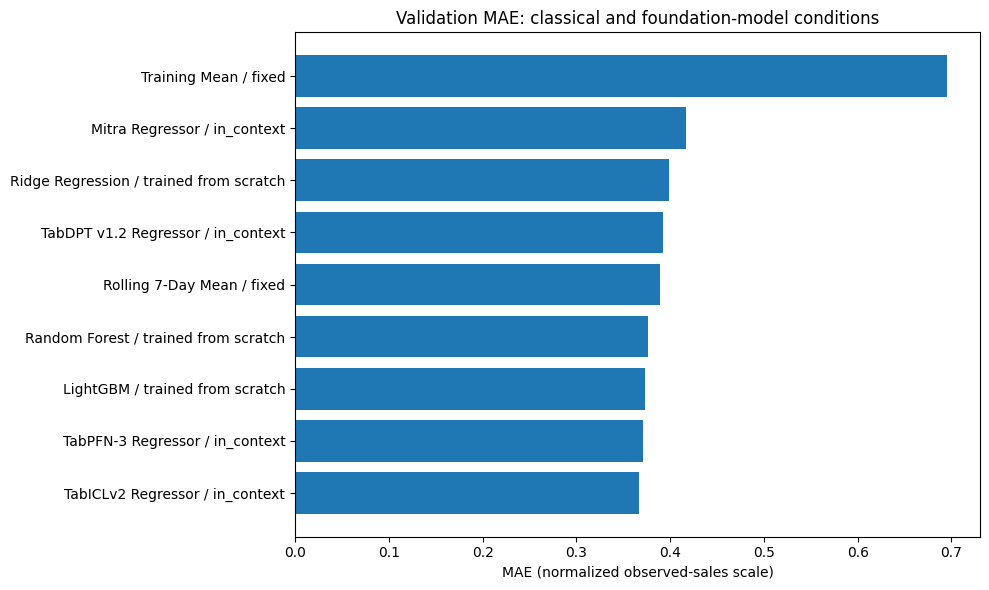

Runtime is descriptive: first-run fit timing may include checkpoint loading/download. It is not an equal-hardware speed benchmark.


In [23]:
# @title 5.6 Compare classical and foundation-model validation results
combined_validation_results=normalize_results(pd.concat([baseline_validation_results,foundation_validation_results],ignore_index=True))
combined_validation_results=combined_validation_results.sort_values(PRIMARY_METRIC,ascending=PRIMARY_METRIC!="r2")
display(combined_validation_results[["model","condition","mae","rmse","median_absolute_error","r2","runtime_seconds","device"]].round(5))
plt.figure(figsize=(10,6))
plt.barh(combined_validation_results.model+" / "+combined_validation_results.condition,combined_validation_results.mae)
plt.title("Validation MAE: classical and foundation-model conditions")
plt.xlabel("MAE (normalized observed-sales scale)");plt.tight_layout();show_and_save_plot(run_ids=combined_validation_results.run_id.dropna().tolist())
print("Runtime is descriptive: first-run fit timing may include checkpoint loading/download. It is not an equal-hardware speed benchmark.")

## Multi-model checkpoint

Use the comparison table to answer:

1. Which condition has the lowest validation MAE?
2. Does that condition also have the lowest RMSE?
3. Does a foundation model outperform LightGBM and Random Forest?
4. Did a fine-tuned condition actually update weights?
5. How much additional runtime was required for any improvement?
6. Is the improvement large enough to matter for the purpose of this training exercise?
7. Which licence restrictions must be retained in the report?

Avoid writing “Model X is the best tabular model.” The evidence supports only a statement about this dataset version, split, metric, repository revision, and run configuration.

Use the observed row-count audit in each `result.json`. An in-context model may use fewer rows per prediction than the number registered for the model; do not assume identical effective context sizes.

# 6. Optional extension: stockout-feature ablation

An **ablation experiment** removes one feature group while holding the rest of the procedure constant. It helps test whether that feature group contributes useful predictive information.

Here, remove:

- `stockout_hours`; and
- `roll_7_stockout`.

The comparison does not prove a causal effect of stockouts. It tests whether those variables improve prediction under this fixed modeling protocol.

In [24]:
# @title 6.1 Optional classical stockout-feature ablation
RUN_LOCAL_ABLATION = True # @param {type:"boolean"}
ABLATION_MODEL = "lightgbm" # @param ["ridge", "random_forest", "lightgbm"]
STOCKOUT_FEATURES=["stockout_hours","roll_7_stockout"]
ablation_results=normalize_results([])
CURRENT_ABLATION_KEYS=[];ABLATION_RECEIPTS=[]
if RUN_LOCAL_ABLATION:
    assert_current_data();SESSION.assert_development()
    if ABLATION_MODEL not in model_templates: raise ValueError("Choose a baseline that ran successfully.")
    reduced=[f for f in feature_columns if f not in STOCKOUT_FEATURES]
    model=clone(model_templates[ABLATION_MODEL]);start=time.perf_counter();model.fit(X_train[reduced],y_train)
    elapsed=time.perf_counter()-start
    key=ABLATION_MODEL+"_no_stockout";ctrl=classical_controls(key,reduced)
    identity={"experiment_id":SESSION.experiment_id,"model_key":key,"controls":ctrl,
              "split_sha256":DATASET_IDENTITY["split_sha256"],"features":reduced}
    receipt=save_classical_run(SESSION,key,model,frames["train"],frames["val"],ctrl,fit_seconds=elapsed,
                             identity=identity,model_name=names[ABLATION_MODEL]+" without stockout features")
    ABLATION_RECEIPTS.append(receipt);CURRENT_ABLATION_KEYS.append(key)
    tested,_=load_results([receipt],frames["val"])
    ablation_results=normalize_results(pd.concat([baseline_validation_results[baseline_validation_results.model_key.eq(ABLATION_MODEL)],tested]))
    display(ablation_results[["model","mae","rmse","r2"]].round(5))
else:print("Classical ablation skipped.")

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,mae,rmse,r2
4,LightGBM,0.37341,0.70548,0.73540
0,LightGBM without stockout features,0.38824,0.74398,0.70573


### Foundation-model stockout ablation

The next cell repeats one selected foundation-model condition after removing:

```text
stockout_hours
roll_7_stockout
```

Every other model setting remains unchanged. The environment and weights are reused, but the model is conditioned or fitted again on the reduced feature table.

This is a predictive ablation. It tests whether those columns improve this model's validation performance under the fixed protocol. It does not establish that stockouts causally change demand.

In [25]:
# @title 6.2 Optional foundation-model stockout-feature ablation
RUN_FOUNDATION_ABLATION = True # @param {type:"boolean"}
FOUNDATION_ABLATION_CONDITION = "" # @param {type:"string"}
# @markdown Blank uses the first successful foundation-model condition.
foundation_ablation_results=normalize_results([])
# Re-running this cell replaces this session's active FM-ablation selection only.
CURRENT_ABLATION_KEYS=[k for k in CURRENT_ABLATION_KEYS if not k.startswith("fm_ablation_")]
if RUN_FOUNDATION_ABLATION:
    assert_current_data();SESSION.assert_development()
    candidate=choose_diagnostic_model(prediction_registry,FOUNDATION_ABLATION_CONDITION)
    if candidate is None:print("Run a foundation model first; no foundation ablation executed.")
    else:
        reduced=[f for f in feature_columns if f not in STOCKOUT_FEATURES]
        key="fm_ablation_"+candidate
        ctrl=foundation_controls(candidate,reduced)
        receipt=ENGINE.run_validation(key,ctrl,CONDITION_SPECS[candidate],force=FORCE_MODEL_RERUN)
        ABLATION_RECEIPTS.append(receipt);CURRENT_ABLATION_KEYS.append(key)
        tested,_=load_results([receipt],frames["val"])
        foundation_ablation_results=normalize_results(pd.concat([
            foundation_validation_results[foundation_validation_results.model_key.eq(candidate)],tested]))
        display(foundation_ablation_results[["model_key","mae","rmse","r2"]].round(5))
else:print("Foundation-model ablation skipped.")

$ /content/dimer_tabular_workshop_v2/environments/mitra-ee08973289cf/bin/python /content/dimer_tabular_workshop_v2/support/e63f8ff03a76b973c598f8db85e602af6d20d394b63ae04dac82b7b4aa34cabd/local_foundation_regressor.py --config /content/dimer_tabular_workshop_v2/experiments/experiment-895eb9232bd7/runs/fm_ablation_mitra_icl-2ca1de6d3fef/run_config.json
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.3
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB
Total GPU Memory:   Free: 14.56 GB, Allocated: 0.00 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       10.43 GB / 12.67 GB (82.3%)
Disk Space Avail:   152.86 GB / 235.68 GB (64.9%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to us

,model_key,mae,rmse,r2
0,mitra_icl,0.41717,0.74397,0.70575
0,fm_ablation_mitra_icl,0.42026,0.76307,0.69044


# 7. Optional prediction-level error analysis

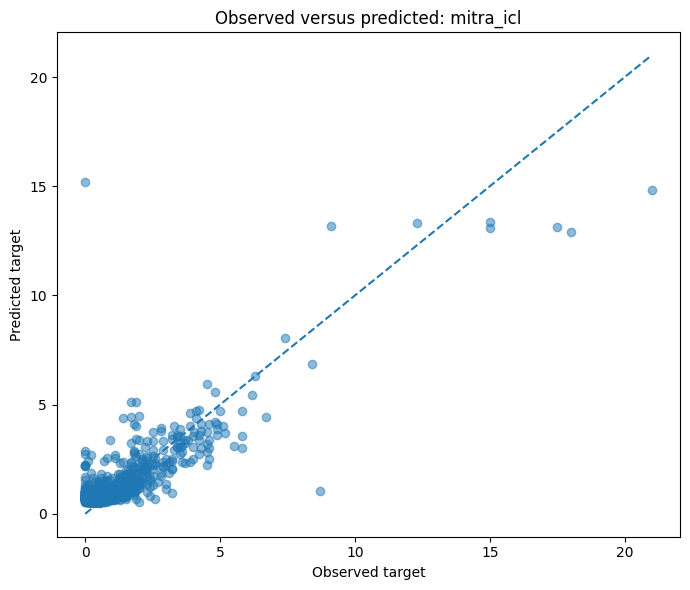

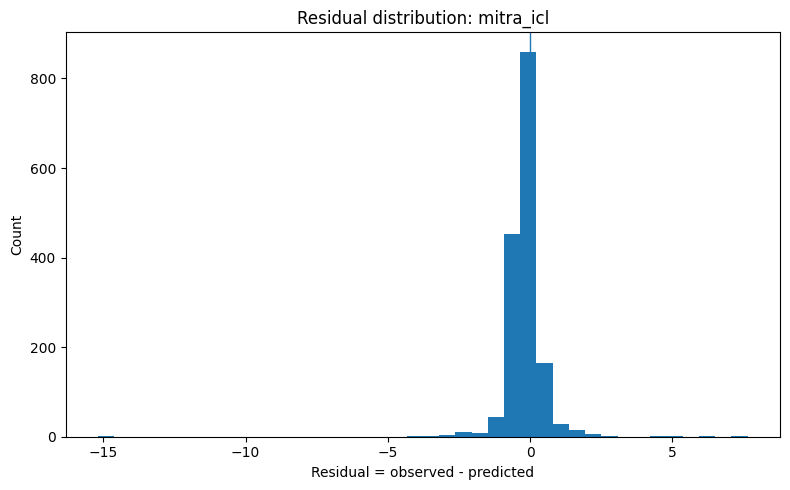

,target_band,absolute_error
0,"(-0.001, 0.3]",0.632039
1,"(0.3, 0.5]",0.307716
2,"(0.5, 0.7]",0.184699
3,"(0.7, 1.2]",0.183087
4,"(1.2, 21.0]",0.731961


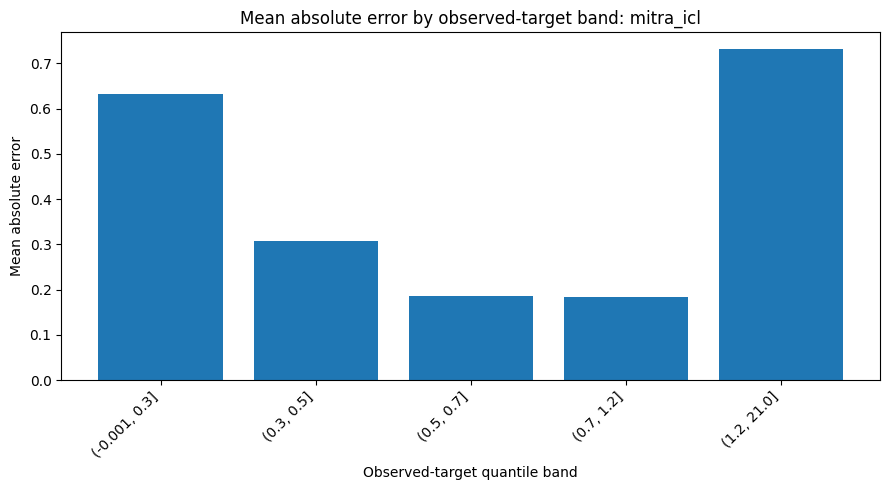

,stockout_band,absolute_error
0,"(-0.001, 5.0]",0.415069
1,"(5.0, 16.0]",0.424741


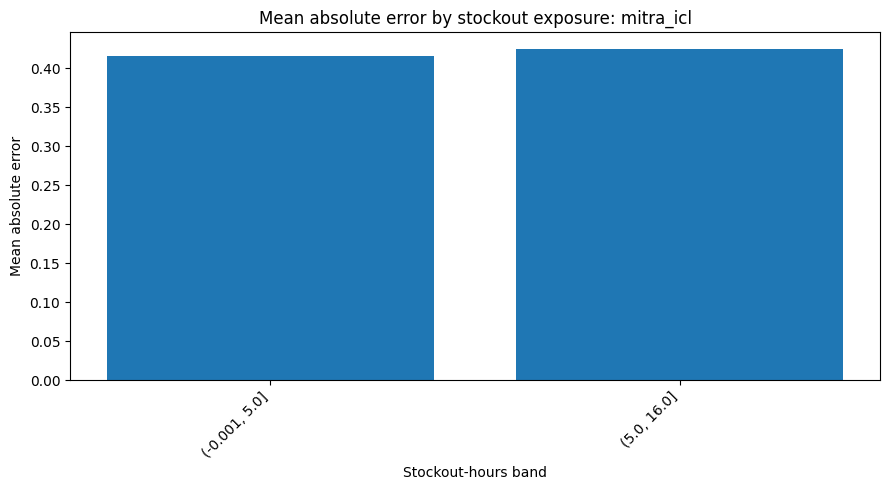

In [26]:
# @title 7.1 Inspect a locally executed foundation model's errors

PREDICTION_MODEL_KEY = "" # @param {type:"string"}
TARGET_QUANTILE_BINS = 5 # @param {type:"slider", min:3, max:10, step:1}

PREDICTION_MODEL_KEY=choose_diagnostic_model(prediction_registry,PREDICTION_MODEL_KEY)
if PREDICTION_MODEL_KEY is None:
    print("No foundation model ran. Use the baseline diagnostics in 4.4, or run a foundation model in 5.4.")
else:
    diagnostics = prediction_registry[
        PREDICTION_MODEL_KEY
    ].copy()

    diagnostics["residual"] = (
        diagnostics["target"]
        - diagnostics["prediction"]
    )
    diagnostics["absolute_error"] = diagnostics[
        "residual"
    ].abs()

    lower = float(
        min(
            diagnostics["target"].min(),
            diagnostics["prediction"].min(),
        )
    )
    upper = float(
        max(
            diagnostics["target"].max(),
            diagnostics["prediction"].max(),
        )
    )

    plt.figure(figsize=(7, 6))
    plt.scatter(
        diagnostics["target"],
        diagnostics["prediction"],
        alpha=0.5,
    )
    plt.plot([lower, upper], [lower, upper], linestyle="--")
    plt.title(
        f"Observed versus predicted: "
        f"{PREDICTION_MODEL_KEY}"
    )
    plt.xlabel("Observed target")
    plt.ylabel("Predicted target")
    plt.tight_layout()
    show_and_save_plot(run_ids=[SESSION.current_record(PREDICTION_MODEL_KEY)[1]["run_id"]])

    plt.figure(figsize=(8, 5))
    plt.hist(diagnostics["residual"], bins=40)
    plt.axvline(0, linewidth=1)
    plt.title(
        f"Residual distribution: "
        f"{PREDICTION_MODEL_KEY}"
    )
    plt.xlabel("Residual = observed - predicted")
    plt.ylabel("Count")
    plt.tight_layout()
    show_and_save_plot(run_ids=[SESSION.current_record(PREDICTION_MODEL_KEY)[1]["run_id"]])

    diagnostics["target_band"] = pd.qcut(
        diagnostics["target"],
        q=TARGET_QUANTILE_BINS,
        duplicates="drop",
    )

    target_band_error = (
        diagnostics
        .groupby("target_band", observed=True)["absolute_error"]
        .mean()
        .reset_index()
    )

    display(target_band_error)

    plt.figure(figsize=(9, 5))
    plt.bar(
        target_band_error["target_band"].astype(str),
        target_band_error["absolute_error"],
    )
    plt.title(
        f"Mean absolute error by observed-target band: "
        f"{PREDICTION_MODEL_KEY}"
    )
    plt.xlabel("Observed-target quantile band")
    plt.ylabel("Mean absolute error")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    show_and_save_plot(run_ids=[SESSION.current_record(PREDICTION_MODEL_KEY)[1]["run_id"]])

    if "stockout_hours" in diagnostics.columns:
        diagnostics["stockout_band"] = pd.qcut(
            diagnostics["stockout_hours"],
            q=4,
            duplicates="drop",
        )

        stockout_error = (
            diagnostics
            .groupby("stockout_band", observed=True)["absolute_error"]
            .mean()
            .reset_index()
        )

        display(stockout_error)

        plt.figure(figsize=(9, 5))
        plt.bar(
            stockout_error["stockout_band"].astype(str),
            stockout_error["absolute_error"],
        )
        plt.title(
            f"Mean absolute error by stockout exposure: "
            f"{PREDICTION_MODEL_KEY}"
        )
        plt.xlabel("Stockout-hours band")
        plt.ylabel("Mean absolute error")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        show_and_save_plot(run_ids=[SESSION.current_record(PREDICTION_MODEL_KEY)[1]["run_id"]])
    else:
        print(
            "Stockout-stratified analysis is unavailable because "
            "the prediction export was not aligned to validation features."
        )

# 8. Freeze the experiment and evaluate the test set

## Freeze the experiment before seeing test results
Use validation results to choose the model conditions you will evaluate. Freezing records the exact successful local run IDs, CSV hashes, feature sets, parameters, code/environment identities, and saved model artifact hashes.

**After freezing, you cannot fit again or change settings in this experiment.** Start a new experiment in Section 0.3 to explore different choices; earlier results remain on disk. Final testing loads the saved models. It does not repeat training or fine-tuning.

The freeze is an experiment-control mechanism, not an access-control system: you already possess the ZIP, including test labels. Do not inspect those labels during model development. An EDA run that exposed test targets must be described as exploratory, not an untouched-test experiment.

Leave **Freeze now** off while exploring. When ready, select successful local model keys below and turn it on. Blank selection freezes all current successful full-feature runs; ablations must be selected explicitly by their displayed key.

In [27]:
# @title 8.0 Freeze selected successful local runs
FREEZE_NOW = True # @param {type:"boolean"}
SELECTED_MODEL_KEYS = "" # @param {type:"string"}
# @markdown Comma-separated successful local keys, or blank for current full-feature runs.

def desired_controls_for(key):
    if key.startswith("fm_ablation_"):
        return foundation_controls(key[len("fm_ablation_"):],[f for f in feature_columns if f not in STOCKOUT_FEATURES])
    if key in CONDITION_SPECS:return foundation_controls(key)
    return classical_controls(key,[f for f in feature_columns if f not in STOCKOUT_FEATURES] if key.endswith("_no_stockout") else None)

def current_controls_for(keys):
    assert_current_data()
    return {key:desired_controls_for(key) for key in keys}

eligible_keys=list(CURRENT_CLASSICAL_KEYS)+list(CURRENT_FOUNDATION_KEYS)+list(CURRENT_ABLATION_KEYS)
print("Successful/current candidate keys:",eligible_keys)
selected_keys=[k.strip() for k in SELECTED_MODEL_KEYS.split(",") if k.strip()] or list(CURRENT_CLASSICAL_KEYS)+list(CURRENT_FOUNDATION_KEYS)
if FREEZE_NOW:
    if any(k not in eligible_keys for k in selected_keys):raise ValueError("Select only current successful model keys.")
    if INCLUDE_TEST_TARGETS_IN_EDA or TEST_TARGETS_VIEWED:
        raise ValueError("Test targets were enabled in EDA. Keep this as an exploratory exercise; start a fresh untouched-test study for final claims.")
    FROZEN_MANIFEST=SESSION.freeze(selected_keys,current_controls_for(selected_keys))
    print("Frozen manifest:",FROZEN_MANIFEST)
    print("Frozen models:",selected_keys)
else:print("Not frozen yet. Finish development before enabling Freeze now.")

Successful/current candidate keys: ['training_mean', 'rolling_7_mean', 'ridge', 'random_forest', 'lightgbm', 'mitra_icl', 'tabdpt_icl', 'tabpfn3_icl', 'tabiclv2_icl', 'lightgbm_no_stockout', 'fm_ablation_mitra_icl']
Frozen manifest: /content/dimer_tabular_workshop_v2/experiments/experiment-895eb9232bd7/freeze.json
Frozen models: ['training_mean', 'rolling_7_mean', 'ridge', 'random_forest', 'lightgbm', 'mitra_icl', 'tabdpt_icl', 'tabpfn3_icl', 'tabiclv2_icl']


In [28]:
# @title 8.1 Evaluate only the frozen models on the test partition
EVALUATE_FROZEN_TEST = True # @param {type:"boolean"}
# @markdown Requires Section 8.0. Cached test results are reused only for this same freeze.
FINAL_RECEIPTS=[]
if EVALUATE_FROZEN_TEST:
    assert_current_data()
    if not (SESSION.root / "freeze.json").exists():raise ValueError("Freeze successful runs in 8.0 first.")
    frozen=json.loads((SESSION.root / "freeze.json").read_text())
    frozen_keys=list(frozen["selected"])
    if SELECTED_MODEL_KEYS.strip() and set(k.strip() for k in SELECTED_MODEL_KEYS.split(",") if k.strip())!=set(frozen_keys):
        raise ValueError("Selection changed after freeze. No test evaluation started.")
    controls=current_controls_for(frozen_keys)
    SESSION.validate_freeze(controls)
    for key in frozen_keys:
        if controls[key]["backend"]=="classical":
            FINAL_RECEIPTS.append(evaluate_classical_frozen(SESSION,key,controls,frames["val"],frames["test"]))
        else:FINAL_RECEIPTS.append(ENGINE.run_test(key,controls))
    TEST_EVALUATION_COMPLETED=True
    final_test_results,foundation_test_predictions=load_results(FINAL_RECEIPTS,frames["test"],partition="test")
else:
    final_test_results=normalize_results([])
    TEST_EVALUATION_COMPLETED=False
    print("Test evaluation is off. Models will not be refitted when it is enabled.")

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


$ /content/dimer_tabular_workshop_v2/environments/mitra-ee08973289cf/bin/python /content/dimer_tabular_workshop_v2/support/e63f8ff03a76b973c598f8db85e602af6d20d394b63ae04dac82b7b4aa34cabd/local_foundation_regressor.py --config /content/dimer_tabular_workshop_v2/experiments/experiment-895eb9232bd7/tests/mitra_icl-ae0c271f131a/run_config.json
{
  "model": "Mitra Regressor",
  "mode": "in_context",
  "phase": "test",
  "metrics": {
    "validation": null,
    "test": {
      "mae": 0.440251171875,
      "rmse": 0.8498260229524096,
      "median_absolute_error": 0.275,
      "r2": 0.7728940997266225
    }
  }
}
$ /content/dimer_tabular_workshop_v2/environments/tabdpt-ed61878a98e1/bin/python /content/dimer_tabular_workshop_v2/support/e63f8ff03a76b973c598f8db85e602af6d20d394b63ae04dac82b7b4aa34cabd/local_foundation_regressor.py --config /content/dimer_tabular_workshop_v2/experiments/experiment-895eb9232bd7/tests/tabdpt_icl-65d017207472/run_config.json
{
  "model": "TabDPT v1.2 Regressor",
  

,model,condition,mae,rmse,median_absolute_error,r2,device,run_id
7,TabPFN-3 Regressor,in_context,0.42416,0.73544,0.26128,0.82991,cuda,tabpfn3_icl-190e161a8c55
6,TabICLv2 Regressor,in_context,0.43286,0.79355,0.26460,0.80198,cuda,tabiclv2_icl-7f6dd1c3c6e7
2,Random Forest,trained from scratch,0.43706,0.84950,0.26023,0.77307,cpu,random_forest-d8b4d0be95bd
4,Rolling 7-Day Mean,fixed,0.43777,0.76483,0.25714,0.81605,cpu,rolling_7_mean-7c8fed5b2dca
3,Ridge Regression,trained from scratch,0.43797,0.72447,0.27757,0.83495,cpu,ridge-1957421ff813
1,Mitra Regressor,in_context,0.44025,0.84983,0.27500,0.77289,cuda,mitra_icl-ae0c271f131a
0,LightGBM,trained from scratch,0.46011,0.90936,0.27232,0.73996,cpu,lightgbm-1788c04b8f22
5,TabDPT v1.2 Regressor,in_context,0.52836,1.17720,0.32724,0.56422,cuda,tabdpt_icl-65d017207472
8,Training Mean,fixed,0.74660,1.78943,0.46039,-0.00693,cpu,training_mean-bbed0ed9ce55


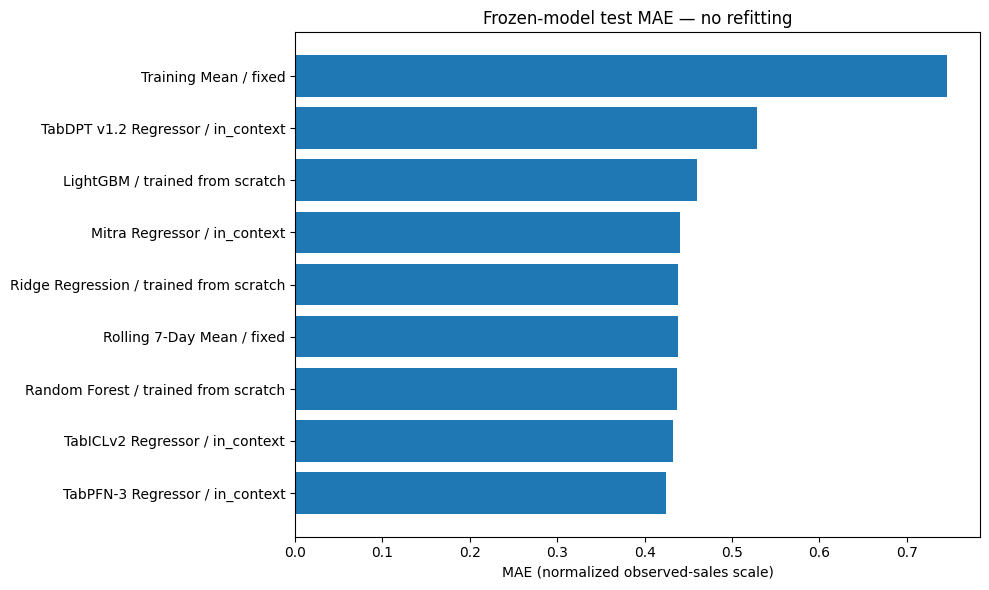

In [29]:
# @title 8.2 Display frozen-test results (baseline-only and partial-model selections supported)
final_test_results=normalize_results(final_test_results)
if final_test_results.empty:print("No final-test results to display. Complete the freeze and evaluation steps first.")
else:
    final_test_results=final_test_results.sort_values(PRIMARY_METRIC,ascending=PRIMARY_METRIC!="r2")
    display(final_test_results[["model","condition","mae","rmse","median_absolute_error","r2","device","run_id"]].round(5))
    plt.figure(figsize=(10,6))
    plt.barh(final_test_results.model+" / "+final_test_results.condition,final_test_results.mae)
    plt.title("Frozen-model test MAE — no refitting")
    plt.xlabel("MAE (normalized observed-sales scale)");plt.tight_layout();show_and_save_plot(run_ids=final_test_results.run_id.dropna().tolist())

## 8.3 Inspect independent query-time predictions

The frozen-test stage reloads saved artifacts and scores feature rows that were not used for model adaptation. The target is used only after prediction to compute evaluation metrics. This cell exposes prediction-only output separately from the metric table.


In [30]:
# @title 8.3 Preview prediction-only output from a frozen model
INFERENCE_PREVIEW_ROWS = 8 # @param {type:"slider", min:1, max:50, step:1}
INFERENCE_MODEL_KEY = "" # @param {type:"string"}
if final_test_results.empty or not foundation_test_predictions:
    raise RuntimeError("Complete the default freeze and independent test evaluation first.")
validation_order=combined_validation_results.sort_values(PRIMARY_METRIC,ascending=PRIMARY_METRIC!="r2").model_key.tolist()
default_key=next((key for key in validation_order if key in foundation_test_predictions),None)
model_key=INFERENCE_MODEL_KEY.strip() or default_key
if model_key not in foundation_test_predictions:
    raise ValueError(f"Choose a frozen model key with predictions: {sorted(foundation_test_predictions)}")
inference_preview=foundation_test_predictions[model_key][["row_id","prediction"]].head(INFERENCE_PREVIEW_ROWS).copy()
display(inference_preview)
print("Inference model:",model_key)
print("Output semantics: one point prediction per input row; uncertainty intervals are not produced by this workshop.")


,row_id,prediction
0,0,0.847822
1,1,0.591951
2,2,0.527836
3,3,0.775212
4,4,0.661148
5,5,0.462440
6,6,0.917459
7,7,0.484588


Inference model: tabiclv2_icl
Output semantics: one point prediction per input row; uncertainty intervals are not produced by this workshop.


# 9. Interpret the evidence

## Write an evidence-based conclusion

Use this structure:

### 1. State the question

> We tested whether the selected tabular foundation models running locally improved seven-day-ahead observed-sales prediction relative to naive and classical machine-learning baselines.

### 2. Report the primary result

> On the fixed test partition, **[model and condition]** obtained an MAE of **[value]**, compared with **[value]** for **[reference baseline]**.

### 3. Report supporting metrics

> Its RMSE was **[value]**, median absolute error was **[value]**, and \(R^2\) was **[value]**.

### 4. Describe adaptation honestly

> The run used **[in-context learning / effective fine-tuning]**, as confirmed by **[run metadata]**.

### 5. Interpret stockout findings

> Removing stockout features **[increased / decreased / did not materially change]** validation MAE by **[value]**.

### 6. State limitations

At minimum, discuss:

- the sample includes only 220 store–product series;
- it is derived from one fresh-retail source;
- it covers a short time window;
- the target is normalized observed sales;
- stockouts may censor latent demand;
- the sample is intended for testing and demonstration;
- the model comparison depends on the selected metric and run configuration; and
- foundation-model pretraining overlap may affect benchmark interpretation.

### 7. Avoid overclaiming

Prefer:

> “Under this dataset version and evaluation protocol, Model A produced lower MAE than Model B.”

Avoid:

> “Model A is the best tabular model.”

Also avoid calling the target “true demand.” It is observed future `sale_amount`, which may be constrained by product availability.

## Participant submission checklist

Submit the following:

- [ ] Dataset repository revision and SHA-256 digest
- [ ] Software versions
- [ ] One target-distribution visualization
- [ ] One feature-shift visualization
- [ ] One feature–target visualization
- [ ] Classical baseline results
- [ ] At least two foundation-model conditions
- [ ] Effective adaptation mode for each local run
- [ ] Validation comparison table
- [ ] Final test comparison table
- [ ] Stockout ablation result or a justified reason for omitting it
- [ ] One evidence-based conclusion
- [ ] At least three limitations
- [ ] Model and dataset licence notes

### Suggested scoring guide

| Criterion | Weight |
|---|---:|
| Reproducible setup and provenance | 15% |
| Correct use of train, validation, and test partitions | 20% |
| EDA quality and interpretation | 20% |
| Controlled model comparison | 20% |
| Error and stockout analysis | 10% |
| Evidence-based conclusion and limitations | 15% |


# 10. Export the experiment record

In [31]:
# @title 10.1 Export only current registered results and generated figures
CREATE_ZIP_BUNDLE = True # @param {type:"boolean"}
DOWNLOAD_ZIP_BUNDLE = False # @param {type:"boolean"}
INCLUDE_FROZEN_TEST_RESULTS = True # @param {type:"boolean"}
assert_current_data()
current_keys=list(CURRENT_CLASSICAL_KEYS)+list(CURRENT_FOUNDATION_KEYS)+list(CURRENT_ABLATION_KEYS)
if INCLUDE_FROZEN_TEST_RESULTS:
    if not TEST_EVALUATION_COMPLETED:raise ValueError("Complete frozen-test evaluation first, or leave test export off.")
    frozen=json.loads((SESSION.root / "freeze.json").read_text())
    export_keys=list(frozen["selected"])
else:export_keys=current_keys
controls=current_controls_for(export_keys)
receipts=SESSION.export_records(export_keys,controls,include_test=INCLUDE_FROZEN_TEST_RESULTS)
export_directory=new_owned_directory(SESSION.root / "exports","report")
export_run_files(receipts,export_directory)
# Recompute tables from the accepted receipt list; never export stale in-memory model tables.
development=[p for p in receipts if validate_receipt(p)["stage"]=="development"]
accepted_validation,_=load_results(development,frames["val"])
accepted_validation.to_csv(export_directory / "validation_results.csv",index=False)
if INCLUDE_FROZEN_TEST_RESULTS:
    test_receipts=[p for p in receipts if validate_receipt(p)["stage"]=="test"]
    accepted_test,_=load_results(test_receipts,frames["test"],partition="test")
    accepted_test.to_csv(export_directory / "test_results.csv",index=False)
    shutil.copy2(SESSION.root / "freeze.json",export_directory / "freeze.json")
for name,table in (("dataset_quality",quality_report),("target_summary",target_summary if INCLUDE_FROZEN_TEST_RESULTS else target_summary.drop(index="test",errors="ignore")),("feature_shift",shift_report),
                   ("feature_target_correlations",correlation_report)):
    # Test-target EDA is disallowed for the confirmatory path; summary excludes test by default.
    table.to_csv(export_directory / (name+".csv"))
figures=[]
accepted_run_ids={validate_receipt(p)["run_id"] for p in receipts}
for key,entry in FIGURE_REGISTRY.items():
    if not set(entry.get("run_ids",[])).issubset(accepted_run_ids):
        print("Omitting a chart produced by an unselected or superseded run:",entry["title"])
        continue
    # Only current experiment figures; omit test plots unless explicitly included.
    if not INCLUDE_FROZEN_TEST_RESULTS and "test" in entry["title"].lower() and "validation" not in entry["title"].lower():continue
    path=Path(entry["path"])
    if SESSION.root not in path.resolve().parents or sha256_file(path)!=entry["sha256"]:
        raise ValueError("Figure is stale, changed, or belongs to another experiment.")
    destination=export_directory / "figures" / path.name
    destination.parent.mkdir(exist_ok=True);shutil.copy2(path,destination)
    figures.append({"file":str(destination.relative_to(export_directory)),"title":entry["title"],"sha256":entry["sha256"]})
manifest={"notebook_revision":"3.0.1","experiment_id":SESSION.experiment_id,
          "base_identity":SESSION.base_identity,"dataset_provenance":DATASET_PROVENANCE,
          "current_run_ids":[validate_receipt(p)["run_id"] for p in receipts],
          "selected_model_keys":export_keys,"includes_test_results":INCLUDE_FROZEN_TEST_RESULTS,
          "freeze_sha256":SESSION.state().get("freeze_sha256") if INCLUDE_FROZEN_TEST_RESULTS else None,
          "figures":figures,"software_versions":SOFTWARE_VERSIONS,
          "artifact_policy":"Fitted models remain local; receipt inventories record their hashes.",
          "notebook_spec":"2.1","carried_adapter_sha256":CARRIED_SOURCE_SHA256}
if "inference_preview" in globals():
    inference_preview.to_csv(export_directory / "inference_preview.csv",index=False)
write_json(export_directory / "experiment_manifest.json",manifest)
print("Exported current experiment to:",export_directory)
if CREATE_ZIP_BUNDLE:
    bundle_path=Path(shutil.make_archive(str(export_directory),"zip",root_dir=export_directory))
    print("Report ZIP:",bundle_path,"SHA-256:",sha256_file(bundle_path))
    if DOWNLOAD_ZIP_BUNDLE:
        try:
            from google.colab import files
            files.download(str(bundle_path))
        except (ImportError, Exception) as err:
            print(f"Colab file download unavailable: {err}")

Exported current experiment to: /content/dimer_tabular_workshop_v2/experiments/experiment-895eb9232bd7/exports/report-67a9da25eb94
Report ZIP: /content/dimer_tabular_workshop_v2/experiments/experiment-895eb9232bd7/exports/report-67a9da25eb94.zip SHA-256: 7ed1ecb062fd74bbcbb8743e5efbbdb9d2da901f158fb37c37c2f7c7211416c6


In [32]:
# @title Run-all completion summary
summary={"notebook_spec":"2.1","profile":"E2E","mode":"WORKSHOP","dataset_source":DATASET_PROVENANCE["acquisition_method"],
         "validation_models":int(len(combined_validation_results)),"frozen_test_models":int(len(final_test_results)),
         "foundation_failures":FOUNDATION_RUN_ERRORS,"export_directory":str(export_directory)}
display(pd.Series(summary,name="value").to_frame())
if FREEZE_NOW and EVALUATE_FROZEN_TEST and INCLUDE_FROZEN_TEST_RESULTS and not final_test_results.empty:
    print("Run-all complete: validation, freeze, artifact reload, independent test evaluation, inference preview, and export succeeded.")
else:
    print("Run completed with one or more default E2E stages disabled; treat this as an exploratory run.")


,value
notebook_spec,2.1
profile,E2E
mode,WORKSHOP
dataset_source,pinned-public-sample
validation_models,9
frozen_test_models,9
foundation_failures,{}
export_directory,/content/dimer_tabular_workshop_v2/experiments...


Run-all complete: validation, freeze, artifact reload, independent test evaluation, inference preview, and export succeeded.


# Appendix A. Instructor and reproducibility notes

By default, the workshop uses the pinned repository-hosted `freshretailnet-h7.zip` sample derived from FreshRetailNet-50K; an optional same-schema pre-split BYOD ZIP may be selected explicitly. No DIMER model job is submitted. Model execution is local through notebook-carried public adapters and immutable upstream checkpoints.

**Exercise sequence:** acquire pinned sample → verify hash/schema → EDA → validation comparisons → optional ablation → freeze selected local runs → load those same models for final testing → export registered results and saved figures.

The model adapters are carried inside the notebook from the reviewed repository commits, while each isolated model environment installs the exact upstream dependency pins. Immutable checkpoint files are downloaded from their public upstream hosts and verified against the carried manifests. Environment or model-run failures are surfaced explicitly; the default path does not silently degrade into a partial multi-model comparison.

The notebook-owned Mitra chronological-validation adapter remains explicit in the result metadata, including the observed AutoGluon training/validation counts.

Cached results have a fingerprint covering the actual split bytes, feature schema, model/checkpoint/code identity, seed, parameters, and environment signature. The final-test cell checks the frozen selection and artifact inventory before loading models. There is no fallback that retrains a missing or invalid frozen model.

Report bundles contain only explicitly accepted current records. Trained weight files remain in the local session directory; they are not automatically redistributed with the report. Output directories are newly created; participant files are never recursively removed.

**Acceptance boundary:** the sample itself is a tutorial/sanity fixture, so its metrics are not benchmark evidence. Before teaching, run the chosen core models in a clean Colab session with the pinned sample and real model checkpoints; exercise optional GPU fine-tuning separately and verify the first saved-artifact reload.


# Appendix B. Dataset and model references

## Dataset

Workshop sample artifact: `kurtvalcorza/mitra-regressor-pipeline/examples/sample-data/freshretailnet-h7.zip`  
Pinned repository revision: `78e12407044bbca6ed8edbb9754bb33bf09117ac`  
Pinned archive SHA-256: `6534230e9eb6a2e212b741c4c17d897a57338323eb011f35ba2dc3fb28d8bb7b`

The sample is derived from:

Wang, Y., Gu, J., Long, L., Li, X., Shen, L., Fu, Z., Zhou, X., & Xu, J. (2025). *FreshRetailNet-50K: A Stockout-Annotated Censored Demand Dataset for Latent Demand Recovery and Forecasting in Fresh Retail*. arXiv:2505.16319.

Source dataset: `Dingdong-Inc/FreshRetailNet-50K`  
Pinned source revision used by the dataset builder: `08c1fab7f9257bc73679d415d65d644165d351d4`  
Dataset licence: CC BY 4.0

## Pinned pipeline repositories

| Model | Repository | Commit |
|---|---|---|
| Mitra Regressor | `kurtvalcorza/mitra-regressor-pipeline` | `a2b36c21fe92d9e42e2f3310c98e9e1c7fe8d7af` |
| TabDPT v1.2 Regressor | `kurtvalcorza/tabdpt-regressor-pipeline` | `21085dd2e148041d8fa88944c21532b4bdf9a7ea` |
| TabPFN-3 Regressor | `kurtvalcorza/tabpfn-regressor-pipeline` | `45dddb070326b9994a18e689add0546d30684239` |
| TabICLv2 Regressor | `kurtvalcorza/tabicl-regressor-pipeline` | `08146a323d516fb8dc9aac7f51ad17994e37294c` |

The notebook executes these pipeline repositories locally. It does not submit model jobs to DIMER.

## Adapter contract used for this revision
- AutoGluon 1.5 `TabularPredictor.fit`: https://auto.gluon.ai/1.5/api/autogluon.tabular.TabularPredictor.fit.html
- AutoGluon 1.5 trained-predictor loading: https://auto.gluon.ai/1.5/tutorials/tabular/tabular-essentials.html

These sources support the explicit `tuning_data` policy and saved-predictor loading. The workflow does not interpret a successful import as model-quality evidence.
